In [49]:
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import seaborn as sns
import os
import glob
from datetime import datetime
from datetime import timedelta
from matplotlib import pyplot as plt
import matplotlib.dates as md
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
from matplotlib import cm
import matplotlib.dates as mdates
from scipy.interpolate import interp2d
warnings.filterwarnings('ignore')
#import datetime
import scipy.ndimage as ndimage
from matplotlib import cm
import geopy.distance
#import matplotlib as mpl
from scipy.interpolate import interp1d
from sklearn.linear_model import LinearRegression
from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame
import leafmap
import plotly.express as px
import matplotlib as mpl
import xarray as xr
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
import math
#import pysplit
import netCDF4
import xarray as xr
import re

In [50]:
def detect_delimiter(header_line):
    """
    Try to guess the delimiter used in the header line.
    Prioritize tab > comma > multiple spaces.
    """
    if "\t" in header_line:
        return "\t"
    elif "," in header_line:
        return ","
    elif "  " in header_line:
        return r"\s+"
    else:
        return None

def simple_read(path):
    try:
        header_line_idx = None
        with open(path, 'r') as f:
            lines = f.readlines()

        # Step 1: Locate R0 header line
        for i, line in enumerate(lines):
            if line.startswith("R0: File generated from data submitted"):
                header_line_idx = i + 1  # Header is next line
                break

        if header_line_idx is None:
            raise ValueError("❌ Could not find R0 header marker in file.")

        # Step 2: Auto-detect delimiter from header line
        raw_header = lines[header_line_idx].strip()
        delimiter = detect_delimiter(raw_header)
        if delimiter is None:
            raise ValueError("❌ Unable to detect delimiter.")

        # Step 3: Read data using detected delimiter
        data = pd.read_csv(
            path,
            skiprows=header_line_idx,
            sep=delimiter,
            engine="python",
            on_bad_lines="skip"
        )
        data.columns = [col.strip() for col in data.columns]

# Debug print to confirm columns
        print(f"\n📑 Parsed columns from {os.path.basename(path)}:")
        print(data.columns.tolist())


        # Step 4: Extract base date from filename
        match = re.search(r'(\d{4})(\d{2})(\d{2})', path)
        if not match:
            raise ValueError("❌ Date not found in path.")
        year, month, day = map(int, match.groups())
        base_date = datetime(year, month, day)

        # Step 5: Parse time columns (e.g., "Time_Start")
        for col in data.columns:
            if "Time" in col:
                data[col] = pd.to_numeric(data[col], errors="coerce")
                data[col] = pd.to_timedelta(data[col], unit="s") + base_date

        # Step 6: Replace bad codes with NA
        data = data.replace([-999999, -66666, -888888], pd.NA)

        return data

    except Exception as e:
        print(f"⚠️ Error reading {path}:\n{e}")
        return None

def process_multiple_files(file_paths):
    all_data = []
    for path in file_paths:
        df = simple_read(path)
        if df is not None:
            all_data.append(df)
    return pd.concat(all_data, ignore_index=True)


In [51]:
# Define the 2020 root folder
file_dir = r'C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/2020'

# Only get .ict files directly in that folder (not recursive)
file_paths = glob.glob(os.path.join(file_dir, '*.ict'))

# Remove duplicates (if any)
file_paths = list(set(file_paths))

ACTIVATE = process_multiple_files(file_paths)

ACTIVATE



📑 Parsed columns from ACTIVATE-mrg60-HU25_merge_20210605_R0.ict:
['Time_Start', 'Time_Stop', 'Latitude_THORNHILL', 'Longitude_THORNHILL', 'GPS_Altitude_THORNHILL', 'Pressure_Altitude_THORNHILL', 'Pitch_THORNHILL', 'Roll_THORNHILL', 'True_Heading_THORNHILL', 'True_Air_Speed_THORNHILL', 'Static_Air_Temp_THORNHILL', 'IR_Surf_Temp_THORNHILL', 'Static_Pressure_THORNHILL', 'WSPD_ms-1_THORNHILL', 'WDIR_deg_THORNHILL', 'U_ms-1_THORNHILL', 'V_ms-1_THORNHILL', 'w_ms-1_THORNHILL', 'H2O_DLH_DISKIN', 'RHi_DLH_DISKIN', 'RHw_DLH_DISKIN', 'Date_CORRAL', 'LegIndex_CORRAL', 'O3_ppbv_DISKIN', 'CO_ppm_DISKIN', 'CH4_ppm_DISKIN', 'CO2_ppm_DISKIN', 'InletFlag_LARGE_ZIEMBA', 'CNgt3nm_ZIEMBA', 'CNgt10nm_ZIEMBA', 'CNgt10nm_nonvol_ZIEMBA', 'IntegN_100to1000nm_LAS_ZIEMBA', 'IntegS_100to1000nm_LAS_ZIEMBA', 'IntegV_100to1000nm_LAS_ZIEMBA', 'IntegN_gt1000nm_LAS_ZIEMBA', 'IntegS_gt1000nm_LAS_ZIEMBA', 'IntegV_gt1000nm_LAS_ZIEMBA', 'nLAS_AmmSO4_ZIEMBA', 'sLAS_AmmSO4_ZIEMBA', 'vLAS_AmmSO4_ZIEMBA', 'nSMPS_ZIEMBA', 'sSMP

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,Pressure_Altitude_THORNHILL,Pitch_THORNHILL,Roll_THORNHILL,True_Heading_THORNHILL,True_Air_Speed_THORNHILL,...,Sc450_total_ZIEMBA,Sc550_total_ZIEMBA,Sc700_total_ZIEMBA,RH_Sc_total_ZIEMBA,Ext532_total_amb_ZIEMBA,Ext532_total_ZIEMBA,N_MOORE_CAS,LWC_MOORE_CAS,Reff_MOORE_CAS,Veff_MOORE_CAS
0,2021-06-05 14:06:30,2021-06-05 14:07:30,37.0729,-76.390244,115.9112,213.1955,11.8111,-2.55342,246.9163,95.9957,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-06-05 14:07:30,2021-06-05 14:08:30,37.049533,-76.456956,544.5883,1520.03,10.3058,-2.10833,246.5307,119.8143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-06-05 14:08:30,2021-06-05 14:09:30,37.02321,-76.532386,1187.32,3504.84,9.64575,-1.46458,248.197,125.7481,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-06-05 14:09:30,2021-06-05 14:10:30,37.018714,-76.60588,1521.73,4483.4,6.51367,20.9238,308.745,125.8096,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-06-05 14:10:30,2021-06-05 14:11:30,37.065299,-76.600746,1543.01,4561.12,6.19125,10.0993,52.0881,120.7562,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39392,2022-03-04 21:49:30,2022-03-04 21:50:30,37.107668,-76.194656,278.9592,367.9735,4.55158,-7.06367,256.3299,108.7955,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39393,2022-03-04 21:50:30,2022-03-04 21:51:30,37.088864,-76.263202,248.9141,235.5717,5.44175,-3.85858,246.956,108.7178,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39394,2022-03-04 21:51:30,2022-03-04 21:52:30,37.062229,-76.329231,249.7998,234.4167,6.04642,0.75225,242.398,102.9209,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39395,2022-03-04 21:52:30,2022-03-04 21:53:30,37.050537,-76.384707,192.89,97.6697,6.01892,12.0715,291.5962,74.7902,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
ACTIVATE["CO_ppm_DISKIN"] *= 1000
ACTIVATE["CH4_ppm_DISKIN"] *= 1000

In [53]:
print(ACTIVATE["LegIndex_CORRAL"].isna().sum())


10886


In [54]:
# 1. Ensure datetime index
ACTIVATE.columns = ACTIVATE.columns.str.strip()
ACTIVATE['Time_Start'] = pd.to_datetime(ACTIVATE['Time_Start'], errors='coerce')
ACTIVATE = ACTIVATE.set_index('Time_Start')

# 2. Define interpolation groups
exclude_cols = ['Time_Stop']
linear_cols = [
    'Latitude_THORNHILL', 'Longitude_THORNHILL',
    'GPS_Altitude_THORNHILL', 'Pressure_Altitude_THORNHILL',
    'Pitch_THORNHILL', 'Roll_THORNHILL',
    'True_Heading_THORNHILL', 'True_Air_Speed_THORNHILL'
]
time_cols = [col for col in ACTIVATE.columns if col not in (linear_cols + exclude_cols)]

# 3. Convert to numeric
ACTIVATE_numeric = ACTIVATE.apply(pd.to_numeric, errors='coerce')

# 4. Interpolate general columns
ACTIVATE_linear = ACTIVATE_numeric[linear_cols].interpolate(method='linear', limit_direction='both')
ACTIVATE_time = ACTIVATE_numeric[time_cols].interpolate(method='time')

# 5. Combine interpolated data
ACTIVATE_interp = pd.concat([
    ACTIVATE[exclude_cols],   # untouched columns like Time_Stop
    ACTIVATE_linear,
    ACTIVATE_time
], axis=1)[ACTIVATE.columns]  # preserve original column order

# 6. Post-process LegIndex_CORRAL to remove decimal
if "LegIndex_CORRAL" in ACTIVATE_interp.columns:
    ACTIVATE_interp["LegIndex_CORRAL"] = (
        pd.to_numeric(ACTIVATE_interp["LegIndex_CORRAL"], errors="coerce")  # ensure numeric
        .interpolate(method="linear", limit_direction="both")               # interpolate
        .round().astype("Int64")                                            # round and cast
        .astype("string")                                                   # back to string
    )
ACTIVATE_interp = ACTIVATE_interp.reset_index()


# 6. Create interpolation mask
'''interpolated_mask = ACTIVATE_numeric.isna() & ACTIVATE_interp.notna()

# 7. Count interpolated rows per column
interpolated_counts = interpolated_mask.sum()
interpolated_report = interpolated_counts[interpolated_counts > 0].reset_index()
interpolated_report.columns = ["Column", "InterpolatedRowCount"]

# 8. Save to Excel
output_dir = r"C:/Users/taiwoajayi/Desktop/ACTIVATE_QC"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "interpolated_counts_mixed.xlsx")
interpolated_report.to_excel(output_path, index=False)

print(f"✅ Interpolation counts saved to: {output_path}")'''


'interpolated_mask = ACTIVATE_numeric.isna() & ACTIVATE_interp.notna()\n\n# 7. Count interpolated rows per column\ninterpolated_counts = interpolated_mask.sum()\ninterpolated_report = interpolated_counts[interpolated_counts > 0].reset_index()\ninterpolated_report.columns = ["Column", "InterpolatedRowCount"]\n\n# 8. Save to Excel\noutput_dir = r"C:/Users/taiwoajayi/Desktop/ACTIVATE_QC"\nos.makedirs(output_dir, exist_ok=True)\noutput_path = os.path.join(output_dir, "interpolated_counts_mixed.xlsx")\ninterpolated_report.to_excel(output_path, index=False)\n\nprint(f"✅ Interpolation counts saved to: {output_path}")'

In [55]:

ACTIVATE_interp

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,Pressure_Altitude_THORNHILL,Pitch_THORNHILL,Roll_THORNHILL,True_Heading_THORNHILL,True_Air_Speed_THORNHILL,...,Sc450_total_ZIEMBA,Sc550_total_ZIEMBA,Sc700_total_ZIEMBA,RH_Sc_total_ZIEMBA,Ext532_total_amb_ZIEMBA,Ext532_total_ZIEMBA,N_MOORE_CAS,LWC_MOORE_CAS,Reff_MOORE_CAS,Veff_MOORE_CAS
0,2021-06-05 14:06:30,2021-06-05 14:07:30,37.072900,-76.390244,115.9112,213.1955,11.81110,-2.55342,246.9163,95.9957,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-06-05 14:07:30,2021-06-05 14:08:30,37.049533,-76.456956,544.5883,1520.0300,10.30580,-2.10833,246.5307,119.8143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-06-05 14:08:30,2021-06-05 14:09:30,37.023210,-76.532386,1187.3200,3504.8400,9.64575,-1.46458,248.1970,125.7481,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-06-05 14:09:30,2021-06-05 14:10:30,37.018714,-76.605880,1521.7300,4483.4000,6.51367,20.92380,308.7450,125.8096,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-06-05 14:10:30,2021-06-05 14:11:30,37.065299,-76.600746,1543.0100,4561.1200,6.19125,10.09930,52.0881,120.7562,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39392,2022-03-04 21:49:30,2022-03-04 21:50:30,37.107668,-76.194656,278.9592,367.9735,4.55158,-7.06367,256.3299,108.7955,...,18.5586,8.81,5.54857,49.6,10.074,10.4743,0.0,0.0,1.448,0.25765
39393,2022-03-04 21:50:30,2022-03-04 21:51:30,37.088864,-76.263202,248.9141,235.5717,5.44175,-3.85858,246.9560,108.7178,...,18.5586,8.81,5.54857,49.6,10.074,10.4743,0.0,0.0,1.448,0.25765
39394,2022-03-04 21:51:30,2022-03-04 21:52:30,37.062229,-76.329231,249.7998,234.4167,6.04642,0.75225,242.3980,102.9209,...,18.5586,8.81,5.54857,49.6,10.074,10.4743,0.0,0.0,1.448,0.25765
39395,2022-03-04 21:52:30,2022-03-04 21:53:30,37.050537,-76.384707,192.8900,97.6697,6.01892,12.07150,291.5962,74.7902,...,18.5586,8.81,5.54857,49.6,10.074,10.4743,0.0,0.0,1.448,0.25765


In [56]:
ACTIVATE_interp["LegIndex_CORRAL"]

0        4078100000
1        4078100000
2        4078100000
3        4078100000
4        4078100001
            ...    
39392    5134100010
39393    5134100010
39394    5134100010
39395    5134100005
39396    5134100000
Name: LegIndex_CORRAL, Length: 39397, dtype: string

In [57]:
def read_las_file(path):
    try:
        # Detect where the actual header starts (after last line with only "*")
        with open(path, 'r') as f:
            lines = f.readlines()
            for i in reversed(range(len(lines))):
                if lines[i].strip().startswith('***'):
                    data_start = i + 1
                    break
            else:
                raise ValueError("No header delimiter (*****) found.")

        # Extract date from filename
        date_match = re.search(r'(\d{4})(\d{2})(\d{2})', os.path.basename(path))
        if not date_match:
            raise ValueError("Date not found in filename")
        base_date = datetime(*map(int, date_match.groups()))

        # Read CSV data
        df = pd.read_csv(path, skiprows=data_start)
        df.columns = [col.strip() for col in df.columns]

        # Convert time columns to datetime, preserving original column names
        for col in df.columns:
            if col.lower().startswith("time_") or "time" in col.lower():
                df[col] = pd.to_numeric(df[col], errors='coerce')
                df[col] = df[col].apply(lambda x: base_date + timedelta(seconds=int(x)) if pd.notna(x) else pd.NaT)

        # Replace invalid values with NA
        df.replace([-9999, -8888, -7777, -9999.000], pd.NA, inplace=True)

        return df

    except Exception as e:
        print(f"⚠️ Error reading {path}:\n{e}")
        return None

def process_las_directory(folder_path):
    all_data = []
    paths = glob.glob(os.path.join(folder_path, '**/*.ict'), recursive=True)
    for path in paths:
        df = read_las_file(path)
        if df is not None:
            all_data.append(df)
    if not all_data:
        raise ValueError("❌ No valid LAS files processed.")
    return pd.concat(all_data, ignore_index=True)

# Usage example:
# df = process_las_directory("C:/your/LAS/folder")


In [58]:
folder = 'C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/2022'
Leg = process_las_directory(folder)
Leg

,Time_Start,Time_Stop,Julian_Day,Date,LegIndex
0,2020-02-14 17:01:23,2020-02-14 17:04:58,45,20200214,1001110000
1,2020-02-14 17:05:03,2020-02-14 17:16:17,45,20200214,1001110001
2,2020-02-14 17:16:17,2020-02-14 17:18:51,45,20200214,1001110008
3,2020-02-14 17:19:21,2020-02-14 17:22:51,45,20200214,1001110102
4,2020-02-14 17:24:00,2020-02-14 17:27:57,45,20200214,1001110103
...,...,...,...,...,...
7400,2022-06-18 14:57:37,2022-06-18 15:01:20,22169,20220618,6179100113
7401,2022-06-18 15:03:08,2022-06-18 15:05:43,22169,20220618,6179100113
7402,2022-06-18 15:12:00,2022-06-18 15:14:46,22169,20220618,6179100106
7403,2022-06-18 15:16:27,2022-06-18 15:19:34,22169,20220618,6179100001


In [59]:
def match_and_fill_Leg_to_all_data(Leg, all_data, columns_to_add):
    """
    Matches `Time_Start` from `Leg` to `all_data`, forward-filling only until the next available timestamp.
    """
    Leg["Time_Start"] = pd.to_datetime(Leg["Time_Start"])
    all_data["Time_Start"] = pd.to_datetime(all_data["Time_Start"])

    Leg.sort_values("Time_Start", inplace=True)
    all_data.sort_values("Time_Start", inplace=True)

    # ✅ Remove duplicate timestamps from Leg to allow reindexing
    Leg = Leg.drop_duplicates(subset="Time_Start", keep="first")

    Leg = Leg.set_index("Time_Start")
    all_data = all_data.set_index("Time_Start")

    all_data[columns_to_add] = Leg[columns_to_add].reindex(all_data.index, method="ffill")

    all_data.reset_index(inplace=True)
    return all_data

# Example usage:
columns_to_add = ['Julian_Day',	'LegIndex']  # Replace with actual column names

all_data_filled = match_and_fill_Leg_to_all_data(Leg, ACTIVATE_interp, columns_to_add)

# ✅ Check if Time_Start has NaT
print(f"Number of NaT values in `Time_Start`: {all_data_filled['Time_Start'].isna().sum()}")


Number of NaT values in `Time_Start`: 0


In [60]:
all_data_filled = all_data_filled.drop(columns=["LegIndex_CORRAL"])
all_data_filled

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,Pressure_Altitude_THORNHILL,Pitch_THORNHILL,Roll_THORNHILL,True_Heading_THORNHILL,True_Air_Speed_THORNHILL,...,Sc700_total_ZIEMBA,RH_Sc_total_ZIEMBA,Ext532_total_amb_ZIEMBA,Ext532_total_ZIEMBA,N_MOORE_CAS,LWC_MOORE_CAS,Reff_MOORE_CAS,Veff_MOORE_CAS,Julian_Day,LegIndex
0,2020-02-14 17:02:30,2020-02-14 17:03:30,37.107117,-76.271678,928.0639,2782.9900,11.67990,-0.61408,71.90460,115.0605,...,6.89683,50.0208,7.56102,12.98070,0.0,0.0,0.34535,0.006899,45,1001110000
1,2020-02-14 17:03:30,2020-02-14 17:04:30,37.117686,-76.187906,1436.0700,4509.6600,5.69608,4.81508,91.95750,132.9972,...,5.44642,48.4775,7.56102,11.22440,0.0,0.0,0.34535,0.006899,45,1001110000
2,2020-02-14 17:04:30,2020-02-14 17:05:30,37.104690,-76.095953,1660.7700,5297.6000,7.17442,-1.46475,101.57120,126.3402,...,4.06325,46.4075,7.56102,8.51050,0.0,0.0,0.34535,0.006899,45,1001110000
3,2020-02-14 17:05:30,2020-02-14 17:06:30,37.089665,-76.005278,1717.1000,5489.4400,4.98150,-1.33358,102.18830,132.1314,...,3.13933,44.3375,7.56102,7.93192,0.0,0.0,0.34535,0.006899,45,1001110001
4,2020-02-14 17:06:30,2020-02-14 17:07:30,37.073995,-75.912586,1713.4100,5481.8300,4.96450,-1.65817,101.92380,131.7882,...,2.99225,43.1550,7.56102,6.85025,0.0,0.0,0.34535,0.006899,45,1001110001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39392,2022-06-18 15:19:30,2022-06-18 15:20:30,36.893359,-76.070696,666.2548,2074.8700,3.07858,-5.72775,268.87310,124.2963,...,5.54857,49.6000,10.07400,10.47430,0.0,0.0,1.44800,0.257650,22169,6179100001
39393,2022-06-18 15:20:30,2022-06-18 15:21:30,36.874850,-76.138263,481.7979,1542.4000,5.90025,-2.88442,242.83740,101.7964,...,5.54857,49.6000,10.07400,10.47430,0.0,0.0,1.44800,0.257650,22169,6179100000
39394,2022-06-18 15:21:30,2022-06-18 15:22:30,36.854486,-76.190263,306.1552,1029.1200,5.08817,9.07642,275.23290,78.1938,...,5.54857,49.6000,10.07400,10.47430,0.0,0.0,1.44800,0.257650,22169,6179100000
39395,2022-06-18 15:22:30,2022-06-18 15:23:30,36.872941,-76.214895,89.5975,377.9714,5.43692,7.32033,8.98133,67.5888,...,5.54857,49.6000,10.07400,10.47430,0.0,0.0,1.44800,0.257650,22169,6179100000


In [61]:
all_data_filled["LegIndex"] = (
    all_data_filled["LegIndex"]
    .apply(lambda x: str(x)[-2:] if pd.notna(x) else np.nan)
)
all_data_filled

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,Pressure_Altitude_THORNHILL,Pitch_THORNHILL,Roll_THORNHILL,True_Heading_THORNHILL,True_Air_Speed_THORNHILL,...,Sc700_total_ZIEMBA,RH_Sc_total_ZIEMBA,Ext532_total_amb_ZIEMBA,Ext532_total_ZIEMBA,N_MOORE_CAS,LWC_MOORE_CAS,Reff_MOORE_CAS,Veff_MOORE_CAS,Julian_Day,LegIndex
0,2020-02-14 17:02:30,2020-02-14 17:03:30,37.107117,-76.271678,928.0639,2782.9900,11.67990,-0.61408,71.90460,115.0605,...,6.89683,50.0208,7.56102,12.98070,0.0,0.0,0.34535,0.006899,45,00
1,2020-02-14 17:03:30,2020-02-14 17:04:30,37.117686,-76.187906,1436.0700,4509.6600,5.69608,4.81508,91.95750,132.9972,...,5.44642,48.4775,7.56102,11.22440,0.0,0.0,0.34535,0.006899,45,00
2,2020-02-14 17:04:30,2020-02-14 17:05:30,37.104690,-76.095953,1660.7700,5297.6000,7.17442,-1.46475,101.57120,126.3402,...,4.06325,46.4075,7.56102,8.51050,0.0,0.0,0.34535,0.006899,45,00
3,2020-02-14 17:05:30,2020-02-14 17:06:30,37.089665,-76.005278,1717.1000,5489.4400,4.98150,-1.33358,102.18830,132.1314,...,3.13933,44.3375,7.56102,7.93192,0.0,0.0,0.34535,0.006899,45,01
4,2020-02-14 17:06:30,2020-02-14 17:07:30,37.073995,-75.912586,1713.4100,5481.8300,4.96450,-1.65817,101.92380,131.7882,...,2.99225,43.1550,7.56102,6.85025,0.0,0.0,0.34535,0.006899,45,01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39392,2022-06-18 15:19:30,2022-06-18 15:20:30,36.893359,-76.070696,666.2548,2074.8700,3.07858,-5.72775,268.87310,124.2963,...,5.54857,49.6000,10.07400,10.47430,0.0,0.0,1.44800,0.257650,22169,01
39393,2022-06-18 15:20:30,2022-06-18 15:21:30,36.874850,-76.138263,481.7979,1542.4000,5.90025,-2.88442,242.83740,101.7964,...,5.54857,49.6000,10.07400,10.47430,0.0,0.0,1.44800,0.257650,22169,00
39394,2022-06-18 15:21:30,2022-06-18 15:22:30,36.854486,-76.190263,306.1552,1029.1200,5.08817,9.07642,275.23290,78.1938,...,5.54857,49.6000,10.07400,10.47430,0.0,0.0,1.44800,0.257650,22169,00
39395,2022-06-18 15:22:30,2022-06-18 15:23:30,36.872941,-76.214895,89.5975,377.9714,5.43692,7.32033,8.98133,67.5888,...,5.54857,49.6000,10.07400,10.47430,0.0,0.0,1.44800,0.257650,22169,00


In [62]:
def get_valid_indices_by_leg(df):
    valid_indices = []
    for day, group in df.groupby(df["Time_Start"].dt.date):
        group_sorted = group.sort_values("Time_Start")
        drop_until = 0
        for i, val in enumerate(group_sorted["LegIndex"]):
            # Skip if val is NA or not equal to "06"
            if pd.isna(val) or val != "06":
                drop_until = i + 1
            else:
                break  # Found the first "06"
        valid_indices.extend(group_sorted.index[drop_until:])
    return valid_indices

# Apply the filtering
valid_indices = get_valid_indices_by_leg(all_data_filled)
all_data_filled = all_data_filled.loc[valid_indices].copy()
all_data_filled


,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,Pressure_Altitude_THORNHILL,Pitch_THORNHILL,Roll_THORNHILL,True_Heading_THORNHILL,True_Air_Speed_THORNHILL,...,Sc700_total_ZIEMBA,RH_Sc_total_ZIEMBA,Ext532_total_amb_ZIEMBA,Ext532_total_ZIEMBA,N_MOORE_CAS,LWC_MOORE_CAS,Reff_MOORE_CAS,Veff_MOORE_CAS,Julian_Day,LegIndex
37,2020-02-14 17:39:30,2020-02-14 17:40:30,36.937361,-73.140065,114.1462,158.5277,5.40917,-1.20267,83.88880,116.7269,...,9.67908,43.1825,7.56102,15.1213,0.0,0.0,0.34535,0.006899,45,06
38,2020-02-14 17:40:30,2020-02-14 17:41:30,36.937520,-73.058382,112.8935,144.5134,4.94758,-1.28308,83.81980,121.3282,...,10.28530,43.5425,7.56102,15.6832,0.0,0.0,0.34535,0.006899,45,06
39,2020-02-14 17:41:30,2020-02-14 17:42:30,36.937722,-72.976028,250.5541,589.3250,7.86250,-1.09950,83.98850,120.0937,...,9.34417,43.7717,7.56102,14.2821,0.0,0.0,0.34535,0.006899,45,06
40,2020-02-14 17:42:30,2020-02-14 17:43:30,36.937817,-72.892020,678.8307,2007.9200,8.21033,-1.36775,84.46020,128.0051,...,9.83242,43.5025,7.56102,15.6691,0.0,0.0,0.34535,0.006899,45,07
41,2020-02-14 17:43:30,2020-02-14 17:44:30,36.937963,-72.801977,1158.0600,3613.6600,7.54733,-1.34575,85.21140,135.4079,...,26.38800,42.9475,7.56102,32.7283,0.0,0.0,0.34535,0.006899,45,07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39392,2022-06-18 15:19:30,2022-06-18 15:20:30,36.893359,-76.070696,666.2548,2074.8700,3.07858,-5.72775,268.87310,124.2963,...,5.54857,49.6000,10.07400,10.4743,0.0,0.0,1.44800,0.257650,22169,01
39393,2022-06-18 15:20:30,2022-06-18 15:21:30,36.874850,-76.138263,481.7979,1542.4000,5.90025,-2.88442,242.83740,101.7964,...,5.54857,49.6000,10.07400,10.4743,0.0,0.0,1.44800,0.257650,22169,00
39394,2022-06-18 15:21:30,2022-06-18 15:22:30,36.854486,-76.190263,306.1552,1029.1200,5.08817,9.07642,275.23290,78.1938,...,5.54857,49.6000,10.07400,10.4743,0.0,0.0,1.44800,0.257650,22169,00
39395,2022-06-18 15:22:30,2022-06-18 15:23:30,36.872941,-76.214895,89.5975,377.9714,5.43692,7.32033,8.98133,67.5888,...,5.54857,49.6000,10.07400,10.4743,0.0,0.0,1.44800,0.257650,22169,00


In [63]:
# Valid CNgt mask (no NaNs, CNgt10 ≠ 0)
valid_mask = (
    all_data_filled["CNgt3nm_ZIEMBA"].notna() &
    all_data_filled["CNgt10nm_ZIEMBA"].notna() &
    (all_data_filled["CNgt10nm_ZIEMBA"] != 0)
)

# Initialize as NaN
all_data_filled["ratio"] = np.nan
all_data_filled["Subtract_3_10"] = np.nan

# Compute only for valid mask
all_data_filled.loc[valid_mask, "ratio"] = (
    all_data_filled.loc[valid_mask, "CNgt3nm_ZIEMBA"] /
    all_data_filled.loc[valid_mask, "CNgt10nm_ZIEMBA"]
).astype("float64")

all_data_filled.loc[valid_mask, "Subtract_3_10"] = (
    all_data_filled.loc[valid_mask, "CNgt3nm_ZIEMBA"] -
    all_data_filled.loc[valid_mask, "CNgt10nm_ZIEMBA"]
).astype("float64")

# Subtract directly (result may contain NaNs if any input is NaN)
all_data_filled["Subtract_10_0.1"] = (
    all_data_filled["CNgt10nm_ZIEMBA"] - all_data_filled["nLAS_AmmSO4_ZIEMBA"]
)

# Only compute Total_S when all 3 components are present
'''total_s_mask = (
    all_data_filled["sSMPS_ZIEMBA"].notna() &
    all_data_filled["IntegS_100to1000nm_LAS_ZIEMBA"].notna() &
    all_data_filled["IntegS_gt1000nm_LAS_ZIEMBA"].notna() &
    all_data_filled["sLAS_AmmSO4_ZIEMBA"].notna()
)
all_data_filled["Total_S"] = np.nan
all_data_filled.loc[total_s_mask, "Total_S"] = (
    all_data_filled.loc[total_s_mask, "sSMPS_ZIEMBA"] +
    all_data_filled.loc[total_s_mask, "IntegS_100to1000nm_LAS_ZIEMBA"] +
    all_data_filled.loc[total_s_mask, "IntegS_gt1000nm_LAS_ZIEMBA"] + all_data_filled.loc[total_s_mask, "sLAS_AmmSO4_ZIEMBA"] 

)'''

all_data_filled["Total_S"] = (
    all_data_filled["sSMPS_ZIEMBA"] + all_data_filled["IntegS_100to1000nm_LAS_ZIEMBA"] #+ all_data_filled["IntegS_gt1000nm_LAS_ZIEMBA"] + all_data_filled["sLAS_AmmSO4_ZIEMBA"]
)

# CH4:CO ratio (no NaNs, CO ≠ 0)
co_mask = (
    all_data_filled["CH4_ppm_DISKIN"].notna() &
    all_data_filled["CO_ppm_DISKIN"].notna() &
    (all_data_filled["CO_ppm_DISKIN"] != 0)
)
all_data_filled["COratio"] = np.nan
all_data_filled.loc[co_mask, "COratio"] = (
    all_data_filled.loc[co_mask, "CH4_ppm_DISKIN"] /
    all_data_filled.loc[co_mask, "CO_ppm_DISKIN"]
).astype("float64")


In [64]:
all_data_filled

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,Pressure_Altitude_THORNHILL,Pitch_THORNHILL,Roll_THORNHILL,True_Heading_THORNHILL,True_Air_Speed_THORNHILL,...,LWC_MOORE_CAS,Reff_MOORE_CAS,Veff_MOORE_CAS,Julian_Day,LegIndex,ratio,Subtract_3_10,Subtract_10_0.1,Total_S,COratio
37,2020-02-14 17:39:30,2020-02-14 17:40:30,36.937361,-73.140065,114.1462,158.5277,5.40917,-1.20267,83.88880,116.7269,...,0.0,0.34535,0.006899,45,06,1.289299,311.41,651.1457,50.247760,13.105541
38,2020-02-14 17:40:30,2020-02-14 17:41:30,36.937520,-73.058382,112.8935,144.5134,4.94758,-1.28308,83.81980,121.3282,...,0.0,0.34535,0.006899,45,06,1.236564,252.35,631.0897,49.798000,13.207452
39,2020-02-14 17:41:30,2020-02-14 17:42:30,36.937722,-72.976028,250.5541,589.3250,7.86250,-1.09950,83.98850,120.0937,...,0.0,0.34535,0.006899,45,06,1.218169,230.05,664.2030,45.047270,13.075296
40,2020-02-14 17:42:30,2020-02-14 17:43:30,36.937817,-72.892020,678.8307,2007.9200,8.21033,-1.36775,84.46020,128.0051,...,0.0,0.34535,0.006899,45,07,1.241414,250.44,621.6940,48.027200,13.073149
41,2020-02-14 17:43:30,2020-02-14 17:44:30,36.937963,-72.801977,1158.0600,3613.6600,7.54733,-1.34575,85.21140,135.4079,...,0.0,0.34535,0.006899,45,07,1.377461,467.18,821.7988,46.542617,13.066711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39392,2022-06-18 15:19:30,2022-06-18 15:20:30,36.893359,-76.070696,666.2548,2074.8700,3.07858,-5.72775,268.87310,124.2963,...,0.0,1.44800,0.257650,22169,01,1.283718,1288.38,2906.8300,146.608800,16.474425
39393,2022-06-18 15:20:30,2022-06-18 15:21:30,36.874850,-76.138263,481.7979,1542.4000,5.90025,-2.88442,242.83740,101.7964,...,0.0,1.44800,0.257650,22169,00,1.283718,1288.38,2763.1100,157.639500,15.293494
39394,2022-06-18 15:21:30,2022-06-18 15:22:30,36.854486,-76.190263,306.1552,1029.1200,5.08817,9.07642,275.23290,78.1938,...,0.0,1.44800,0.257650,22169,00,1.283718,1288.38,2763.1100,157.639500,14.735705
39395,2022-06-18 15:22:30,2022-06-18 15:23:30,36.872941,-76.214895,89.5975,377.9714,5.43692,7.32033,8.98133,67.5888,...,0.0,1.44800,0.257650,22169,00,1.283718,1288.38,2763.1100,157.639500,14.289774


In [65]:
#ACTIVATE_interp = ACTIVATE_interp.fillna(0)

In [66]:
all_data_filled = all_data_filled.replace({pd.NA: np.nan})

In [67]:
# List of dates to remove
dates_to_remove = [
    "2020-08-17", "2020-08-21", "2020-09-02", "2020-09-10", "2020-09-11", "2020-09-29",
    "2021-03-23", "2021-05-15", "2021-05-18", "2021-05-21", "2021-06-02", "2021-06-07",
    "2021-06-08", "2021-06-26", "2021-06-28", "2021-06-29", "2021-06-30", "2022-02-02",
    "2022-02-03", "2022-03-07", "2022-05-10", "2022-05-16", "2022-06-07", "2022-06-08"
]

# Convert Time_Start column to datetime format
all_data_filled['Time_Start'] = pd.to_datetime(all_data_filled['Time_Start'])

# Filter out the rows with the specified dates
Interp = all_data_filled[~all_data_filled['Time_Start'].dt.strftime('%Y-%m-%d').isin(dates_to_remove)]
#Interp = all_data_filled.copy()
print("Filtered DataFrame:")
print(Interp)


Filtered DataFrame:
               Time_Start           Time_Stop  Latitude_THORNHILL  \
37    2020-02-14 17:39:30 2020-02-14 17:40:30           36.937361   
38    2020-02-14 17:40:30 2020-02-14 17:41:30           36.937520   
39    2020-02-14 17:41:30 2020-02-14 17:42:30           36.937722   
40    2020-02-14 17:42:30 2020-02-14 17:43:30           36.937817   
41    2020-02-14 17:43:30 2020-02-14 17:44:30           36.937963   
...                   ...                 ...                 ...   
39392 2022-06-18 15:19:30 2022-06-18 15:20:30           36.893359   
39393 2022-06-18 15:20:30 2022-06-18 15:21:30           36.874850   
39394 2022-06-18 15:21:30 2022-06-18 15:22:30           36.854486   
39395 2022-06-18 15:22:30 2022-06-18 15:23:30           36.872941   
39396 2022-06-18 15:23:30 2022-06-18 15:24:30           36.888076   

       Longitude_THORNHILL  GPS_Altitude_THORNHILL  \
37              -73.140065                114.1462   
38              -73.058382                1

In [68]:
D2_filtered = Interp[Interp["GPS_Altitude_THORNHILL"] <= 2000].copy()
D2_filtered

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,Pressure_Altitude_THORNHILL,Pitch_THORNHILL,Roll_THORNHILL,True_Heading_THORNHILL,True_Air_Speed_THORNHILL,...,LWC_MOORE_CAS,Reff_MOORE_CAS,Veff_MOORE_CAS,Julian_Day,LegIndex,ratio,Subtract_3_10,Subtract_10_0.1,Total_S,COratio
37,2020-02-14 17:39:30,2020-02-14 17:40:30,36.937361,-73.140065,114.1462,158.5277,5.40917,-1.20267,83.88880,116.7269,...,0.0,0.34535,0.006899,45,06,1.289299,311.41,651.1457,50.247760,13.105541
38,2020-02-14 17:40:30,2020-02-14 17:41:30,36.937520,-73.058382,112.8935,144.5134,4.94758,-1.28308,83.81980,121.3282,...,0.0,0.34535,0.006899,45,06,1.236564,252.35,631.0897,49.798000,13.207452
39,2020-02-14 17:41:30,2020-02-14 17:42:30,36.937722,-72.976028,250.5541,589.3250,7.86250,-1.09950,83.98850,120.0937,...,0.0,0.34535,0.006899,45,06,1.218169,230.05,664.2030,45.047270,13.075296
40,2020-02-14 17:42:30,2020-02-14 17:43:30,36.937817,-72.892020,678.8307,2007.9200,8.21033,-1.36775,84.46020,128.0051,...,0.0,0.34535,0.006899,45,07,1.241414,250.44,621.6940,48.027200,13.073149
41,2020-02-14 17:43:30,2020-02-14 17:44:30,36.937963,-72.801977,1158.0600,3613.6600,7.54733,-1.34575,85.21140,135.4079,...,0.0,0.34535,0.006899,45,07,1.377461,467.18,821.7988,46.542617,13.066711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39392,2022-06-18 15:19:30,2022-06-18 15:20:30,36.893359,-76.070696,666.2548,2074.8700,3.07858,-5.72775,268.87310,124.2963,...,0.0,1.44800,0.257650,22169,01,1.283718,1288.38,2906.8300,146.608800,16.474425
39393,2022-06-18 15:20:30,2022-06-18 15:21:30,36.874850,-76.138263,481.7979,1542.4000,5.90025,-2.88442,242.83740,101.7964,...,0.0,1.44800,0.257650,22169,00,1.283718,1288.38,2763.1100,157.639500,15.293494
39394,2022-06-18 15:21:30,2022-06-18 15:22:30,36.854486,-76.190263,306.1552,1029.1200,5.08817,9.07642,275.23290,78.1938,...,0.0,1.44800,0.257650,22169,00,1.283718,1288.38,2763.1100,157.639500,14.735705
39395,2022-06-18 15:22:30,2022-06-18 15:23:30,36.872941,-76.214895,89.5975,377.9714,5.43692,7.32033,8.98133,67.5888,...,0.0,1.44800,0.257650,22169,00,1.283718,1288.38,2763.1100,157.639500,14.289774


In [69]:
#D2_filtered = D2_filtered[D2_filtered["Org_Ave_IsoK_STP_ZIEMBA"] < 10].copy()

D2_filtered = D2_filtered[
    (D2_filtered["Org_Ave_IsoK_STP_ZIEMBA"] < 10) &
    (D2_filtered["CO_ppm_DISKIN"] < 200)
].copy()

D2_filtered.loc[D2_filtered["Org_Ave_IsoK_STP_ZIEMBA"] > 6, "Org_Ave_IsoK_STP_ZIEMBA"] = np.nan


D2_filtered

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,Pressure_Altitude_THORNHILL,Pitch_THORNHILL,Roll_THORNHILL,True_Heading_THORNHILL,True_Air_Speed_THORNHILL,...,LWC_MOORE_CAS,Reff_MOORE_CAS,Veff_MOORE_CAS,Julian_Day,LegIndex,ratio,Subtract_3_10,Subtract_10_0.1,Total_S,COratio
37,2020-02-14 17:39:30,2020-02-14 17:40:30,36.937361,-73.140065,114.1462,158.5277,5.40917,-1.20267,83.88880,116.7269,...,0.0,0.34535,0.006899,45,06,1.289299,311.41,651.1457,50.247760,13.105541
38,2020-02-14 17:40:30,2020-02-14 17:41:30,36.937520,-73.058382,112.8935,144.5134,4.94758,-1.28308,83.81980,121.3282,...,0.0,0.34535,0.006899,45,06,1.236564,252.35,631.0897,49.798000,13.207452
39,2020-02-14 17:41:30,2020-02-14 17:42:30,36.937722,-72.976028,250.5541,589.3250,7.86250,-1.09950,83.98850,120.0937,...,0.0,0.34535,0.006899,45,06,1.218169,230.05,664.2030,45.047270,13.075296
40,2020-02-14 17:42:30,2020-02-14 17:43:30,36.937817,-72.892020,678.8307,2007.9200,8.21033,-1.36775,84.46020,128.0051,...,0.0,0.34535,0.006899,45,07,1.241414,250.44,621.6940,48.027200,13.073149
41,2020-02-14 17:43:30,2020-02-14 17:44:30,36.937963,-72.801977,1158.0600,3613.6600,7.54733,-1.34575,85.21140,135.4079,...,0.0,0.34535,0.006899,45,07,1.377461,467.18,821.7988,46.542617,13.066711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39392,2022-06-18 15:19:30,2022-06-18 15:20:30,36.893359,-76.070696,666.2548,2074.8700,3.07858,-5.72775,268.87310,124.2963,...,0.0,1.44800,0.257650,22169,01,1.283718,1288.38,2906.8300,146.608800,16.474425
39393,2022-06-18 15:20:30,2022-06-18 15:21:30,36.874850,-76.138263,481.7979,1542.4000,5.90025,-2.88442,242.83740,101.7964,...,0.0,1.44800,0.257650,22169,00,1.283718,1288.38,2763.1100,157.639500,15.293494
39394,2022-06-18 15:21:30,2022-06-18 15:22:30,36.854486,-76.190263,306.1552,1029.1200,5.08817,9.07642,275.23290,78.1938,...,0.0,1.44800,0.257650,22169,00,1.283718,1288.38,2763.1100,157.639500,14.735705
39395,2022-06-18 15:22:30,2022-06-18 15:23:30,36.872941,-76.214895,89.5975,377.9714,5.43692,7.32033,8.98133,67.5888,...,0.0,1.44800,0.257650,22169,00,1.283718,1288.38,2763.1100,157.639500,14.289774


In [70]:
D2_filtered.loc[D2_filtered["CNgt3nm_ZIEMBA"] > 40000, "CNgt3nm_ZIEMBA"] = np.nan
D2_filtered.loc[D2_filtered["CNgt10nm_ZIEMBA"] > 20000, "CNgt10nm_ZIEMBA"] = np.nan
D2_filtered.loc[D2_filtered["NH4_Ave_IsoK_STP_ZIEMBA"] < 0, "NH4_Ave_IsoK_STP_ZIEMBA"] = np.nan

In [71]:
# Define the latitude and longitude range
latitude_start = 37.095692
longitude_start = -76.322753
latitude_end = 36.88#938 #36.88
longitude_end = -72.666

# Filter the data based on the latitude and longitude range
Zibut = D2_filtered[
    (D2_filtered['Latitude_THORNHILL'] <= latitude_start) &
    (D2_filtered['Latitude_THORNHILL'] >= latitude_end) &
    (D2_filtered['Longitude_THORNHILL'] >= longitude_start) &
    (D2_filtered['Longitude_THORNHILL'] <= longitude_end)
]

# Define threshold (e.g., 95th percentile)
threshold = Zibut['IntegN_100to1000nm_LAS_ZIEMBA'].quantile(0.98)
threshold2 = Zibut['Total_S'].quantile(0.98)
threshold3 = Zibut['NH4_Ave_IsoK_STP_ZIEMBA'].quantile(0.98)
threshold4 = Zibut['SO4_Ave_IsoK_STP_ZIEMBA'].quantile(0.1)

# Filter rows where the value is below or equal to the threshold
#Zibut_filtered = Zibut[Zibut['IntegN_gt1000nm_LAS_ZIEMBA'] <= threshold]
Zibut.loc[Zibut['IntegN_100to1000nm_LAS_ZIEMBA'] > threshold, 'IntegN_100to1000nm_LAS_ZIEMBA'] = np.nan
#Zibut.loc[Zibut["Total_S"] > 400, "Total_S"] = np.nan
Zibut.loc[Zibut["Total_S"] > threshold2, "Total_S"] = np.nan
Zibut.loc[Zibut["NO3_Ave_IsoK_STP_ZIEMBA"] > 2, "NO3_Ave_IsoK_STP_ZIEMBA"] = np.nan
Zibut.loc[Zibut["Ext532_total_amb_ZIEMBA"] > 40, "Ext532_total_amb_ZIEMBA"] = np.nan
Zibut.loc[Zibut["Sc550_total_amb_ZIEMBA"] > 40, "Sc550_total_amb_ZIEMBA"] = np.nan
Zibut.loc[Zibut["NH4_Ave_IsoK_STP_ZIEMBA"] < 0 , "NH4_Ave_IsoK_STP_ZIEMBA"] = np.nan
Zibut.loc[Zibut["NH4_Ave_IsoK_STP_ZIEMBA"] > threshold3, "NH4_Ave_IsoK_STP_ZIEMBA"] = np.nan
Zibut.loc[Zibut["SO4_Ave_IsoK_STP_ZIEMBA"] > 2 , "SO4_Ave_IsoK_STP_ZIEMBA"] = np.nan
Zibut.loc[Zibut["Subtract_3_10"] < 0 , "Subtract_3_10"] = np.nan
#Zibut.loc[Zibut["SO4_Ave_IsoK_STP_ZIEMBA"] < threshold4 , "SO4_Ave_IsoK_STP_ZIEMBA"] = np.nan

#Zibut.loc[Zibut["SO4_Ave_IsoK_STP_ZIEMBA"] > 2, "SO4_Ave_IsoK_STP_ZIEMBA"] = np.nan




Zibut
# Display the filtered data


,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,Pressure_Altitude_THORNHILL,Pitch_THORNHILL,Roll_THORNHILL,True_Heading_THORNHILL,True_Air_Speed_THORNHILL,...,LWC_MOORE_CAS,Reff_MOORE_CAS,Veff_MOORE_CAS,Julian_Day,LegIndex,ratio,Subtract_3_10,Subtract_10_0.1,Total_S,COratio
37,2020-02-14 17:39:30,2020-02-14 17:40:30,36.937361,-73.140065,114.1462,158.5277,5.40917,-1.20267,83.8888,116.7269,...,0.0,0.34535,0.006899,45,06,1.289299,311.41,651.1457,50.247760,13.105541
38,2020-02-14 17:40:30,2020-02-14 17:41:30,36.937520,-73.058382,112.8935,144.5134,4.94758,-1.28308,83.8198,121.3282,...,0.0,0.34535,0.006899,45,06,1.236564,252.35,631.0897,49.798000,13.207452
39,2020-02-14 17:41:30,2020-02-14 17:42:30,36.937722,-72.976028,250.5541,589.3250,7.86250,-1.09950,83.9885,120.0937,...,0.0,0.34535,0.006899,45,06,1.218169,230.05,664.2030,45.047270,13.075296
40,2020-02-14 17:42:30,2020-02-14 17:43:30,36.937817,-72.892020,678.8307,2007.9200,8.21033,-1.36775,84.4602,128.0051,...,0.0,0.34535,0.006899,45,07,1.241414,250.44,621.6940,48.027200,13.073149
41,2020-02-14 17:43:30,2020-02-14 17:44:30,36.937963,-72.801977,1158.0600,3613.6600,7.54733,-1.34575,85.2114,135.4079,...,0.0,0.34535,0.006899,45,07,1.377461,467.18,821.7988,46.542617,13.066711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39389,2022-06-18 15:16:30,2022-06-18 15:17:30,36.903067,-75.822266,801.5599,2464.2400,4.49717,-1.23067,269.5552,133.2172,...,0.0,1.44800,0.257650,22169,01,1.283718,1288.38,2866.7900,150.637400,16.192985
39390,2022-06-18 15:17:30,2022-06-18 15:18:30,36.897765,-75.906585,798.3451,2463.3300,4.86475,-0.61392,269.4402,131.5205,...,0.0,1.44800,0.257650,22169,01,1.283718,1288.38,3063.4500,138.048200,16.649470
39391,2022-06-18 15:18:30,2022-06-18 15:19:30,36.894263,-75.989778,787.8379,2426.6000,4.34208,-0.65383,271.9874,133.9530,...,0.0,1.44800,0.257650,22169,01,1.283718,1288.38,3046.8700,137.199600,16.797449
39392,2022-06-18 15:19:30,2022-06-18 15:20:30,36.893359,-76.070696,666.2548,2074.8700,3.07858,-5.72775,268.8731,124.2963,...,0.0,1.44800,0.257650,22169,01,1.283718,1288.38,2906.8300,146.608800,16.474425


In [72]:
# Define the main latitude and longitude range for Oxana
latitude_start = 37.095692
longitude_start = -75.622753
latitude_end = 34.363
longitude_end = -73.759

# Filter Oxana to include only the main diagonal flight path
Oxana = D2_filtered[
    (D2_filtered['Latitude_THORNHILL'] <= latitude_start) &
    (D2_filtered['Latitude_THORNHILL'] >= latitude_end) &
    (D2_filtered['Longitude_THORNHILL'] >= longitude_start) &
    (D2_filtered['Longitude_THORNHILL'] <= longitude_end)
]

# Define specific exclusion zones (red regions)
# Zone 1: Upper horizontal region
zone_1 = (
    (Oxana['Latitude_THORNHILL'] > 36.5) &
    (Oxana['Latitude_THORNHILL'] < 37.2) &
    (Oxana['Longitude_THORNHILL'] > -75.5) &
    (Oxana['Longitude_THORNHILL'] < -74.0)
)

# Zone 2: Middle curve region
zone_2 = (
    (Oxana['Latitude_THORNHILL'] > 36.0) &
    (Oxana['Latitude_THORNHILL'] < 36.5) &
    (Oxana['Longitude_THORNHILL'] > -75.0) &
    (Oxana['Longitude_THORNHILL'] < -74.2)
)

# Zone 3: Top-left region (corrected)
zone_3 = (
    (Oxana['Latitude_THORNHILL'] > 36.9) &  # Refined latitude range
    (Oxana['Latitude_THORNHILL'] < 37.15) &
    (Oxana['Longitude_THORNHILL'] > -76.5) &  # Narrower longitude range
    (Oxana['Longitude_THORNHILL'] < -75.0)
)

zone_4 = (
    (Oxana['Latitude_THORNHILL'] > 36.0) &  # Refined latitude range
    (Oxana['Latitude_THORNHILL'] < 37.2) &
    (Oxana['Longitude_THORNHILL'] > -74.5) &  # Narrower longitude range
    (Oxana['Longitude_THORNHILL'] < -73.0)
)

zone_5 = (
    (Oxana['Latitude_THORNHILL'] > 36.1) &  # Refined latitude range
    (Oxana['Latitude_THORNHILL'] < 36.9) &
    (Oxana['Longitude_THORNHILL'] > -75.8) &  # Narrower longitude range
    (Oxana['Longitude_THORNHILL'] < -75.5)
)

zone_6 = (
    (Oxana['Latitude_THORNHILL'] > 34.0) &  # Refined latitude range
    (Oxana['Latitude_THORNHILL'] < 34.8) &
    (Oxana['Longitude_THORNHILL'] > -75) &  # Narrower longitude range
    (Oxana['Longitude_THORNHILL'] < -74.5)
)

zone_7 = (
    (Oxana['Latitude_THORNHILL'] > 35) &
    (Oxana['Latitude_THORNHILL'] < 35.8) &
    (Oxana['Longitude_THORNHILL'] > -74.05) &
    (Oxana['Longitude_THORNHILL'] < -73.5)
)

zone_8 = (
    (Oxana['Latitude_THORNHILL'] > 35.4) &
    (Oxana['Latitude_THORNHILL'] < 36.5) &
    (Oxana['Longitude_THORNHILL'] > -75) &
    (Oxana['Longitude_THORNHILL'] < -74.7)
)


zone_9 = (
    (Oxana['Latitude_THORNHILL'] > 36) &
    (Oxana['Latitude_THORNHILL'] < 36.5) &
    (Oxana['Longitude_THORNHILL'] > -75.1) &
    (Oxana['Longitude_THORNHILL'] < -75)
)


zone_10 = (
    (Oxana['Latitude_THORNHILL'] > 36.3) &
    (Oxana['Latitude_THORNHILL'] < 37) &
    (Oxana['Longitude_THORNHILL'] > -76) &
    (Oxana['Longitude_THORNHILL'] < -75.7)
)

# Combine exclusion zones
red_region = zone_1 | zone_2 | zone_3 | zone_4 | zone_5 | zone_6 | zone_7 | zone_8 | zone_9 | zone_10

# Exclude points in the red regions
Oxana_filtered = Oxana[~red_region].copy()

Oxana_filtered.loc[Oxana_filtered["Total_S"] > 600, "Total_S"] = np.nan
#Oxana_filtered.loc[Oxana_filtered["NO3_Ave_IsoK_STP_ZIEMBA"] > 1, "NO3_Ave_IsoK_STP_ZIEMBA"] = np.nan
Oxana_filtered


,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,Pressure_Altitude_THORNHILL,Pitch_THORNHILL,Roll_THORNHILL,True_Heading_THORNHILL,True_Air_Speed_THORNHILL,...,LWC_MOORE_CAS,Reff_MOORE_CAS,Veff_MOORE_CAS,Julian_Day,LegIndex,ratio,Subtract_3_10,Subtract_10_0.1,Total_S,COratio
220,2020-02-15 17:26:30,2020-02-15 17:27:30,35.441825,-75.114913,110.2417,-177.1916,5.06042,-1.13533,130.8312,117.2818,...,0.000000e+00,0.340832,0.033362,46,06,1.373165,587.88,1114.0380,35.999500,14.237250
221,2020-02-15 17:27:30,2020-02-15 17:28:30,35.396661,-75.057594,106.7913,-183.6417,5.30150,-1.07600,130.5081,115.8254,...,0.000000e+00,0.343947,0.039496,46,06,1.380904,600.43,1125.7358,35.037730,14.282672
222,2020-02-15 17:28:30,2020-02-15 17:29:30,35.352076,-75.000859,128.1460,-110.9698,6.37058,-0.88550,130.2779,116.0171,...,0.000000e+00,0.347061,0.045630,46,06,1.361278,560.22,1124.0087,34.966300,14.253627
223,2020-02-15 17:29:30,2020-02-15 17:30:30,35.306498,-74.942720,441.1428,946.8929,8.03075,-0.73250,129.9488,120.5840,...,3.177000e-10,0.350176,0.051763,46,07,1.325155,484.24,1081.9343,34.085400,14.240649
224,2020-02-15 17:30:30,2020-02-15 17:31:30,35.259055,-74.882389,914.9435,2550.3100,8.42833,-0.86358,130.0082,126.3439,...,5.188000e-06,0.353290,0.057897,46,07,1.297944,467.74,1175.3865,62.065855,14.278097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34797,2022-05-20 16:08:30,2022-05-20 16:09:30,34.887918,-74.409650,404.3451,1036.4300,5.05133,-1.06250,306.7593,111.0811,...,0.000000e+00,1.448000,0.257650,22140,10,1.271878,486.15,741.4600,148.078200,15.352118
34798,2022-05-20 16:09:30,2022-05-20 16:10:30,34.928159,-74.460265,167.7281,296.8665,4.44858,-1.25792,306.7422,111.5845,...,0.000000e+00,1.448000,0.257650,22140,10,1.278395,434.72,739.7972,111.513800,16.568065
34799,2022-05-20 16:10:30,2022-05-20 16:11:30,34.967970,-74.511420,113.0909,135.0393,5.91150,-0.87617,306.8129,110.4923,...,0.000000e+00,1.448000,0.257650,22140,06,1.257444,395.46,767.3092,105.805300,16.709650
34800,2022-05-20 16:11:30,2022-05-20 16:12:30,35.009042,-74.562368,115.0368,143.1453,6.08292,-0.84733,307.9542,110.9333,...,0.000000e+00,1.448000,0.257650,22140,06,1.269034,421.25,796.5048,105.411500,16.754214


In [73]:
Oxana_filtered.loc[Oxana_filtered["NO3_Ave_IsoK_STP_ZIEMBA"] > 2, "NO3_Ave_IsoK_STP_ZIEMBA"] = np.nan
Oxana_filtered.loc[Oxana_filtered["Total_S"] > 400, "Total_S"] = np.nan
Oxana_filtered.loc[Oxana_filtered["SO4_Ave_IsoK_STP_ZIEMBA"] > 4 , "SO4_Ave_IsoK_STP_ZIEMBA"] = np.nan

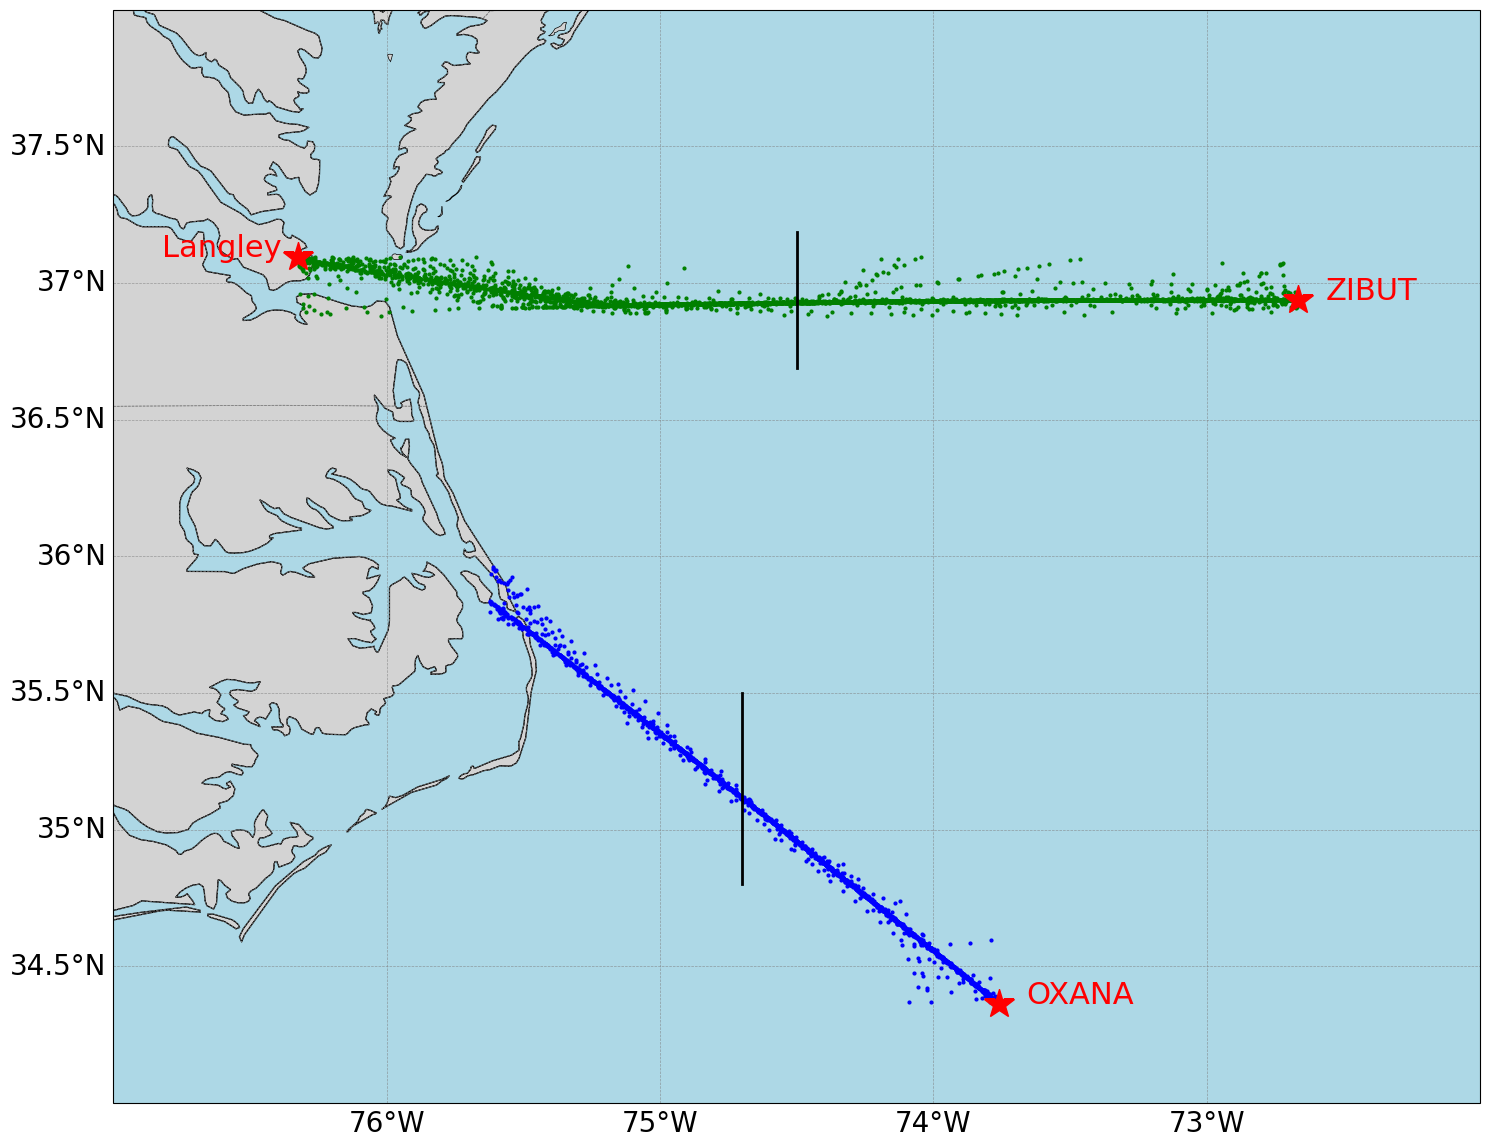

In [74]:
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# Define site coordinates
special_locations = {
    "ZIBUT": (36.938, -72.666),
    "OXANA": (34.363, -73.759),
    #"Brigantine NWR": (39.4650, -74.4492),
    #"Cape Romain NWR": (32.9410, -79.6572),
    #"Chassahowitzka NWR": (28.7484, -82.5549),
    #"Dolly Sods Wilderness": (39.1053, -79.4261),
    #"Everglades NP": (25.3910, -80.6806),
    #"Frostburg Reservoir": (39.7058, -79.0122),
    #"James River Face Wilderness": (37.6266, -79.5125),
    #"Linville Gorge": (35.9723, -81.9331),
    #"Okefenokee NWR": (30.7405, -82.1283),
    #"Shenandoah NP": (38.5229, -78.4348),
    #"Shining Rock Wilderness": (35.3937, -82.7744),
    #"Swanquarter": (35.4510, -76.2075),
}

locate = {"Langley": (37.095692, -76.322753),} 
          #"Swanquarter": (35.4510, -76.2075)}
# Separate highlighted sites
highlighted_sites = {"ZIBUT", "OXANA", "Langley"}

# Create figure
fig, ax = plt.subplots(figsize=(15, 15), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-77, -72, 34, 38], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.STATES, linestyle='--', linewidth=0.5, edgecolor='gray')

# Add gridlines
gridlines = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
gridlines.top_labels = False
gridlines.right_labels = False
gridlines.xformatter = LONGITUDE_FORMATTER
gridlines.yformatter = LATITUDE_FORMATTER
gridlines.xlabel_style = {'size': 20, 'color': 'black'}
gridlines.ylabel_style = {'size': 20, 'color': 'black'}

# Plot HYSPLIT altitude data if available (you can replace/remove if not applicable)
#sc = ax.scatter(
#    Hysplit['lon'], Hysplit['lat'],
#    c=Hysplit['altitude'], cmap='seismic', s=30, edgecolor='k', alpha=0.7, label='Altitude'
#)
ax.plot(
    Zibut['Longitude_THORNHILL'],
    Zibut['Latitude_THORNHILL'],
    'o', markersize=2, color='green', label='Filtered Zibut Flight Path'
)
ax.plot(
    Oxana_filtered['Longitude_THORNHILL'],
    Oxana_filtered['Latitude_THORNHILL'],
    'o', markersize=2, color='blue', label='Filtered Oxana Flight Path'
)
# Plot special sites
for name, (lat, lon) in special_locations.items():
    if name in highlighted_sites:
        ax.plot(lon, lat, '*', markersize=22, color='red', label=name, zorder=50)
        ax.text(lon + 0.1, lat, name, fontsize=22, ha='left', color='red', zorder=50)
    else:
        ax.plot(lon, lat, marker='o', markersize=22, color='k', label=name, zorder=50)
        ax.text(lon + 0.2, lat, name, fontsize=22, ha='left', color='k', zorder=50)

for name, (lat, lon) in locate.items():
    if name in highlighted_sites:
        ax.plot(lon, lat, '*', markersize=22, color='red', label=name, zorder=50)
        ax.text(lon - 0.5, lat, name, fontsize=22, ha='left', color='red', zorder=50)
    else:
        ax.plot(lon, lat, marker='o', markersize=22, color='k', label=name, zorder=50)
        ax.text(lon - 0.2, lat - 0.25, name, fontsize=22, ha='left', color='k', zorder=50)
# Colorbar for altitude
#cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.03, extend='both', fraction=0.03, aspect=20)
#cbar.ax.tick_params(labelsize=18)
#cbar.set_label('Altitude (m)', fontsize=16)

# Legend
#ax.legend(loc='upper left', fontsize=16)

# Add vertical line at -74.5 longitude near Zibut
ax.plot([-74.5, -74.5], [special_locations['ZIBUT'][0] - 0.25, special_locations['ZIBUT'][0] + 0.25],
        color='black', linewidth=2, transform=ccrs.PlateCarree())

# Add vertical line at -74.5 longitude near Oxana
ax.plot([-74.7, -74.7], [34.8, 35.5], color='black', linewidth=2, transform=ccrs.PlateCarree())



plt.tight_layout()
plt.show()


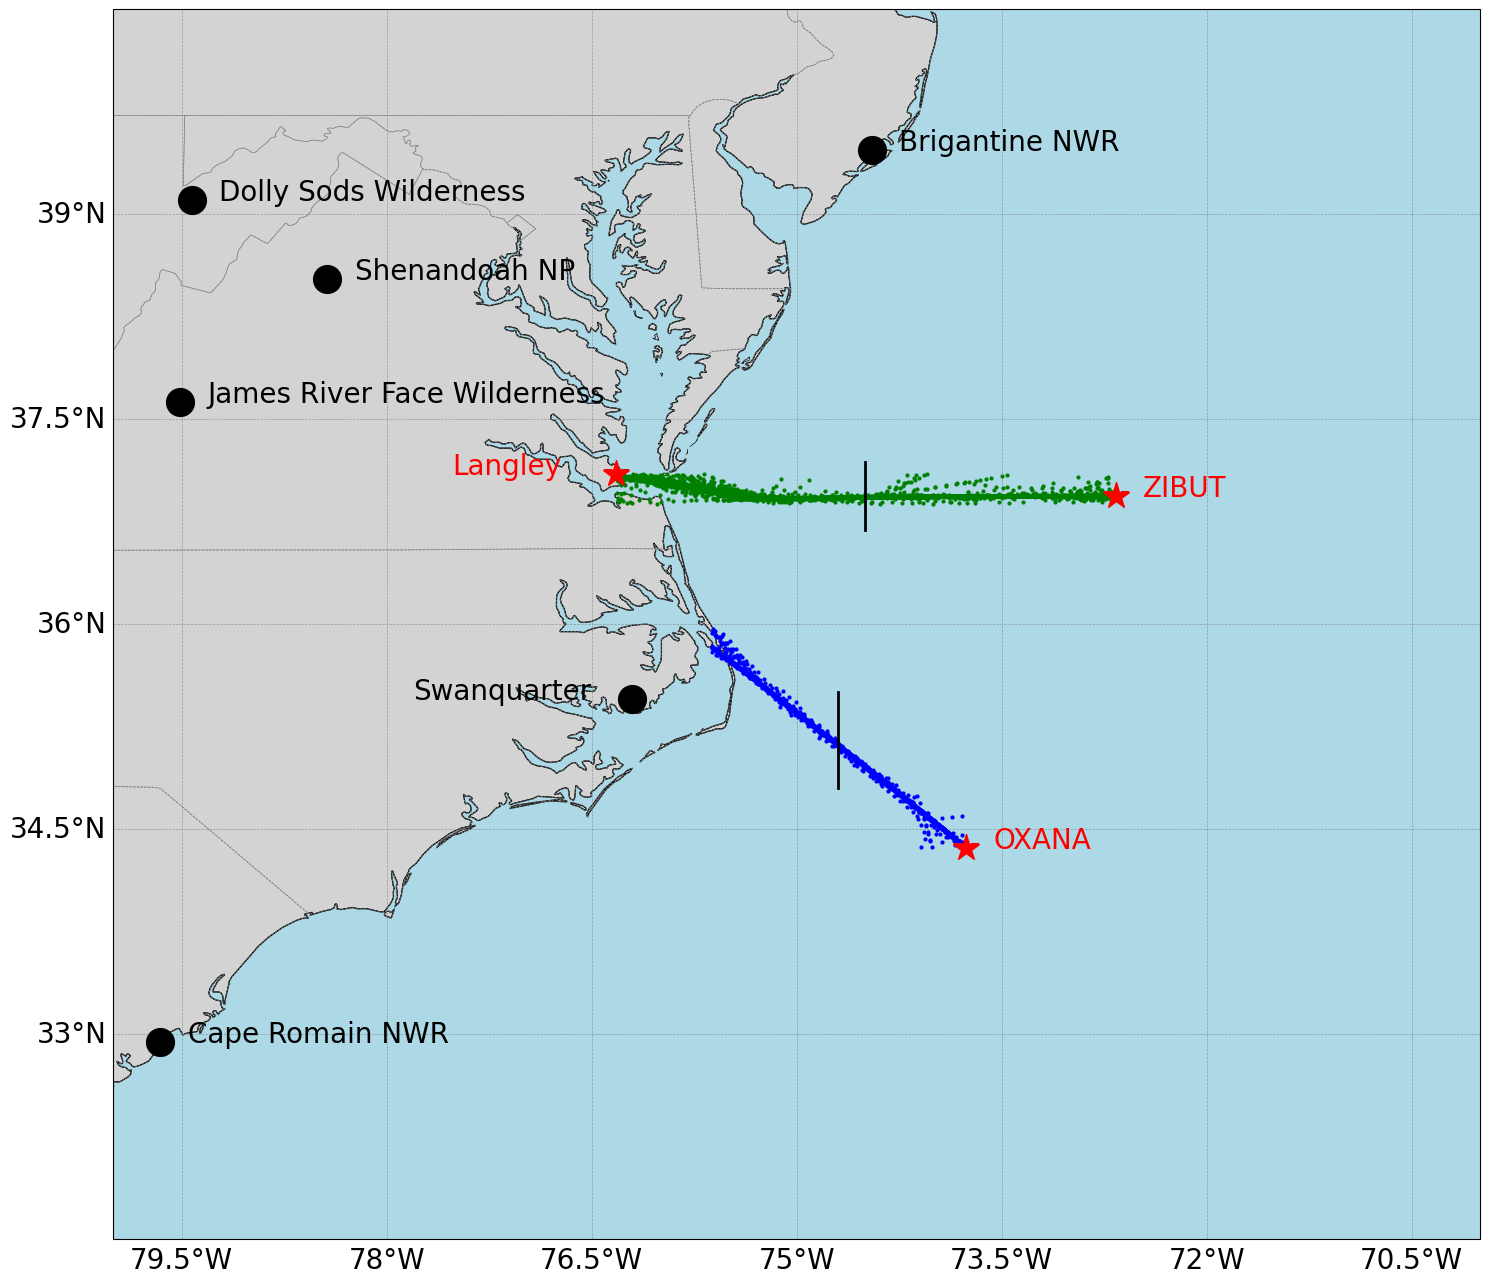

In [75]:
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# Define site coordinates
special_locations = {
    "ZIBUT": (36.938, -72.666),
    "OXANA": (34.363, -73.759),
    "Brigantine NWR": (39.4650, -74.4492),
    "Cape Romain NWR": (32.9410, -79.6572),
    #"Chassahowitzka NWR": (28.7484, -82.5549),
    "Dolly Sods Wilderness": (39.1053, -79.4261),
    #"Everglades NP": (25.3910, -80.6806),
    #"Frostburg Reservoir": (39.7058, -79.0122),
    "James River Face Wilderness": (37.6266, -79.5125),
    #"Linville Gorge": (35.9723, -81.9331),
    #"Okefenokee NWR": (30.7405, -82.1283),
    "Shenandoah NP": (38.5229, -78.4348),
    #"Shining Rock Wilderness": (35.3937, -82.7744),
    #"Swanquarter": (35.4510, -76.2075),
}

locate = {"Langley": (37.095692, -76.322753),
          "Swanquarter": (35.4510, -76.2075)}
# Separate highlighted sites
highlighted_sites = {"ZIBUT", "OXANA", "Langley"}

# Create figure
fig, ax = plt.subplots(figsize=(15, 15), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-80, -70, 31.5, 40.5], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.STATES, linestyle='--', linewidth=0.5, edgecolor='gray')

# Add gridlines
gridlines = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
gridlines.top_labels = False
gridlines.right_labels = False
gridlines.xformatter = LONGITUDE_FORMATTER
gridlines.yformatter = LATITUDE_FORMATTER
gridlines.xlabel_style = {'size': 20, 'color': 'black'}
gridlines.ylabel_style = {'size': 20, 'color': 'black'}

# Plot HYSPLIT altitude data if available (you can replace/remove if not applicable)
#sc = ax.scatter(
#    Hysplit['lon'], Hysplit['lat'],
#    c=Hysplit['altitude'], cmap='seismic', s=30, edgecolor='k', alpha=0.7, label='Altitude'
#)
ax.plot(
    Zibut['Longitude_THORNHILL'],
    Zibut['Latitude_THORNHILL'],
    'o', markersize=2, color='green', label='Filtered Zibut Flight Path'
)
ax.plot(
    Oxana_filtered['Longitude_THORNHILL'],
    Oxana_filtered['Latitude_THORNHILL'],
    'o', markersize=2, color='blue', label='Filtered Oxana Flight Path'
)
# Plot special sites
for name, (lat, lon) in special_locations.items():
    if name in highlighted_sites:
        ax.plot(lon, lat, '*', markersize=20, color='red', label=name, zorder=50)
        ax.text(lon + 0.2, lat, name, fontsize=20, ha='left', color='red', zorder=50)
    else:
        ax.plot(lon, lat, marker='o', markersize=20, color='k', label=name, zorder=50)
        ax.text(lon + 0.2, lat, name, fontsize=20, ha='left', color='k', zorder=50)

for name, (lat, lon) in locate.items():
    if name in highlighted_sites:
        ax.plot(lon, lat, '*', markersize=20, color='red', label=name, zorder=50)
        ax.text(lon - 1.2, lat, name, fontsize=20, ha='left', color='red', zorder=50)
    else:
        ax.plot(lon, lat, marker='o', markersize=20, color='k', label=name, zorder=50)
        ax.text(lon - 1.6, lat, name, fontsize=20, ha='left', color='k', zorder=50)
# Colorbar for altitude
#cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.03, extend='both', fraction=0.03, aspect=20)
#cbar.ax.tick_params(labelsize=18)
#cbar.set_label('Altitude (m)', fontsize=16)

# Legend
#ax.legend(loc='upper left', fontsize=16)

# Add vertical line at -74.5 longitude near Zibut
ax.plot([-74.5, -74.5], [special_locations['ZIBUT'][0] - 0.25, special_locations['ZIBUT'][0] + 0.25],
        color='black', linewidth=2, transform=ccrs.PlateCarree())

# Add vertical line at -74.5 longitude near Oxana
ax.plot([-74.7, -74.7], [34.8, 35.5], color='black', linewidth=2, transform=ccrs.PlateCarree())



plt.tight_layout()
plt.show()


In [76]:
# Filter rows where 'CCN_SS_MOORE' is between 0.37 and 0.43 (inclusive)
SS_2020_ox = Oxana_filtered[(Oxana_filtered['CCN_SS_MOORE'] >= 0.37) & (Oxana_filtered['CCN_SS_MOORE'] <= 0.43)].copy()
SS_2020_zibut = Zibut[(Zibut['CCN_SS_MOORE'] >= 0.37) & (Zibut['CCN_SS_MOORE'] <= 0.43)].copy()

# Display the resulting filtered data

SS_2020_ox


,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,Pressure_Altitude_THORNHILL,Pitch_THORNHILL,Roll_THORNHILL,True_Heading_THORNHILL,True_Air_Speed_THORNHILL,...,LWC_MOORE_CAS,Reff_MOORE_CAS,Veff_MOORE_CAS,Julian_Day,LegIndex,ratio,Subtract_3_10,Subtract_10_0.1,Total_S,COratio
229,2020-02-15 17:35:30,2020-02-15 17:36:30,35.017248,-74.576446,1725.2200,5302.7500,5.02517,-1.11008,130.7276,128.4187,...,8.913000e-07,0.590050,0.165800,46,05,1.366692,210.3768,474.6072,16.453431,14.468459
230,2020-02-15 17:36:30,2020-02-15 17:37:30,34.969075,-74.515545,1667.0200,5100.8200,3.71008,-0.90592,130.6848,129.7471,...,1.004000e-04,0.533860,0.103550,46,05,1.612581,1549.1500,2002.6890,80.319886,14.507168
312,2020-02-15 18:58:30,2020-02-15 18:59:30,34.782266,-74.277851,850.1456,2366.6600,2.08200,-0.99942,316.2612,130.0644,...,2.972000e-07,0.409010,0.180010,46,08,1.451175,305.4561,416.5679,38.277285,15.180879
323,2020-02-15 19:09:30,2020-02-15 19:10:30,35.254801,-74.876056,129.2567,-67.8591,4.94117,-1.03425,314.6049,118.3438,...,9.784000e-07,0.827130,0.231200,46,06,1.417336,914.0400,1682.4557,65.889330,14.903415
324,2020-02-15 19:10:30,2020-02-15 19:11:30,35.294587,-74.929154,139.9767,-31.0701,4.41258,-0.94758,314.5227,117.6822,...,1.964000e-08,0.811843,0.223627,46,06,1.363502,376.9300,697.7005,33.160870,15.045060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31646,2022-03-26 18:02:30,2022-03-26 18:03:30,35.453745,-75.129417,156.5136,642.4977,8.16608,-0.77292,139.8710,107.5625,...,0.000000e+00,1.448000,0.257650,22085,06,1.408418,3640.4800,8539.2372,52.618200,14.487102
31788,2022-03-26 20:24:30,2022-03-26 20:25:30,35.143275,-74.731185,239.8401,926.4085,3.23908,-1.72133,308.4758,119.4975,...,0.000000e+00,1.448000,0.257650,22085,08,1.291740,1075.8400,3119.6243,66.716400,14.463561
31789,2022-03-26 20:25:30,2022-03-26 20:26:30,35.184482,-74.783574,126.3800,556.0353,5.09200,-1.49867,308.1089,118.0712,...,0.000000e+00,1.448000,0.257650,22085,08,1.275985,1042.5000,3232.7043,64.482500,14.552736
31790,2022-03-26 20:26:30,2022-03-26 20:27:30,35.224910,-74.835033,124.5223,558.4643,5.41867,-1.55042,307.9355,114.8041,...,0.000000e+00,1.448000,0.257650,22085,06,1.280710,1084.8000,3340.5657,64.202900,14.521101


In [77]:
# filepath: compute_normalized_median.py

def compute_weekday_mean_normalized(df, reference_df):
    """
    Normalizes each row using the global median from reference_df,
    then computes median for each weekday.
    """

    weekdays_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

    df = df.copy()
    df['Time_Start'] = pd.to_datetime(df['Time_Start'], errors="coerce")
    df['DayOfWeek'] = df['Time_Start'].dt.day_name()

    excluded_cols = [
        'Time_Start', 'Time_Stop', 'Latitude_THORNHILL', 'Longitude_THORNHILL', 'DayOfWeek',
        'GPS_Altitude_THORNHILL', 'Pressure_Altitude_THORNHILL', 'Pitch_THORNHILL', 'Roll_THORNHILL',
        'True_Heading_THORNHILL', 'True_Air_Speed_THORNHILL'
    ]
    numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(excluded_cols, sort=False)

    # Step 1: Compute global median from reference_df
    global_median = reference_df[numeric_cols].mean(skipna=True)

    # Step 2: Normalize each row in df by global median
    normalized_numeric = df[numeric_cols].divide(global_median, axis=1)

    # Step 3: Append DayOfWeek back
    normalized_numeric['DayOfWeek'] = df['DayOfWeek']

    # Step 4: Group by DayOfWeek, compute median
    grouped = normalized_numeric.groupby("DayOfWeek").mean().reset_index()
    grouped = grouped.set_index("DayOfWeek").reindex(weekdays_order).reset_index()

    # Step 5: Prepare output dictionary
    aggregated_data = {}
    for _, row in grouped.iterrows():
        day = row["DayOfWeek"]
        aggregated_data[day] = {col: row[col] for col in numeric_cols}

    return aggregated_data


# ✅ Combine datasets for reference
combined_reference_df = pd.concat([Oxana_filtered, Zibut])

# ✅ Example Usage
aggregated_data_air = compute_weekday_mean_normalized(Oxana_filtered, combined_reference_df)
aggregated_data_air_zi = compute_weekday_mean_normalized(Zibut, combined_reference_df)

# ✅ Output check
print(aggregated_data_air)
print(aggregated_data_air_zi)


{'Monday': {'Static_Air_Temp_THORNHILL': 0.7975128458244807, 'IR_Surf_Temp_THORNHILL': 1.1475987409122184, 'Static_Pressure_THORNHILL': 0.9937252599400055, 'WSPD_ms-1_THORNHILL': 0.8862402720718431, 'WDIR_deg_THORNHILL': 1.2510277118087196, 'U_ms-1_THORNHILL': 1.596660602155103, 'V_ms-1_THORNHILL': -0.6191392148767766, 'w_ms-1_THORNHILL': 0.35068169788270814, 'H2O_DLH_DISKIN': 0.7475971793143379, 'RHi_DLH_DISKIN': 1.027698456641853, 'RHw_DLH_DISKIN': 0.9142896312450689, 'Date_CORRAL': 1.0001048579498184, 'O3_ppbv_DISKIN': 1.0228644745007793, 'CO_ppm_DISKIN': 1.0284748264760455, 'CH4_ppm_DISKIN': 1.0018742745341704, 'CO2_ppm_DISKIN': 1.0039472006665606, 'InletFlag_LARGE_ZIEMBA': 0.5024682842625663, 'CNgt3nm_ZIEMBA': 1.3236773602215628, 'CNgt10nm_ZIEMBA': 1.304867475970739, 'CNgt10nm_nonvol_ZIEMBA': 1.2007506581341119, 'IntegN_100to1000nm_LAS_ZIEMBA': 1.0510718187604153, 'IntegS_100to1000nm_LAS_ZIEMBA': 0.93195590960544, 'IntegV_100to1000nm_LAS_ZIEMBA': 0.8891067024857863, 'IntegN_gt1000

In [78]:
combined_reference_df_ss = pd.concat([SS_2020_ox, SS_2020_zibut])

# ✅ Example Usage (Normalize using combined reference dataset)
aggregated_data_airss = compute_weekday_mean_normalized(SS_2020_ox, D2_filtered)
aggregated_data_air_ziss = compute_weekday_mean_normalized(SS_2020_zibut, D2_filtered)

# ✅ Example Access (Normalized mean values for each day of the week)
print(aggregated_data_airss)
print(aggregated_data_air_ziss)

{'Monday': {'Static_Air_Temp_THORNHILL': 0.7450491603388604, 'IR_Surf_Temp_THORNHILL': 1.0761753782672736, 'Static_Pressure_THORNHILL': 0.9892885348445677, 'WSPD_ms-1_THORNHILL': 0.7974641578170769, 'WDIR_deg_THORNHILL': 1.1641058784001987, 'U_ms-1_THORNHILL': 1.0983705439226972, 'V_ms-1_THORNHILL': -0.7230191792866829, 'w_ms-1_THORNHILL': 0.3909790239136305, 'H2O_DLH_DISKIN': 0.6612631671775753, 'RHi_DLH_DISKIN': 1.11334818391416, 'RHw_DLH_DISKIN': 0.8901174384595437, 'Date_CORRAL': 1.0000163630578331, 'O3_ppbv_DISKIN': 1.0789121113347329, 'CO_ppm_DISKIN': 1.046244808709503, 'CH4_ppm_DISKIN': 1.0035402103057076, 'CO2_ppm_DISKIN': 1.0025938280713944, 'InletFlag_LARGE_ZIEMBA': 0.39982295675746987, 'CNgt3nm_ZIEMBA': 0.896410276142717, 'CNgt10nm_ZIEMBA': 1.000999691719363, 'CNgt10nm_nonvol_ZIEMBA': 1.2137527655790348, 'IntegN_100to1000nm_LAS_ZIEMBA': 1.1532289356285241, 'IntegS_100to1000nm_LAS_ZIEMBA': 0.9782578461315693, 'IntegV_100to1000nm_LAS_ZIEMBA': 0.848218622349269, 'IntegN_gt1000n

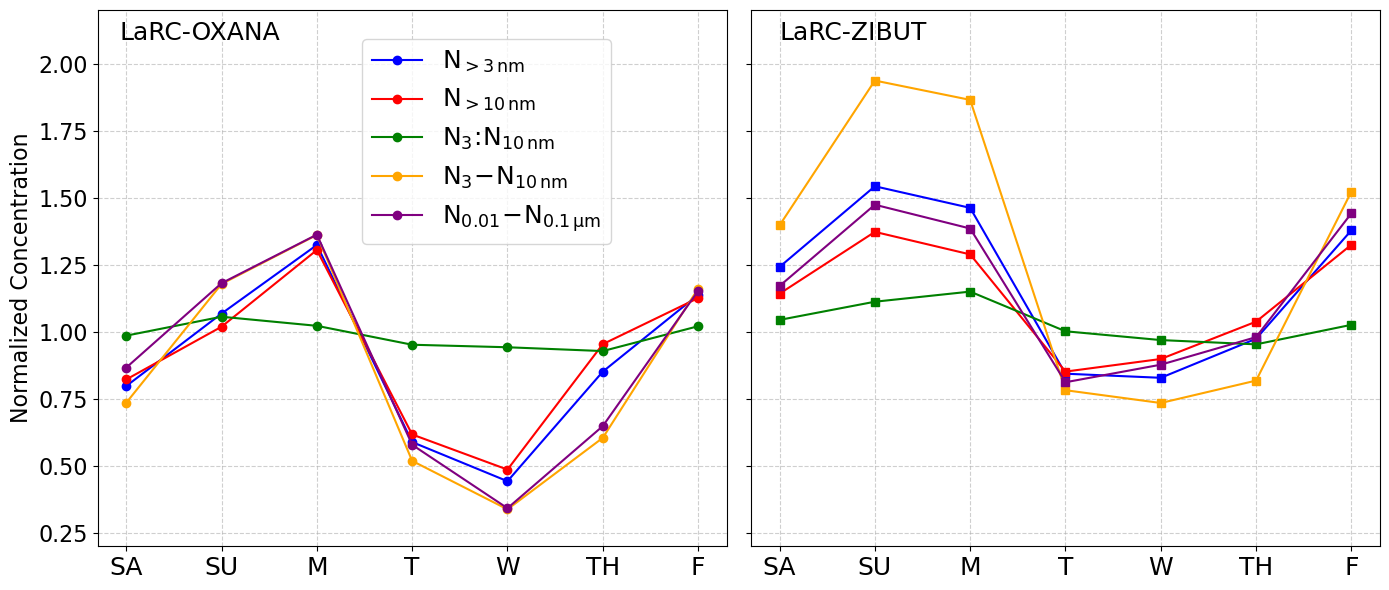

In [79]:
SHORT_DAY = {
    "Saturday": "SA", "Sunday": "SU", "Monday": "M",
    "Tuesday": "T", "Wednesday": "W", "Thursday": "TH", "Friday": "F"
}

def plot_weekday_mean(aggregated_oxana, aggregated_zibut, variables, y_labels):
    """
    Plots the mean values for multiple variables across weekdays for Oxana and Zibut.
    Uses a 1x2 subplot layout (Oxana on left, Zibut on right).
    """

    weekdays_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
    short_labels = [SHORT_DAY[d] for d in weekdays_order]

    # ✅ Create 1x2 subplot layout
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

    # Define colors for different variables
    colors = ["b", "r", "g", "orange", "purple", "k"]

    # ✅ Plot for Oxana (Left Subplot)
    ax1 = axes[0]
    for i, (variable, y_label) in enumerate(zip(variables, y_labels)):
        oxana_values = [aggregated_oxana.get(day, {}).get(variable, None) for day in weekdays_order]
        ax1.plot(weekdays_order, oxana_values, marker="o", linestyle="-", color=colors[i % len(colors)], label=y_label)

    #ax1.set_title("Oxana", fontsize=16)
    ax1.set_ylabel("Normalized Concentration", fontsize=16)
    ax1.grid(True, linestyle="--", alpha=0.6)
    ax1.tick_params(axis='both', labelsize=16)
    ax1.legend(loc='upper left', bbox_to_anchor=(0.4, 0.97), fontsize=18)  #loc="upper center"
    ax1.text(0.29, 0.98, "LaRC-OXANA", transform=ax1.transAxes, fontsize=18, va="top", ha="right")

    # ✅ Plot for Zibut (Right Subplot)
    ax2 = axes[1]
    for i, (variable, y_label) in enumerate(zip(variables, y_labels)):
        zibut_values = [aggregated_zibut.get(day, {}).get(variable, None) for day in weekdays_order]
        ax2.plot(weekdays_order, zibut_values, marker="s", linestyle="-", color=colors[i % len(colors)], label=y_label)

    #ax2.set_title("Zibut", fontsize=16)
    ax2.grid(True, linestyle="--", alpha=0.6)
    ax2.tick_params(axis='both', labelsize=18)
    ax2.text(0.28, 0.98, "LaRC-ZIBUT", transform=ax2.transAxes, fontsize=18, va="top", ha="right")
    #ax2.legend(fontsize=12)

    # ✅ Set common X-axis label
    for ax in axes:
        ax.set_xticks(range(len(weekdays_order)))
        ax.set_xticklabels(short_labels, fontsize=18)
        ax.set_ylim(0.2, 2.2)

    #plt.suptitle("Weekday Mean for Oxana & Zibut", fontsize=18)
    plt.tight_layout()
    plt.show()

# ✅ Example Usage
variables = ['CNgt3nm_ZIEMBA', 'CNgt10nm_ZIEMBA', 'ratio', 'Subtract_3_10', 'Subtract_10_0.1'] # nSMPS_ZIEMBA 'Subtract_3_10' 'nSMPS_ZIEMBA', 'CNgt10nm_nonvol_ZIEMBA']
y_labels = [
    r"$\mathrm{N}_{>3\,\mathrm{nm}}$",
    r"$\mathrm{N}_{>10\,\mathrm{nm}}$",
    #r"$\mathrm{N_{3{-}10\, nm}}$",
    r"$\mathrm{N_{3}\!:\!N_{10\,nm}}$",
    r"$\mathrm{N_{3}\!-\!N_{10\,nm}}$",
    r"$\mathrm{N_{0.01}\!-\!N_{0.1\,\mu m}}$", 
    #r"# Conc$_{\mathrm{non volatile}}$",  
]
plot_weekday_mean(aggregated_data_air, aggregated_data_air_zi, variables, y_labels)


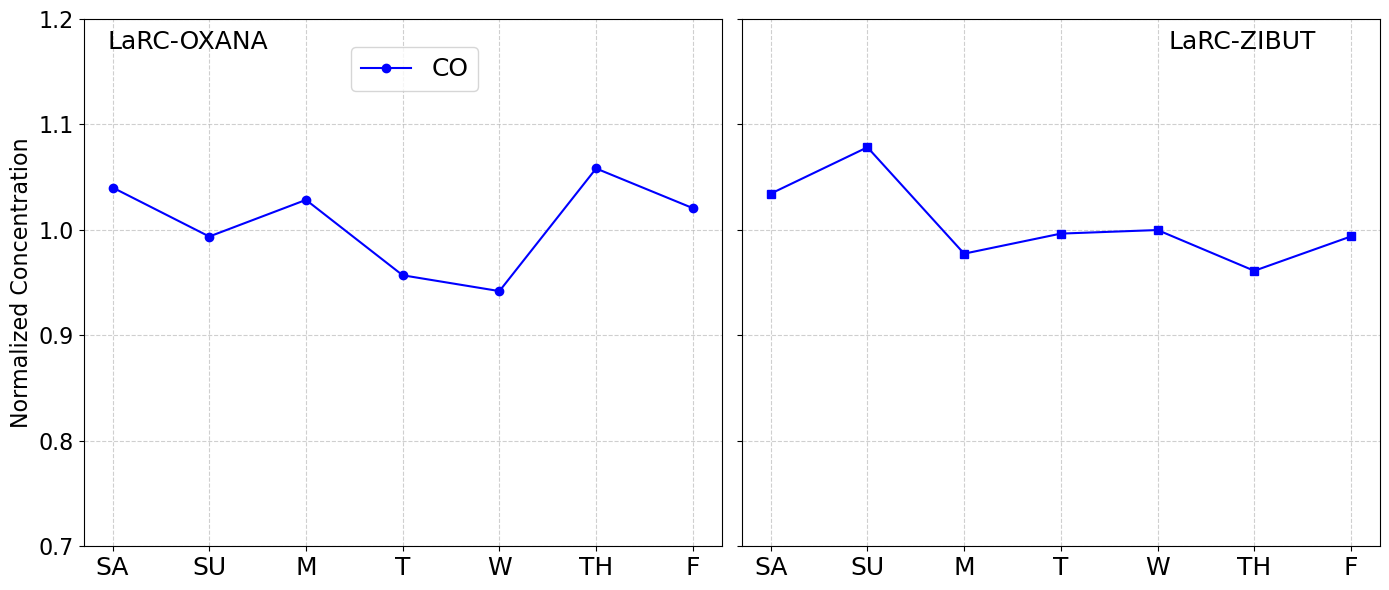

In [84]:
SHORT_DAY = {
    "Saturday": "SA", "Sunday": "SU", "Monday": "M",
    "Tuesday": "T", "Wednesday": "W", "Thursday": "TH", "Friday": "F"
}

def plot_weekday_mean(aggregated_oxana, aggregated_zibut, variables, y_labels):
    """
    Plots the mean values for multiple variables across weekdays for Oxana and Zibut.
    Uses a 1x2 subplot layout (Oxana on left, Zibut on right).
    """

    weekdays_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
    short_labels = [SHORT_DAY[d] for d in weekdays_order]

    # ✅ Create 1x2 subplot layout
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

    # Define colors for different variables
    colors = ["b", "r", "g", "orange", "purple", "k"]

    # ✅ Plot for Oxana (Left Subplot)
    ax1 = axes[0]
    for i, (variable, y_label) in enumerate(zip(variables, y_labels)):
        oxana_values = [aggregated_oxana.get(day, {}).get(variable, None) for day in weekdays_order]
        ax1.plot(weekdays_order, oxana_values, marker="o", linestyle="-", color=colors[i % len(colors)], label=y_label)

    #ax1.set_title("Oxana", fontsize=16)
    ax1.set_ylabel("Normalized Concentration", fontsize=16)
    ax1.grid(True, linestyle="--", alpha=0.6)
    ax1.tick_params(axis='both', labelsize=16)
    ax1.legend(loc='upper left', bbox_to_anchor=(0.4, 0.97), fontsize=18)  #loc="upper center"
    ax1.text(0.29, 0.98, "LaRC-OXANA", transform=ax1.transAxes, fontsize=18, va="top", ha="right")

    # ✅ Plot for Zibut (Right Subplot)
    ax2 = axes[1]
    for i, (variable, y_label) in enumerate(zip(variables, y_labels)):
        zibut_values = [aggregated_zibut.get(day, {}).get(variable, None) for day in weekdays_order]
        ax2.plot(weekdays_order, zibut_values, marker="s", linestyle="-", color=colors[i % len(colors)], label=y_label)

    #ax2.set_title("Zibut", fontsize=16)
    ax2.grid(True, linestyle="--", alpha=0.6)
    ax2.tick_params(axis='both', labelsize=18)
    ax2.text(0.9, 0.98, "LaRC-ZIBUT", transform=ax2.transAxes, fontsize=18, va="top", ha="right")
    #ax2.legend(fontsize=12)

    # ✅ Set common X-axis label
    for ax in axes:
        ax.set_xticks(range(len(weekdays_order)))
        ax.set_xticklabels(short_labels, fontsize=18)
        ax.set_ylim(0.7, 1.2)

    #plt.suptitle("Weekday Mean for Oxana & Zibut", fontsize=18)
    plt.tight_layout()
    plt.show()

# ✅ Example Usage
#variables = ['NO3_Ave_IsoK_STP_ZIEMBA', 'NH4_Ave_IsoK_STP_ZIEMBA', 'SO4_Ave_IsoK_STP_ZIEMBA', 'Org_Ave_IsoK_STP_ZIEMBA', 'CO_ppm_DISKIN']
variables = ['CO_ppm_DISKIN'] # nSMPS_ZIEMBA 'Subtract_3_10' 'nSMPS_ZIEMBA', 'CNgt10nm_nonvol_ZIEMBA']
y_labels = [
    #r"$\mathrm{NO}_{3}$",
    #r"$\mathrm{NH}_{4}$",
    #r"$\mathrm{SO}_{4}$",
    #r"Org",
    r"CO"
    #r"$\mathrm{N_{3}\!-\!N_{10\,nm}}$",
    #r"$\mathrm{N_{0.01}\!-\!N_{0.1\,\mu m}}$", 
    #r"# Conc$_{\mathrm{non volatile}}$",  
]
plot_weekday_mean(aggregated_data_air, aggregated_data_air_zi, variables, y_labels)


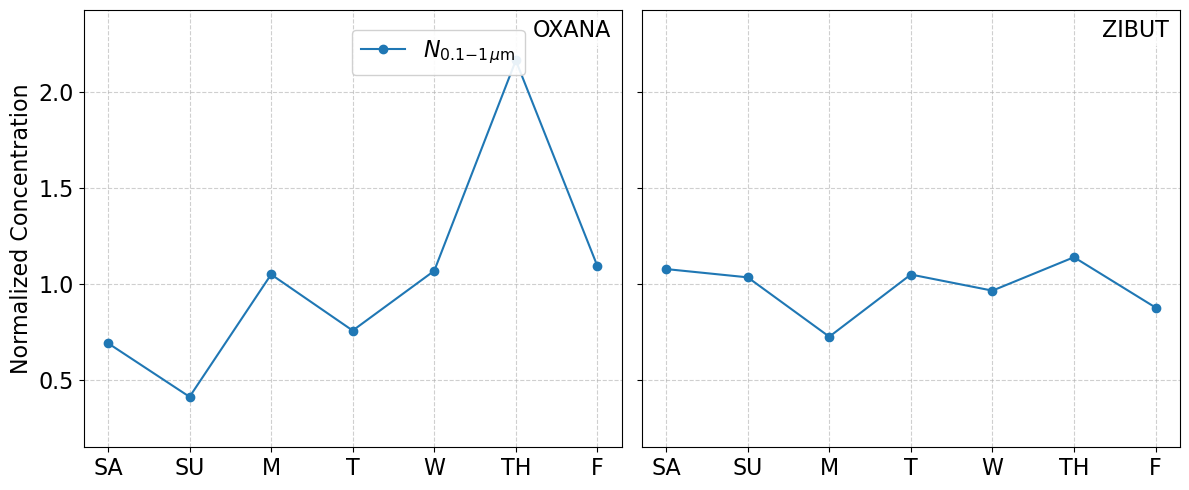

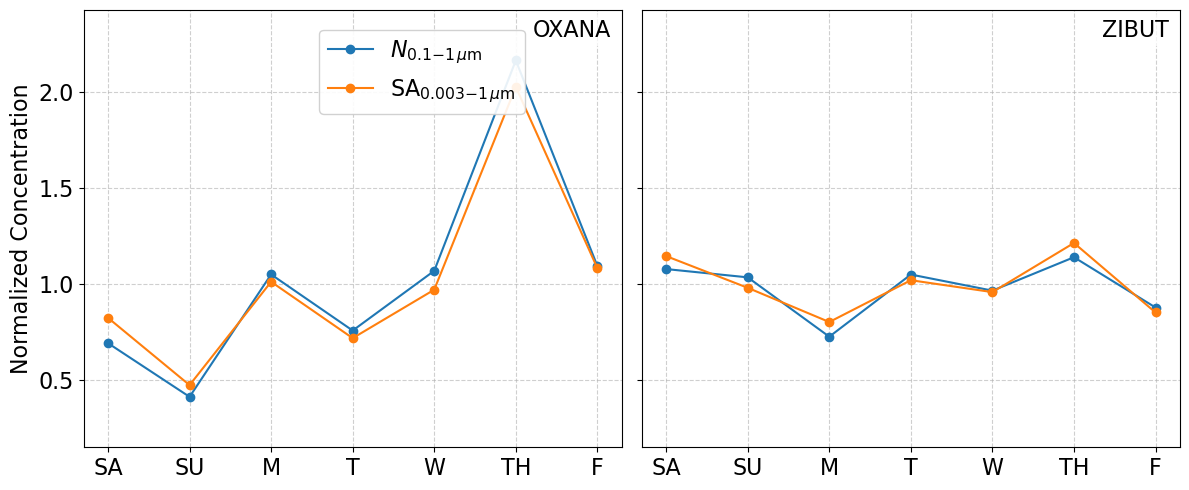

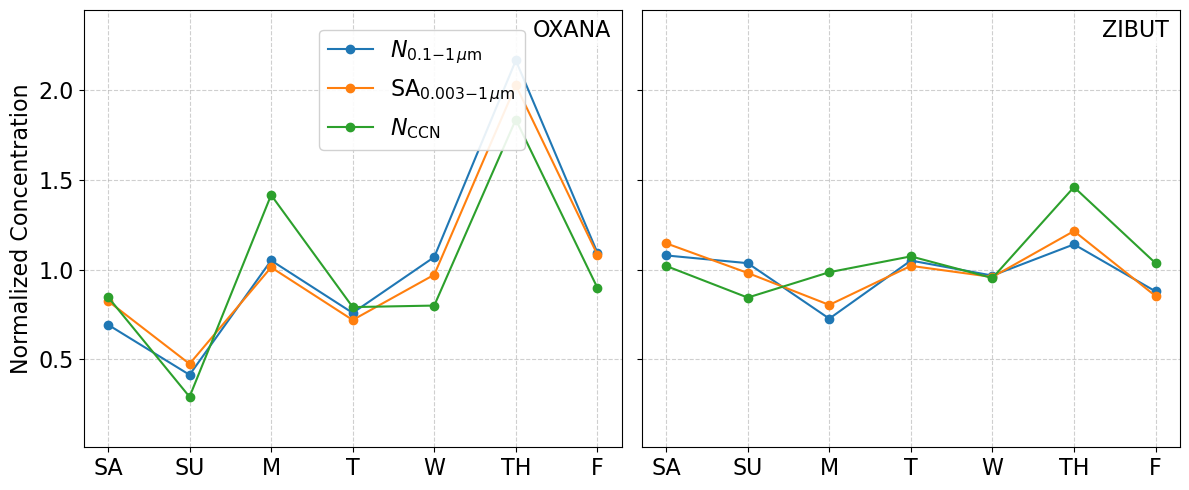

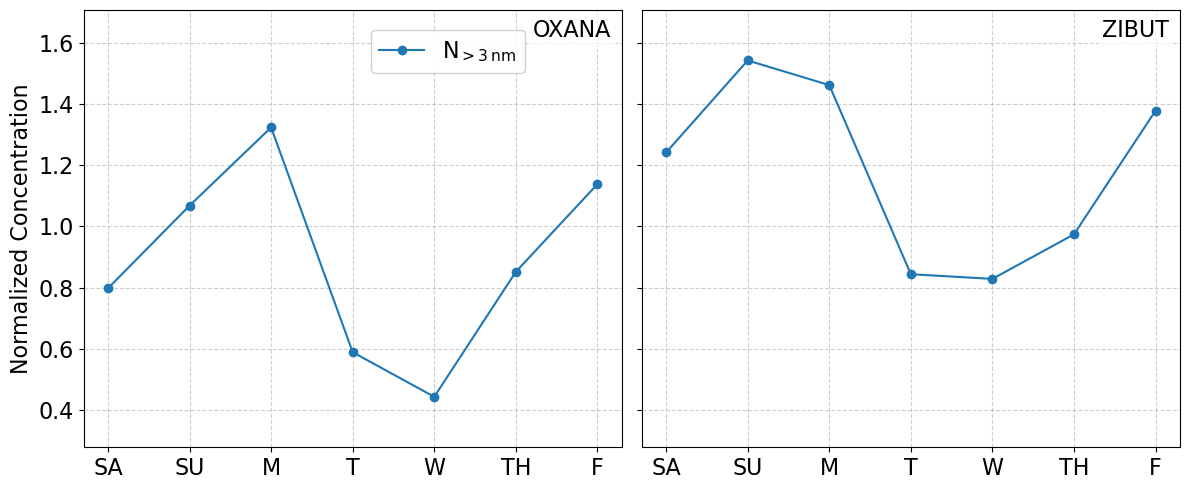

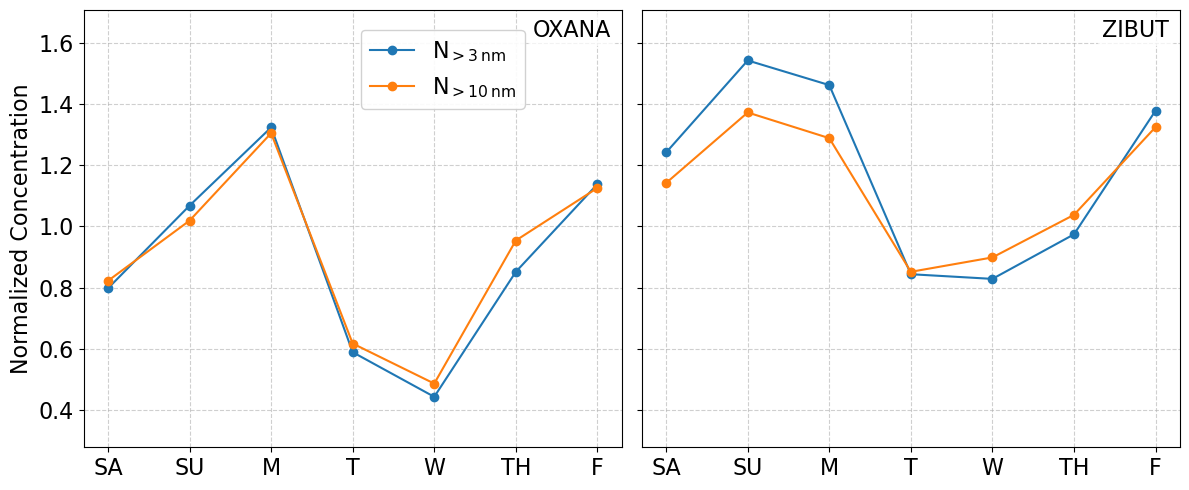

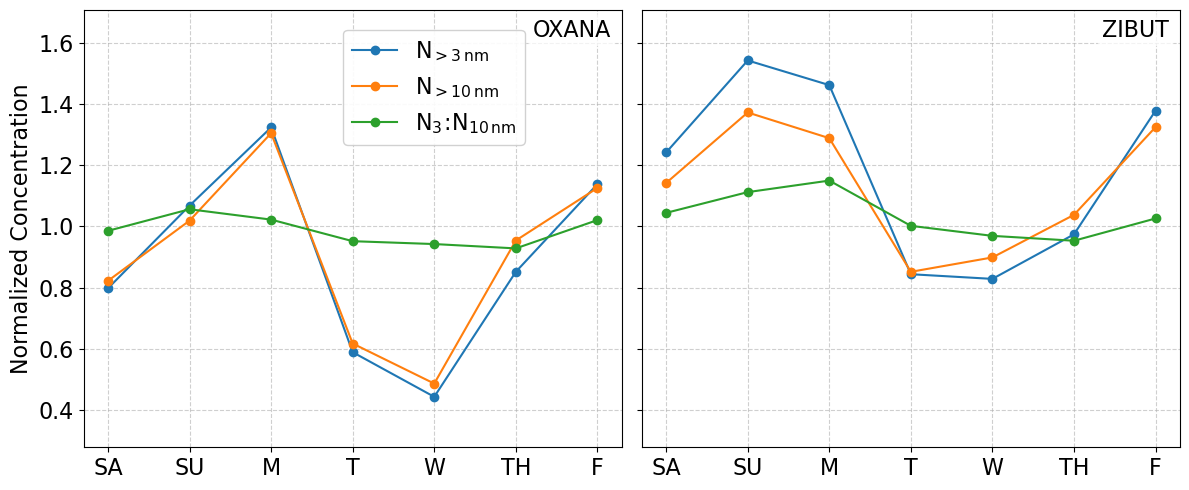

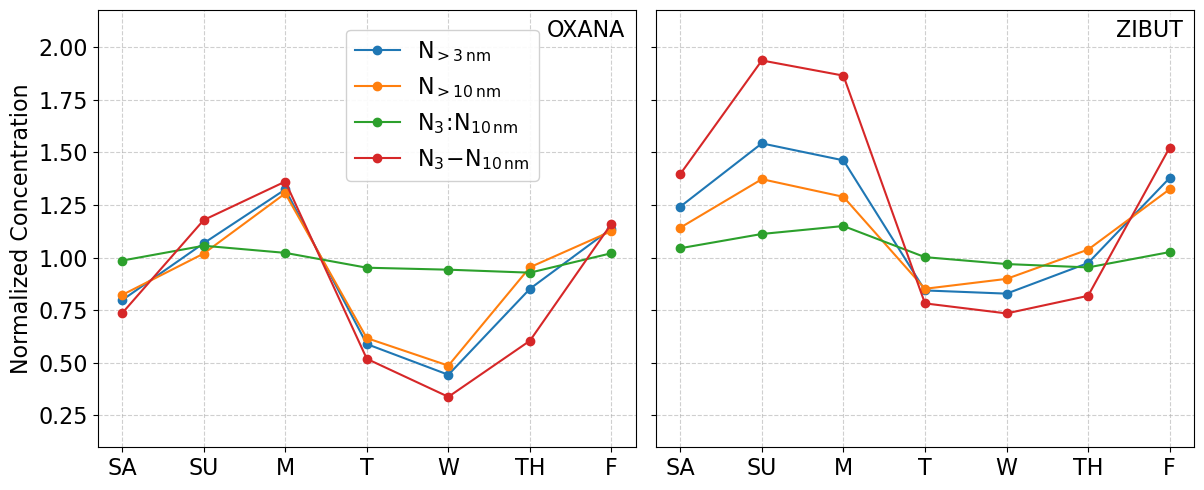

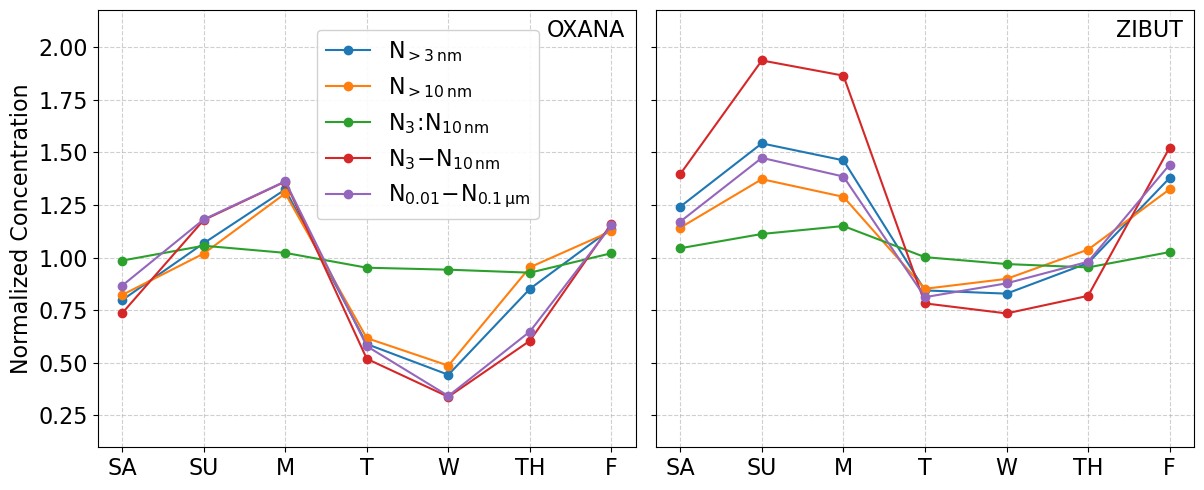

In [91]:
# JUPYTER CELL — run in VS Code
from __future__ import annotations
from typing import Dict, List, Optional, Tuple
import math, os
import matplotlib.pyplot as plt

WeekMap = Dict[str, Dict[str, float]]

WEEKDAYS_ORDER = ["Saturday","Sunday","Monday","Tuesday","Wednesday","Thursday","Friday"]
SHORT_DAY = {"Saturday":"SA","Sunday":"SU","Monday":"M","Tuesday":"T","Wednesday":"W","Thursday":"TH","Friday":"F"}

# ---------------- config ----------------
VARS1   = ['IntegN_100to1000nm_LAS_ZIEMBA', 'Total_S']
LABELS1 = [r"$N_{0.1{-}1\,\mu\mathrm{m}}$", r"$\mathrm{SA}_{0.003{-}1\,\mu\mathrm{m}}$"]
CCN_KEY = "N_CCN_stdPT_MOORE"
CCN_LABEL = r"$N_{\mathrm{CCN}}$"

VARS2   = ['CNgt3nm_ZIEMBA','CNgt10nm_ZIEMBA','ratio','Subtract_3_10','Subtract_10_0.1']
LABELS2 = [
    r"$\mathrm{N}_{>3\,\mathrm{nm}}$", r"$\mathrm{N}_{>10\,\mathrm{nm}}$",
    r"$\mathrm{N_{3}\!:\!N_{10\,nm}}$", r"$\mathrm{N_{3}\!-\!N_{10\,nm}}$",
    r"$\mathrm{N_{0.01}\!-\!N_{0.1\,\mu m}}$"
]

SAVE_DIR: Optional[str] = None      # e.g., "out/plots" (None = just show inline)
YLABEL  = "Normalized Concentration"

# Bottom-set cumulative steps (slides 4–6)
BOTTOM_STEPS = [
    [0],        # slide 4: CNgt3nm_ZIEMBA
    [0, 1],     # slide 5: + CNgt10nm_ZIEMBA
    [0, 1, 2],
    [0, 1, 2, 3],  # slide 6: + ratio
    [0, 1, 2, 3, 4],
]

# --------------- utilities ---------------
def _get_series(daily_map: WeekMap, var: str) -> List[Optional[float]]:
    return [daily_map.get(day, {}).get(var, None) for day in WEEKDAYS_ORDER]

def _safe_name(text: str) -> str:
    bad = {"$":"","{":"","}":"","\\":""," ": "_",":":"_","/":"-","|":"-","*":"x","?":""}
    for k,v in bad.items(): text = text.replace(k,v)
    return text

def _gen_demo_station(seed: float, vars_all: List[str]) -> WeekMap:
    week = {}
    for i, day in enumerate(WEEKDAYS_ORDER):
        base = 1.0 + 0.3 * math.sin((i + seed) * 2 * math.pi / 7.0)
        week[day] = {v: round(base * (1.0 + 0.05 * (hash((v, i)) % 5 - 2)), 3) for v in vars_all}
    return week

def _build_demo() -> Tuple[WeekMap, WeekMap, WeekMap, WeekMap, WeekMap, WeekMap]:
    vars_all = list(set(VARS1 + VARS2 + [CCN_KEY]))
    ox1 = _gen_demo_station(0.0, vars_all)
    zi1 = _gen_demo_station(0.8, vars_all)
    ox2, zi2 = ox1, zi1
    ox_ccn = {d: {CCN_KEY: ox1[d][CCN_KEY]} for d in WEEKDAYS_ORDER}
    zi_ccn = {d: {CCN_KEY: zi1[d][CCN_KEY]} for d in WEEKDAYS_ORDER}
    return ox1, zi1, ox2, zi2, ox_ccn, zi_ccn

def _style_axes(ax, show_ylabel: bool):
    ax.set_xticks(range(len(WEEKDAYS_ORDER)))
    ax.set_xticklabels([SHORT_DAY[d] for d in WEEKDAYS_ORDER])
    ax.tick_params(axis="both", labelsize=16)
    if show_ylabel:
        ax.set_ylabel(YLABEL, fontsize=16)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.margins(x=0.05, y=0.15)  # avoid label/line collision

def _site_tag(ax, text: str):
    ax.text(0.98, 0.98, text, transform=ax.transAxes, va="top", ha="right",
            fontsize=16, bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", boxstyle="round,pad=0.2"))

def _plot_vars_site(
    ax,
    main_map: WeekMap,
    vars_: List[str],
    labels_: List[str],
    *,
    ccn_map: Optional[WeekMap]=None,
    show_legend: bool=True,
):
    x = list(range(len(WEEKDAYS_ORDER)))
    for v, lab in zip(vars_, labels_):
        series = _get_series(ccn_map, CCN_KEY) if (v == CCN_KEY and ccn_map is not None) else _get_series(main_map, v)
        ax.plot(x, series, marker="o", linestyle="-", label=lab)
    if show_legend:
        ax.legend(framealpha=0.9, fontsize=16, loc='upper right', bbox_to_anchor=(0.84, 0.98))

# --------------- slide builder ---------------
def make_slides(
    oxana1: WeekMap, zibut1: WeekMap,
    oxana2: WeekMap, zibut2: WeekMap,
    *, oxana_ccn: Optional[WeekMap], zibut_ccn: Optional[WeekMap],
    save_dir: Optional[str]=None
) -> None:
    if save_dir: os.makedirs(save_dir, exist_ok=True)

    lab1 = dict(zip(VARS1, LABELS1))
    lab2 = dict(zip(VARS2, LABELS2))

    ccn_available = (oxana_ccn is not None) and (zibut_ccn is not None)

    # Slides 1–3: cumulative top-set (1×2)
    top_sets: List[List[str]] = [
        [VARS1[0]],
        [VARS1[0], VARS1[1]],
        [VARS1[0], VARS1[1]] + ([CCN_KEY] if ccn_available else []),
    ]
    top_labels: List[List[str]] = [
        [lab1[VARS1[0]]],
        [lab1[VARS1[0]], lab1[VARS1[1]]],
        [lab1[VARS1[0]], lab1[VARS1[1]]] + ([CCN_LABEL] if ccn_available else []),
    ]

    for idx, (tvars, tlabs) in enumerate(zip(top_sets, top_labels), start=1):
        fig, (ax_ox, ax_zi) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

        _plot_vars_site(ax_ox, oxana1, tvars, tlabs, ccn_map=oxana_ccn, show_legend=True)
        _style_axes(ax_ox, True);  _site_tag(ax_ox, "OXANA")

        _plot_vars_site(ax_zi, zibut1, tvars, tlabs, ccn_map=zibut_ccn, show_legend=False)
        _style_axes(ax_zi, False); _site_tag(ax_zi, "ZIBUT"); ax_zi.tick_params(labelleft=False)

        fig.tight_layout()
        name = f"slide_{idx:02d}_top"
        if save_dir:
            fig.savefig(os.path.join(save_dir, f"{name}.png"), dpi=200); plt.close(fig)
        else:
            plt.show()

    # Slides 4–6: bottom-set only, separate 1×2 figures (no 2×2)
    for step_idx, bottom_idx_list in enumerate(BOTTOM_STEPS, start=4):
        bvars = [VARS2[i] for i in bottom_idx_list]
        blabs = [lab2[VARS2[i]] for i in bottom_idx_list]

        fig, (ax_ox, ax_zi) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

        _plot_vars_site(ax_ox, oxana2, bvars, blabs, show_legend=True)
        _style_axes(ax_ox, True);  _site_tag(ax_ox, "OXANA")

        _plot_vars_site(ax_zi, zibut2, bvars, blabs, show_legend=False)
        _style_axes(ax_zi, False); _site_tag(ax_zi, "ZIBUT"); ax_zi.tick_params(labelleft=False)

        fig.tight_layout()
        name = f"slide_{step_idx:02d}_bottom_{'_'.join(_safe_name(v) for v in bvars)}"
        if save_dir:
            fig.savefig(os.path.join(save_dir, f"{name}.png"), dpi=200); plt.close(fig)
        else:
            plt.show()

# ---- Use your globals; else demo ----
g = globals()
has_user_data = all(n in g for n in [
    "aggregated_data_air",      # Oxana main
    "aggregated_data_air_zi",   # ZIBUT main
    "aggregated_data_airss",    # Oxana CCN
    "aggregated_data_air_ziss"  # ZIBUT CCN
])
if has_user_data:
    oxana1, zibut1 = g["aggregated_data_air"], g["aggregated_data_air_zi"]
    oxana2, zibut2 = g["aggregated_data_air"], g["aggregated_data_air_zi"]  # change if set2 differs
    oxana_ccn, zibut_ccn = g["aggregated_data_airss"], g["aggregated_data_air_ziss"]
else:
    oxana1, zibut1, oxana2, zibut2, oxana_ccn, zibut_ccn = _build_demo()
    print("Using demo data (define aggregated_data_air*, aggregated_data_airss, aggregated_data_air_ziss for CCN).")

# ---- Run ----
make_slides(
    oxana1=oxana1, zibut1=zibut1, oxana2=oxana2, zibut2=zibut2,
    oxana_ccn=oxana_ccn, zibut_ccn=zibut_ccn, save_dir=SAVE_DIR
)


In [81]:
q12`2`

SyntaxError: invalid syntax (184280013.py, line 1)

In [ ]:
list(Zibut)

In [ ]:
Zibut.loc[Zibut["NO3_Ave_IsoK_STP_ZIEMBA"] > 2, "NO3_Ave_IsoK_STP_ZIEMBA"] = np.nan
Zibut.loc[Zibut["Ext532_total_amb_ZIEMBA"] > 40, "Ext532_total_amb_ZIEMBA"] = np.nan
Zibut.loc[Zibut["Sc550_total_amb_ZIEMBA"] > 40, "Sc550_total_amb_ZIEMBA"] = np.nan
Zibut.loc[Zibut["NH4_Ave_IsoK_STP_ZIEMBA"] < 0 , "NH4_Ave_IsoK_STP_ZIEMBA"] = np.nan
Zibut.loc[Zibut["NH4_Ave_IsoK_STP_ZIEMBA"] > threshold3, "NH4_Ave_IsoK_STP_ZIEMBA"] = np.nan


In [ ]:
# --- inputs expected (as in your code) ---
# DataFrames: Zibut, Oxana_filtered (must have 'Longitude_THORNHILL', 'Latitude_THORNHILL')
# Dicts: aggregated_data_air (Oxana), aggregated_data_air_zi (Zibut)
# Variables setup for weekday plot:
SHORT_DAY = {"Saturday": "SA", "Sunday": "SU", "Monday": "M", "Tuesday": "T", "Wednesday": "W", "Thursday": "TH", "Friday": "F"}
variables = ['CNgt3nm_ZIEMBA', 'CNgt10nm_ZIEMBA', 'ratio', 'Subtract_3_10', 'Subtract_10_0.1']
y_labels = [
    r"$\mathrm{N}_{>3\,\mathrm{nm}}$",
    r"$\mathrm{N}_{>10\,\mathrm{nm}}$",
    r"$\mathrm{N_{3}\!:\!N_{10\,nm}}$",
    r"$\mathrm{N_{3}\!-\!N_{10\,nm}}$",
    r"$\mathrm{N_{0.01}\!-\!N_{0.1\,\mu m}}$",
]

def plot_combined(Zibut, Oxana_filtered, aggregated_oxana, aggregated_zibut):
    # --- layout: top map, bottom two subplots ---
    fig = plt.figure(figsize=(16, 12), constrained_layout=True)  # constrained avoids overlap
    gs = fig.add_gridspec(nrows=2, ncols=2, height_ratios=[1.0, 1.0])

    # ---------- TOP: Map ----------
    ax_map = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree())
    ax_map.set_extent([-77, -72, 34, 38], crs=ccrs.PlateCarree())

    ax_map.set_aspect('auto')  # why: stretch to fill the row width
    # map features
    ax_map.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax_map.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax_map.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray')
    ax_map.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax_map.add_feature(cfeature.STATES, linestyle='--', linewidth=0.5, edgecolor='gray')

    gridlines = ax_map.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
    gridlines.top_labels = False
    gridlines.right_labels = False
    gridlines.xformatter = LONGITUDE_FORMATTER
    gridlines.yformatter = LATITUDE_FORMATTER
    gridlines.xlabel_style = {'size': 22, 'color': 'black'}
    gridlines.ylabel_style = {'size': 22, 'color': 'black'}

    # sites
    special_locations = {
        "ZIBUT": (36.938, -72.666),
        "OXANA": (34.363, -73.759),
    }
    locate = {"Langley": (37.095692, -76.322753)}
    highlighted_sites = {"ZIBUT", "OXANA", "Langley"}

    # flight paths
    ax_map.plot(
        Zibut['Longitude_THORNHILL'], Zibut['Latitude_THORNHILL'],
        'o', markersize=2, color='green', label='Filtered Zibut Flight Path'
    )
    ax_map.plot(
        Oxana_filtered['Longitude_THORNHILL'], Oxana_filtered['Latitude_THORNHILL'],
        'o', markersize=2, color='blue', label='Filtered Oxana Flight Path'
    )

    # markers + labels
    for name, (lat, lon) in special_locations.items():
        if name in highlighted_sites:
            ax_map.plot(lon, lat, '*', markersize=22, color='k', zorder=50)
            ax_map.text(lon + 0.1, lat, name, fontsize=22, ha='left', color='k', zorder=50)
        else:
            ax_map.plot(lon, lat, 'o', markersize=10, color='k', zorder=50)
            ax_map.text(lon + 0.2, lat, name, fontsize=22, ha='left', color='k', zorder=50)

    for name, (lat, lon) in locate.items():
        if name in highlighted_sites:
            ax_map.plot(lon, lat, '*', markersize=22, color='k', zorder=50)
            ax_map.text(lon - 0.5, lat, name, fontsize=22, ha='left', color='k', zorder=50)
        else:
            ax_map.plot(lon, lat, 'o', markersize=10, color='k', zorder=50)
            ax_map.text(lon - 0.2, lat - 0.25, name, fontsize=22, ha='left', color='k', zorder=50)

    # vertical guides (why: align with analysis cuts)
    ax_map.plot([-74.5, -74.5], [special_locations['ZIBUT'][0] - 0.25, special_locations['ZIBUT'][0] + 0.25],
                color='black', linewidth=2, transform=ccrs.PlateCarree())
    ax_map.plot([-74.7, -74.7], [34.8, 35.5], color='black', linewidth=2, transform=ccrs.PlateCarree())

    # ---------- BOTTOM: Two subplots ----------
    ax_ox = fig.add_subplot(gs[1, 0])
    ax_zi = fig.add_subplot(gs[1, 1], sharex=ax_ox, sharey=ax_ox)

    weekdays_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
    short_labels = [SHORT_DAY[d] for d in weekdays_order]
    colors = ["b", "r", "g", "orange", "purple", "k"]

    # Oxana
    for i, (var, lab) in enumerate(zip(variables, y_labels)):
        vals = [aggregated_oxana.get(day, {}).get(var, None) for day in weekdays_order]
        ax_ox.plot(range(len(vals)), vals, marker="o", linestyle="-", color=colors[i % len(colors)], label=lab)
    ax_ox.set_ylabel("Normalized Concentration", fontsize=22)
    ax_ox.set_xticks(range(len(weekdays_order)))
    ax_ox.set_xticklabels(short_labels, fontsize=22)
    ax_ox.grid(True, linestyle="--", alpha=0.6)
    ax_ox.tick_params(axis='both', labelsize=22)
    ax_ox.set_ylim(0.2, 2.2)
    ax_ox.legend(loc='upper left', bbox_to_anchor=(0.35, 1.02), fontsize=22)
    ax_ox.text(0.0, 1.02, "LaRC-OXANA", transform=ax_ox.transAxes, fontsize=22, va="bottom")

    # Zibut
    for i, (var, lab) in enumerate(zip(variables, y_labels)):
        vals = [aggregated_zibut.get(day, {}).get(var, None) for day in weekdays_order]
        ax_zi.plot(range(len(vals)), vals, marker="s", linestyle="-", color=colors[i % len(colors)], label=lab)
    ax_zi.set_xticks(range(len(weekdays_order)))
    ax_zi.set_xticklabels(short_labels, fontsize=22)
    ax_zi.grid(True, linestyle="--", alpha=0.6)
    ax_zi.tick_params(axis='both', labelsize=22)
    ax_zi.set_ylim(0.2, 2.2)
    ax_zi.text(0.0, 1.02, "LaRC-ZIBUT", transform=ax_zi.transAxes, fontsize=22, va="bottom")

    plt.show()

# Example:
plot_combined(Zibut, Oxana_filtered, aggregated_data_air, aggregated_data_air_zi)


In [ ]:
def plot_weekday_mean_2x2(oxana1, zibut1, vars1, labels1,
                          oxana2, zibut2, vars2, labels2,
                          oxana_ccn=None, zibut_ccn=None):
    import matplotlib.pyplot as plt

    weekdays_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

    # Share y-axis separately for top and bottom rows
    ax_a, ax_b = axes[0]
    ax_c, ax_d = axes[1]
    ax_b.sharey(ax_a)
    ax_d.sharey(ax_c)

    colors = ["b", "r", "g", "orange", "purple", "brown"]

    # ---- a) LaRC-OXANA (Top left) ----
    for i, (var, label) in enumerate(zip(vars1, labels1)):
        values = [oxana1.get(day, {}).get(var, None) for day in weekdays_order]
        ax_a.plot(weekdays_order, values, marker="o", linestyle="-", color=colors[i % len(colors)], label=label)
    if oxana_ccn:
        ccn = [oxana_ccn.get(day, {}).get("N_CCN_stdPT_MOORE", None) for day in weekdays_order]
        ax_a.plot(weekdays_order, ccn, marker="o", linestyle="--", color="black", label=r"$N_{\mathrm{CCN}}$")
    ax_a.set_ylabel("Normalized Concentration", fontsize=16)
    ax_a.grid(True, linestyle="--", alpha=0.6)
    ax_a.tick_params(labelsize=16)
    ax_a.legend(fontsize=16)
    ax_a.text(0.03, 0.95, "a) LaRC-OXANA", transform=ax_a.transAxes, fontsize=16, va="top")

    # ---- b) LaRC-ZIBUT (Top right) ----
    for i, (var, label) in enumerate(zip(vars1, labels1)):
        values = [zibut1.get(day, {}).get(var, None) for day in weekdays_order]
        ax_b.plot(weekdays_order, values, marker="s", linestyle="-", color=colors[i % len(colors)], label=label)
    if zibut_ccn:
        ccn = [zibut_ccn.get(day, {}).get("N_CCN_stdPT_MOORE", None) for day in weekdays_order]
        ax_b.plot(weekdays_order, ccn, marker="s", linestyle="--", color="black", label=r"$N_{\mathrm{CCN}}$")
    ax_b.grid(True, linestyle="--", alpha=0.6)
    ax_b.tick_params(labelsize=16)
    ax_b.tick_params(labelleft=False)
    ax_b.text(0.03, 0.95, "b) LaRC-ZIBUT", transform=ax_b.transAxes, fontsize=16, va="top")

    # ---- c) LaRC-OXANA (Bottom left) ----
    for i, (var, label) in enumerate(zip(vars2, labels2)):
        values = [oxana2.get(day, {}).get(var, None) for day in weekdays_order]
        ax_c.plot(weekdays_order, values, marker="o", linestyle="-", color=colors[i % len(colors)], label=label)
    ax_c.set_ylabel("Normalized Concentration", fontsize=16)
    ax_c.set_xticks(range(len(weekdays_order)))
    ax_c.set_xticklabels(weekdays_order, rotation=30, fontsize=16)
    ax_c.tick_params(labelsize=16)
    ax_c.grid(True, linestyle="--", alpha=0.6)
    ax_c.legend(fontsize=16)
    ax_c.set_ylim(0.2, 2.2)
    ax_c.text(0.03, 0.95, "c) LaRC-OXANA", transform=ax_c.transAxes, fontsize=16, va="top")

    # ---- d) LaRC-ZIBUT (Bottom right) ----
    for i, (var, label) in enumerate(zip(vars2, labels2)):
        values = [zibut2.get(day, {}).get(var, None) for day in weekdays_order]
        ax_d.plot(weekdays_order, values, marker="s", linestyle="-", color=colors[i % len(colors)], label=label)
    ax_d.set_xticks(range(len(weekdays_order)))
    ax_d.set_xticklabels(weekdays_order, rotation=30, fontsize=16)
    ax_d.tick_params(labelsize=16)
    ax_d.tick_params(labelleft=False)
    ax_d.grid(True, linestyle="--", alpha=0.6)
    #ax_d.legend(fontsize=12)
    ax_d.set_ylim(0.2, 2.2)
    ax_d.text(0.03, 0.95, "d) LaRC-ZIBUT", transform=ax_d.transAxes, fontsize=16, va="top")

    plt.tight_layout()
    plt.show()


# Top row
vars1 = ['IntegN_100to1000nm_LAS_ZIEMBA', 'Total_S']
labels1 = [r"$N_{0.1{-}1\,\mu\mathrm{m}}$", r"$\mathrm{SA}_{0.003{-}1\,\mu\mathrm{m}}$"]

# Bottom row
vars2 = ['CNgt3nm_ZIEMBA', 'CNgt10nm_ZIEMBA', 'ratio', 'Subtract_3_10', 'Subtract_10_0.1']
labels2 = [
    r"$\mathrm{N}_{>3\,\mathrm{nm}}$", r"$\mathrm{N}_{>10\,\mathrm{nm}}$",
    r"$\mathrm{N_{3}\!:\!N_{10\,nm}}$", r"$\mathrm{N_{3}\!-\!N_{10\,nm}}$",
    r"$\mathrm{N_{0.01}\!-\!N_{0.1\,\mu m}}$"
]

plot_weekday_mean_2x2(
    aggregated_data_air,
    aggregated_data_air_zi,
    vars1,
    labels1,
    aggregated_data_air,
    aggregated_data_air_zi,
    vars2,
    labels2,
    oxana_ccn=aggregated_data_airss,
    zibut_ccn=aggregated_data_air_ziss
)


In [ ]:
# file: plots/weekday_mean_2x2.py

SHORT_DAY = {
    "Saturday": "SA", "Sunday": "SU", "Monday": "M",
    "Tuesday": "T", "Wednesday": "W", "Thursday": "TH", "Friday": "F"
}

def plot_weekday_mean_2x2(oxana1, zibut1, vars1, labels1,
                          oxana2, zibut2, vars2, labels2,
                          oxana_ccn=None, zibut_ccn=None):
    import numpy as np
    import matplotlib.pyplot as plt

    weekdays_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
    x = np.arange(len(weekdays_order))                           # numeric axis
    short_labels = [SHORT_DAY[d] for d in weekdays_order]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

    # Share y-axis separately for top and bottom rows
    ax_a, ax_b = axes[0]
    ax_c, ax_d = axes[1]
    ax_b.sharey(ax_a)
    ax_d.sharey(ax_c)

    colors = ["b", "r", "g", "orange", "purple", "brown"]

    # ---- a) LaRC-OXANA (Top left) ----
    for i, (var, label) in enumerate(zip(vars1, labels1)):
        values = [oxana1.get(day, {}).get(var, None) for day in weekdays_order]
        ax_a.plot(x, values, marker="o", linestyle="-", color=colors[i % len(colors)], label=label)
    if oxana_ccn:
        ccn = [oxana_ccn.get(day, {}).get("N_CCN_stdPT_MOORE", None) for day in weekdays_order]
        ax_a.plot(x, ccn, marker="o", linestyle="--", color="black", label=r"$N_{\mathrm{CCN}}$")
    ax_a.set_ylabel("Normalized Concentration", fontsize=16)
    ax_a.grid(True, linestyle="--", alpha=0.6)
    ax_a.tick_params(labelsize=16)
    ax_a.legend(fontsize=16)
    ax_a.text(0.03, 0.95, "a) LaRC-OXANA", transform=ax_a.transAxes, fontsize=16, va="top")

    # ---- b) LaRC-ZIBUT (Top right) ----
    for i, (var, label) in enumerate(zip(vars1, labels1)):
        values = [zibut1.get(day, {}).get(var, None) for day in weekdays_order]
        ax_b.plot(x, values, marker="s", linestyle="-", color=colors[i % len(colors)], label=label)
    if zibut_ccn:
        ccn = [zibut_ccn.get(day, {}).get("N_CCN_stdPT_MOORE", None) for day in weekdays_order]
        ax_b.plot(x, ccn, marker="s", linestyle="--", color="black", label=r"$N_{\mathrm{CCN}}$")
    ax_b.grid(True, linestyle="--", alpha=0.6)
    ax_b.tick_params(labelsize=16)
    ax_b.tick_params(labelleft=False)
    ax_b.text(0.03, 0.95, "b) LaRC-ZIBUT", transform=ax_b.transAxes, fontsize=16, va="top")

    # ---- c) LaRC-OXANA (Bottom left) ----
    for i, (var, label) in enumerate(zip(vars2, labels2)):
        values = [oxana2.get(day, {}).get(var, None) for day in weekdays_order]
        ax_c.plot(x, values, marker="o", linestyle="-", color=colors[i % len(colors)], label=label)
    ax_c.set_ylabel("Normalized Concentration", fontsize=16)
    ax_c.set_xticks(x)
    ax_c.set_xticklabels(short_labels, rotation=0, fontsize=16)  # short labels here
    ax_c.tick_params(labelsize=16)
    ax_c.grid(True, linestyle="--", alpha=0.6)
    ax_c.legend(fontsize=16)
    ax_c.set_ylim(0.2, 2.2)
    ax_c.text(0.03, 0.95, "c) LaRC-OXANA", transform=ax_c.transAxes, fontsize=16, va="top")

    # ---- d) LaRC-ZIBUT (Bottom right) ----
    for i, (var, label) in enumerate(zip(vars2, labels2)):
        values = [zibut2.get(day, {}).get(var, None) for day in weekdays_order]
        ax_d.plot(x, values, marker="s", linestyle="-", color=colors[i % len(colors)], label=label)
    ax_d.set_xticks(x)
    ax_d.set_xticklabels(short_labels, rotation=0, fontsize=16)  # and here
    ax_d.tick_params(labelsize=16)
    ax_d.tick_params(labelleft=False)
    ax_d.grid(True, linestyle="--", alpha=0.6)
    ax_d.set_ylim(0.2, 2.2)
    ax_d.text(0.03, 0.95, "d) LaRC-ZIBUT", transform=ax_d.transAxes, fontsize=16, va="top")

    # Avoid clipping tick labels
    fig.tight_layout()
    #fig.text(0.52, -0.03, "Day of the Week", ha="center", fontsize=16)
    plt.show()


plot_weekday_mean_2x2(
    aggregated_data_air,
    aggregated_data_air_zi,
    vars1,
    labels1,
    aggregated_data_air,
    aggregated_data_air_zi,
    vars2,
    labels2,
    oxana_ccn=aggregated_data_airss,
    zibut_ccn=aggregated_data_air_ziss
)

In [ ]:
def plot_weekday_mean(aggregated_oxana, aggregated_zibut, variables, y_labels,
                      aggregated_oxana_ccn=None, aggregated_zibut_ccn=None):
    """
    Plots weekday mean for multiple variables (from different dicts).
    CCN variable is expected in separate aggregated_*_ccn dictionaries.
    """

    weekdays_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
    colors = ["b", "r", "g", "orange", "purple", "brown"]

    # 🔹 Left: Oxana
    ax1 = axes[0]
    for i, (variable, y_label) in enumerate(zip(variables, y_labels)):
        oxana_values = [aggregated_oxana.get(day, {}).get(variable, None) for day in weekdays_order]
        ax1.plot(weekdays_order, oxana_values, marker="o", linestyle="-", color=colors[i % len(colors)], label=y_label)

    # 🟡 Add CCN from alternate dict (if provided)
    if aggregated_oxana_ccn:
        ccn_oxana = [aggregated_oxana_ccn.get(day, {}).get("N_CCN_stdPT_MOORE", None) for day in weekdays_order]
        ax1.plot(weekdays_order, ccn_oxana, marker="o", linestyle="--", color="black", label=r"$N_{\mathrm{CCN}}$")

    #ax1.set_title("Oxana", fontsize=16)
    ax1.set_ylabel("Normalized Concentration", fontsize=16)
    ax1.grid(True, linestyle="--", alpha=0.6)
    ax1.tick_params(axis='both', labelsize=16)
    ax1.legend(loc='upper left', bbox_to_anchor=(0.14, 0.92), fontsize=16)
    ax1.text(0.29, 0.98, "a) LaRC-OXANA", transform=ax1.transAxes, fontsize=16, va="top", ha="right")

    # 🔹 Right: Zibut
    ax2 = axes[1]
    for i, (variable, y_label) in enumerate(zip(variables, y_labels)):
        zibut_values = [aggregated_zibut.get(day, {}).get(variable, None) for day in weekdays_order]
        ax2.plot(weekdays_order, zibut_values, marker="s", linestyle="-", color=colors[i % len(colors)], label=y_label)

    if aggregated_zibut_ccn:
        ccn_zibut = [aggregated_zibut_ccn.get(day, {}).get("N_CCN_stdPT_MOORE", None) for day in weekdays_order]
        ax2.plot(weekdays_order, ccn_zibut, marker="s", linestyle="--", color="black", label=r"$N_{\mathrm{CCN}}$")

    #ax2.set_title("Zibut", fontsize=16)
    ax2.grid(True, linestyle="--", alpha=0.6)
    ax2.tick_params(axis='both', labelsize=16)
    ax2.text(0.28, 0.98, "b) LaRC-ZIBUT", transform=ax2.transAxes, fontsize=16, va="top", ha="right")

    for ax in axes:
        ax.set_xticks(range(len(weekdays_order)))
        ax.set_xticklabels(weekdays_order, rotation=30, fontsize=16)

    plt.tight_layout()
    plt.show()

variables = ['IntegN_100to1000nm_LAS_ZIEMBA', 'Total_S'] #'IntegN_gt1000nm_LAS_ZIEMBA', 'nLAS_AmmSO4_ZIEMBA'] # 'IntegN_gt1000nm_LAS_ZIEMBA']
y_labels = [
            r"$N_{0.1{-}1\,\mu\mathrm{m}}$",
            r"$\mathrm{SA}_{0.003{-}1\,\mu\mathrm{m}}$"

    #r"$N_{\mathrm{a},\,>1\,\mu\mathrm{m}}$",
    #r"$N_{\mathrm{a},\,0.1{-}5\,\mu\mathrm{m}}$"
]

plot_weekday_mean(
    aggregated_data_air, 
    aggregated_data_air_zi, 
    variables, 
    y_labels,
    aggregated_oxana_ccn=aggregated_data_airss, 
    aggregated_zibut_ccn=aggregated_data_air_ziss
)



In [ ]:
# JUPYTER CELL — drop in and run
from __future__ import annotations
from typing import Dict, List, Optional, Tuple
import math, os
import matplotlib.pyplot as plt

WeekMap = Dict[str, Dict[str, float]]

WEEKDAYS_ORDER = ["Saturday","Sunday","Monday","Tuesday","Wednesday","Thursday","Friday"]
SHORT_DAY = {"Saturday":"SA","Sunday":"SU","Monday":"M","Tuesday":"T","Wednesday":"W","Thursday":"TH","Friday":"F"}

# ---------------- config ----------------
VARS1   = ['IntegN_100to1000nm_LAS_ZIEMBA', 'Total_S']
LABELS1 = [r"$N_{0.1{-}1\,\mu\mathrm{m}}$", r"$\mathrm{SA}_{0.003{-}1\,\mu\mathrm{m}}$"]
CCN_KEY = "N_CCN_stdPT_MOORE"
CCN_LABEL = r"$N_{\mathrm{CCN}}$"

VARS2   = ['CNgt3nm_ZIEMBA','CNgt10nm_ZIEMBA','ratio','Subtract_3_10','Subtract_10_0.1']
LABELS2 = [
    r"$\mathrm{N}_{>3\,\mathrm{nm}}$", r"$\mathrm{N}_{>10\,\mathrm{nm}}$",
    r"$\mathrm{N_{3}\!:\!N_{10\,nm}}$", r"$\mathrm{N_{3}\!-\!N_{10\,nm}}$",
    r"$\mathrm{N_{0.01}\!-\!N_{0.1\,\mu m}}$"
]

SAVE_DIR: Optional[str] = None      # e.g., "out/plots" (None = just show inline)
YLABEL  = "Normalized Concentration"

BOTTOM_STEPS = [
    [0],        # slide 4: CNgt3nm_ZIEMBA
    [0, 1],     # slide 5: + CNgt10nm_ZIEMBA
    [0, 1, 2],  # slide 6: + ratio
    [0, 1, 2, 3], 
    [0, 1, 2, 3, 4], 
]

# --------------- utilities ---------------
def _get_series(daily_map: WeekMap, var: str) -> List[Optional[float]]:
    return [daily_map.get(day, {}).get(var, None) for day in WEEKDAYS_ORDER]

def _safe_name(text: str) -> str:
    bad = {"$":"","{":"","}":"","\\":""," ": "_",":":"_","/":"-","|":"-","*":"x","?":""}
    for k,v in bad.items(): text = text.replace(k,v)
    return text

def _gen_demo_station(seed: float, vars_all: List[str]) -> WeekMap:
    week = {}
    for i, day in enumerate(WEEKDAYS_ORDER):
        base = 1.0 + 0.3 * math.sin((i + seed) * 2 * math.pi / 7.0)
        week[day] = {v: round(base * (1.0 + 0.05 * (hash((v, i)) % 5 - 2)), 3) for v in vars_all}
    return week

def _build_demo() -> Tuple[WeekMap, WeekMap, WeekMap, WeekMap, WeekMap, WeekMap]:
    vars_all = list(set(VARS1 + VARS2 + [CCN_KEY]))
    ox1 = _gen_demo_station(0.0, vars_all)
    zi1 = _gen_demo_station(0.8, vars_all)
    ox2, zi2 = ox1, zi1
    ox_ccn = {d: {CCN_KEY: ox1[d][CCN_KEY]} for d in WEEKDAYS_ORDER}
    zi_ccn = {d: {CCN_KEY: zi1[d][CCN_KEY]} for d in WEEKDAYS_ORDER}
    return ox1, zi1, ox2, zi2, ox_ccn, zi_ccn

def _style_axes(ax, show_ylabel: bool):
    ax.set_xticks(range(len(WEEKDAYS_ORDER)))
    ax.set_xticklabels([SHORT_DAY[d] for d in WEEKDAYS_ORDER])
    ax.tick_params(axis="both", labelsize=16)
    if show_ylabel:
        ax.set_ylabel(YLABEL, fontsize=16)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.margins(x=0.05, y=0.15)

def _site_tag(ax, text: str):
    ax.text(0.98, 0.98, text, transform=ax.transAxes, va="top", ha="right",
            fontsize=16, bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", boxstyle="round,pad=0.2"))

def _plot_vars_site(
    ax,
    main_map: WeekMap,
    vars_: List[str],
    labels_: List[str],
    *,
    ccn_map: Optional[WeekMap]=None,
    show_legend: bool=True,
):
    x = list(range(len(WEEKDAYS_ORDER)))
    for v, lab in zip(vars_, labels_):
        series = _get_series(ccn_map, CCN_KEY) if (v == CCN_KEY and ccn_map is not None) else _get_series(main_map, v)
        ax.plot(x, series, marker="o", linestyle="-", label=lab)
    if show_legend:
        ax.legend(framealpha=0.9, fontsize=16)

# --------------- slide builder ---------------
def make_slides(
    oxana1: WeekMap, zibut1: WeekMap,
    oxana2: WeekMap, zibut2: WeekMap,
    *, oxana_ccn: Optional[WeekMap], zibut_ccn: Optional[WeekMap],
    save_dir: Optional[str]=None
) -> None:
    if save_dir: os.makedirs(save_dir, exist_ok=True)

    lab1 = dict(zip(VARS1, LABELS1))
    lab2 = dict(zip(VARS2, LABELS2))

    ccn_available = (oxana_ccn is not None) and (zibut_ccn is not None)

    top_sets: List[List[str]] = [
        [VARS1[0]],
        [VARS1[0], VARS1[1]],
        [VARS1[0], VARS1[1]] + ([CCN_KEY] if ccn_available else []),
    ]
    top_labels: List[List[str]] = [
        [lab1[VARS1[0]]],
        [lab1[VARS1[0]], lab1[VARS1[1]]],
        [lab1[VARS1[0]], lab1[VARS1[1]]] + ([CCN_LABEL] if ccn_available else []),
    ]

    # Slides 1–3: 1×2 cumulative (legend only on left)
    for idx, (tvars, tlabs) in enumerate(zip(top_sets, top_labels), start=1):
        fig, (ax_ox, ax_zi) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

        _plot_vars_site(ax_ox, oxana1, tvars, tlabs, ccn_map=oxana_ccn, show_legend=True)
        _style_axes(ax_ox, True);  _site_tag(ax_ox, "OXANA")

        _plot_vars_site(ax_zi, zibut1, tvars, tlabs, ccn_map=zibut_ccn, show_legend=False)
        _style_axes(ax_zi, False); _site_tag(ax_zi, "ZIBUT"); ax_zi.tick_params(labelleft=False)

        fig.tight_layout()
        name = f"slide_{idx:02d}_top"
        if save_dir:
            fig.savefig(os.path.join(save_dir, f"{name}.png"), dpi=200); plt.close(fig)
        else:
            plt.show()

    # Slides 4–6: 2×2; top complete, bottom grows (legends only on left column)
    top_vars_final = top_sets[-1]
    top_labs_final = top_labels[-1]

    for step, bottom_idx_list in enumerate(BOTTOM_STEPS, start=4):
        bvars = [VARS2[i] for i in bottom_idx_list]
        blabs = [lab2[VARS2[i]] for i in bottom_idx_list]

        fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex='col', sharey='col')
        (ax_top_ox, ax_top_zi), (ax_bot_ox, ax_bot_zi) = axes

        _plot_vars_site(ax_top_ox, oxana1, top_vars_final, top_labs_final, ccn_map=oxana_ccn, show_legend=True)
        _style_axes(ax_top_ox, True);  _site_tag(ax_top_ox, "OXANA")

        _plot_vars_site(ax_top_zi, zibut1, top_vars_final, top_labs_final, ccn_map=zibut_ccn, show_legend=False)
        _style_axes(ax_top_zi, False); _site_tag(ax_top_zi, "ZIBUT"); ax_top_zi.tick_params(labelleft=False)

        _plot_vars_site(ax_bot_ox, oxana2, bvars, blabs, show_legend=True)
        _style_axes(ax_bot_ox, True);  _site_tag(ax_bot_ox, "OXANA")

        _plot_vars_site(ax_bot_zi, zibut2, bvars, blabs, show_legend=False)
        _style_axes(ax_bot_zi, False); _site_tag(ax_bot_zi, "ZIBUT"); ax_bot_zi.tick_params(labelleft=False)

        fig.tight_layout()
        name = f"slide_{step:02d}_top_complete__bottom_{'_'.join(_safe_name(v) for v in bvars)}"
        if save_dir:
            fig.savefig(os.path.join(save_dir, f"{name}.png"), dpi=200); plt.close(fig)
        else:
            plt.show()

# ---- Use your globals; else demo ----
g = globals()
has_user_data = all(n in g for n in [
    "aggregated_data_air",      # Oxana main
    "aggregated_data_air_zi",   # ZIBUT main
    "aggregated_data_airss",    # Oxana CCN
    "aggregated_data_air_ziss"  # ZIBUT CCN
])
if has_user_data:
    oxana1, zibut1 = g["aggregated_data_air"], g["aggregated_data_air_zi"]
    oxana2, zibut2 = g["aggregated_data_air"], g["aggregated_data_air_zi"]  # change if set2 differs
    oxana_ccn, zibut_ccn = g["aggregated_data_airss"], g["aggregated_data_air_ziss"]
else:
    oxana1, zibut1, oxana2, zibut2, oxana_ccn, zibut_ccn = _build_demo()
    print("Using demo data (define aggregated_data_air*, aggregated_data_airss, aggregated_data_air_ziss for CCN).")

# ---- Run ----
make_slides(
    oxana1=oxana1, zibut1=zibut1, oxana2=oxana2, zibut2=zibut2,
    oxana_ccn=oxana_ccn, zibut_ccn=zibut_ccn, save_dir=SAVE_DIR
)


In [ ]:
1223221``

In [ ]:
# JUPYTER CELL — run in VS Code
from __future__ import annotations
from typing import Dict, List, Optional, Tuple
import math, os
import matplotlib.pyplot as plt

WeekMap = Dict[str, Dict[str, float]]

WEEKDAYS_ORDER = ["Saturday","Sunday","Monday","Tuesday","Wednesday","Thursday","Friday"]
SHORT_DAY = {"Saturday":"SA","Sunday":"SU","Monday":"M","Tuesday":"T","Wednesday":"W","Thursday":"TH","Friday":"F"}

# ---- Configure variables/labels (edit as needed) ----
vars1   = ['IntegN_100to1000nm_LAS_ZIEMBA', 'Total_S']
labels1 = [r"$N_{0.1{-}1\,\mu\mathrm{m}}$", r"$\mathrm{SA}_{0.003{-}1\,\mu\mathrm{m}}$"]

vars2   = ['CNgt3nm_ZIEMBA','CNgt10nm_ZIEMBA','ratio','Subtract_3_10','Subtract_10_0.1']
labels2 = [
    r"$\mathrm{N}_{>3\,\mathrm{nm}}$", r"$\mathrm{N}_{>10\,\mathrm{nm}}$",
    r"$\mathrm{N_{3}\!:\!N_{10\,nm}}$", r"$\mathrm{N_{3}\!-\!N_{10\,nm}}$",
    r"$\mathrm{N_{0.01}\!-\!N_{0.1\,\mu m}}$"
]

SAVE_DIR: Optional[str] = None  # e.g., "out/plots"

def _get_series(daily_map: WeekMap, var: str) -> List[Optional[float]]:
    return [daily_map.get(day, {}).get(var, None) for day in WEEKDAYS_ORDER]

def _safe_name(label: str) -> str:
    bad = {"$":"","{":"","}":"","\\":""," ": "_",":":"_","/":"-","|":"-","*":"x","?":""}
    for k,v in bad.items(): label = label.replace(k,v)
    return label

def _gen_demo_station(seed: float, vars_all: List[str]) -> WeekMap:
    week = {}
    for i, day in enumerate(WEEKDAYS_ORDER):
        base = 1.0 + 0.3 * math.sin((i + seed) * 2 * math.pi / 7.0)
        week[day] = {v: round(base * (1.0 + 0.05 * (hash((v, i)) % 5 - 2)), 3) for v in vars_all}
    return week

def _build_demo() -> Tuple[WeekMap, WeekMap, WeekMap, WeekMap, WeekMap, WeekMap]:
    vars_all = list(set(vars1 + vars2 + ["N_CCN_stdPT_MOORE"]))
    ox1 = _gen_demo_station(0.0, vars_all)
    zi1 = _gen_demo_station(0.8, vars_all)
    ox2, zi2 = ox1, zi1
    ox_ccn = {d: {"N_CCN_stdPT_MOORE": ox1[d]["N_CCN_stdPT_MOORE"]} for d in WEEKDAYS_ORDER}
    zi_ccn = {d: {"N_CCN_stdPT_MOORE": zi1[d]["N_CCN_stdPT_MOORE"]} for d in WEEKDAYS_ORDER}
    return ox1, zi1, ox2, zi2, ox_ccn, zi_ccn

def plot_species_two_subplots(
    oxana1: WeekMap, zibut1: WeekMap, vars1: List[str], labels1: List[str],
    oxana2: WeekMap, zibut2: WeekMap, vars2: List[str], labels2: List[str],
    *, oxana_ccn: Optional[WeekMap]=None, zibut_ccn: Optional[WeekMap]=None,
    save_dir: Optional[str]=None, y_label: str="Normalized Concentration",
) -> None:
    """Per species: 1x2 subplots (left Oxana, right ZIBUT)."""
    if len(vars1)!=len(labels1) or len(vars2)!=len(labels2):
        raise ValueError("vars* and labels* must match lengths")
    if save_dir: os.makedirs(save_dir, exist_ok=True)

    spec_list = [(v,l,1) for v,l in zip(vars1,labels1)] + [(v,l,2) for v,l in zip(vars2,labels2)]

    def _style_common(ax, show_ylabel: bool):
        ax.set_xticks(range(len(WEEKDAYS_ORDER)))
        ax.set_xticklabels([SHORT_DAY[d] for d in WEEKDAYS_ORDER])
        ax.tick_params(axis="both", labelsize=16)
        if show_ylabel:
            ax.set_ylabel(y_label, fontsize=16)
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.margins(x=0.05, y=0.15)  # headroom

    def _site_tag(ax, text: str):
        ax.text(0.98, 0.98, text, transform=ax.transAxes, va="top", ha="right",
                fontsize=14, bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", boxstyle="round,pad=0.2"))

    def _species_tag_left(ax, label_text: str):
        ax.text(0.02, 0.98, label_text, transform=ax.transAxes, va="top", ha="left", fontsize=16,
                bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", boxstyle="round,pad=0.2"))

    for var, label, which in spec_list:
        o_map, z_map = (oxana1, zibut1) if which==1 else (oxana2, zibut2)
        ox_series, zi_series = _get_series(o_map, var), _get_series(z_map, var)
        x = list(range(len(WEEKDAYS_ORDER)))

        fig, (ax_ox, ax_zi) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

        ax_ox.plot(x, ox_series, marker="o", linestyle="-")
        _style_common(ax_ox, show_ylabel=True)
        _species_tag_left(ax_ox, label)     # species name (left, top)
        _site_tag(ax_ox, "OXANA")

        ax_zi.plot(x, zi_series, marker="s", linestyle="-", color='orange')
        _style_common(ax_zi, show_ylabel=False)
        _site_tag(ax_zi, "ZIBUT")
        ax_zi.tick_params(labelleft=False)  # sharey: hide right y tick labels

        fig.tight_layout()

        if save_dir:
            fig.savefig(os.path.join(save_dir, f"{_safe_name(label)}.png"), dpi=200)
            plt.close(fig)
        else:
            plt.show()

    # Optional CCN figure (same 1x2 layout)
    if oxana_ccn is not None and zibut_ccn is not None:
        key = "N_CCN_stdPT_MOORE"
        ox_series, zi_series = _get_series(oxana_ccn, key), _get_series(zibut_ccn, key)
        x = list(range(len(WEEKDAYS_ORDER)))

        fig, (ax_ox, ax_zi) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
        ax_ox.plot(x, ox_series, marker="o", linestyle="-")
        _style_common(ax_ox, show_ylabel=True)
        _species_tag_left(ax_ox, r"$N_{\mathrm{CCN}}$")
        _site_tag(ax_ox, "OXANA")

        ax_zi.plot(x, zi_series, marker="s", linestyle="-", color='orange')
        _style_common(ax_zi, show_ylabel=False)
        _site_tag(ax_zi, "ZIBUT")
        ax_zi.tick_params(labelleft=False)

        fig.tight_layout()
        if save_dir:
            fig.savefig(os.path.join(save_dir, "N_CCN.png"), dpi=200); plt.close(fig)
        else:
            plt.show()

# ---- Auto-detect your data from globals or use demo ----
g = globals()
has_user_data = all(n in g for n in ["aggregated_data_air","aggregated_data_air_zi","aggregated_data_airss","aggregated_data_air_ziss"])
if has_user_data:
    oxana1, zibut1 = g["aggregated_data_air"], g["aggregated_data_air_zi"]
    oxana2, zibut2 = g["aggregated_data_air"], g["aggregated_data_air_zi"]  # change if set2 differs
    oxana_ccn, zibut_ccn = g["aggregated_data_airss"], g["aggregated_data_air_ziss"]
else:
    oxana1, zibut1, oxana2, zibut2, oxana_ccn, zibut_ccn = _build_demo()
    print("Using demo data (define aggregated_data_* vars to use your data)")

# ---- Run plotting (outputs inline) ----
plot_species_two_subplots(
    oxana1=oxana1, zibut1=zibut1, vars1=vars1, labels1=labels1,
    oxana2=oxana2, zibut2=zibut2, vars2=vars2, labels2=labels2,
    oxana_ccn=oxana_ccn, zibut_ccn=zibut_ccn,
    save_dir=SAVE_DIR, y_label="Normalized Concentration",
)


In [ ]:
q123``

In [ ]:
def plot_weekday_mean(aggregated_oxana, aggregated_zibut, variables, y_labels):
    """
    Plots the mean values for multiple variables across weekdays for Oxana and Zibut.
    Uses a 1x2 subplot layout (Oxana on left, Zibut on right).
    """

    weekdays_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

    # ✅ Create 1x2 subplot layout
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

    # Define colors for different variables
    colors = ["b", "r", "g", "k", "purple", "brown"]

    # ✅ Plot for Oxana (Left Subplot)
    ax1 = axes[0]
    for i, (variable, y_label) in enumerate(zip(variables, y_labels)):
        oxana_values = [aggregated_oxana.get(day, {}).get(variable, None) for day in weekdays_order]
        ax1.plot(weekdays_order, oxana_values, marker="o", linestyle="-", color=colors[i % len(colors)], label=y_label)

    #ax1.set_title("Oxana", fontsize=16)
    ax1.set_ylabel("Normalized concentration", fontsize=16)
    ax1.grid(True, linestyle="--", alpha=0.6)
    ax1.tick_params(axis='both', labelsize=16)
    ax1.legend(fontsize=16)
    ax1.text(0.29, 0.98, "a) LaRC-OXANA", transform=ax1.transAxes, fontsize=16, va="top", ha="right")

    # ✅ Plot for Zibut (Right Subplot)
    ax2 = axes[1]
    for i, (variable, y_label) in enumerate(zip(variables, y_labels)):
        zibut_values = [aggregated_zibut.get(day, {}).get(variable, None) for day in weekdays_order]
        ax2.plot(weekdays_order, zibut_values, marker="s", linestyle="-", color=colors[i % len(colors)], label=y_label)

    #ax2.set_title("Zibut", fontsize=16)
    ax2.grid(True, linestyle="--", alpha=0.6)
    ax2.tick_params(axis='both', labelsize=16)
    ax2.text(0.28, 0.98, "b) LaRC-ZIBUT", transform=ax2.transAxes, fontsize=16, va="top", ha="right")
    #ax2.legend(fontsize=12)

    # ✅ Set common X-axis label
    for ax in axes:
        ax.set_xticks(range(len(weekdays_order)))
        ax.set_xticklabels(weekdays_order, rotation=30, fontsize=14)

    #plt.suptitle("Weekday Mean for Oxana & Zibut", fontsize=18)
    plt.tight_layout()
    plt.show()

# ✅ Example Usage
variables = ['SO4_Ave_IsoK_STP_ZIEMBA', 'NO3_Ave_IsoK_STP_ZIEMBA', 'Org_Ave_IsoK_STP_ZIEMBA', 'NH4_Ave_IsoK_STP_ZIEMBA'] #, 'fRH550_RH20to80_ZIEMBA' #'Sulfate', 'Nitrate',]
y_labels = [r"SO$_{4}$", r"NO$_{3}$", "Organics", r"NH$_{4}$"] #r"SO$_{4}$ PILS", r"NO$_{3}$ PILS",]
plot_weekday_mean(aggregated_data_air, aggregated_data_air_zi, variables, y_labels)


In [ ]:
def plot_weekday_mean(aggregated_oxana, aggregated_zibut, variables, y_labels):
    """
    Plots the mean values for multiple variables across weekdays for Oxana and Zibut.
    Uses a 1x2 subplot layout (Oxana on left, Zibut on right).
    """

    weekdays_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

    # ✅ Create 1x2 subplot layout
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=False)

    # Define colors for different variables
    colors = ["b", "r", "g", "orange", "purple", "brown"]

    # ✅ Plot for Oxana (Left Subplot)
    ax1 = axes[0]
    for i, (variable, y_label) in enumerate(zip(variables, y_labels)):
        oxana_values = [aggregated_oxana.get(day, {}).get(variable, None) for day in weekdays_order]
        ax1.plot(weekdays_order, oxana_values, marker="o", linestyle="-", color=colors[i % len(colors)], label=y_label)

    ax1.set_title("Oxana", fontsize=16)
    ax1.set_ylabel("Normalized Concentration", fontsize=16)
    ax1.grid(True, linestyle="--", alpha=0.6)
    ax1.tick_params(axis='both', labelsize=16)
    ax1.legend(fontsize=16)

    # ✅ Plot for Zibut (Right Subplot)
    ax2 = axes[1]
    for i, (variable, y_label) in enumerate(zip(variables, y_labels)):
        zibut_values = [aggregated_zibut.get(day, {}).get(variable, None) for day in weekdays_order]
        ax2.plot(weekdays_order, zibut_values, marker="s", linestyle="-", color=colors[i % len(colors)], label=y_label)

    ax2.set_title("Zibut", fontsize=16)
    ax2.grid(True, linestyle="--", alpha=0.6)
    ax2.tick_params(axis='both', labelsize=16)
    #ax2.legend(fontsize=12)

    # ✅ Set common X-axis label
    for ax in axes:
        ax.set_xticks(range(len(weekdays_order)))
        ax.set_xticklabels(weekdays_order, rotation=30, fontsize=16)

    #plt.suptitle("Weekday Mean for Oxana & Zibut", fontsize=18)
    plt.tight_layout()
    plt.show()

# ✅ Example Usage
variables = ['CO_ppm_DISKIN', 'CH4_ppm_DISKIN', 'COratio'] #'sLAS_AmmSO4_ZIEMBA'
y_labels = [
    r"CO ",
    r"CH4",
    r"CH$_4$:CO ",   
    #r"Surface Area$_{0.1{-}5\,\mu m}$",   
    #r"Surface Area$_{>3\,\mu m}$",  
]
plot_weekday_mean(aggregated_data_air, aggregated_data_air_zi, variables, y_labels)


In [ ]:
def plot_weekday_mean(aggregated_oxana, aggregated_zibut, variables, y_labels):
    """
    Plots the mean values for multiple variables across weekdays for Oxana and Zibut.
    Uses a 1x2 subplot layout (Oxana on left, Zibut on right).
    """

    weekdays_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

    # ✅ Create 1x2 subplot layout
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

    # Define colors for different variables
    colors = ["b", "r", "g", "k", "purple", "brown"]

    # ✅ Plot for Oxana (Left Subplot)
    ax1 = axes[0]
    for i, (variable, y_label) in enumerate(zip(variables, y_labels)):
        oxana_values = [aggregated_oxana.get(day, {}).get(variable, None) for day in weekdays_order]
        ax1.plot(weekdays_order, oxana_values, marker="o", linestyle="-", color=colors[i % len(colors)], label=y_label)

    #ax1.set_title("Oxana", fontsize=16)
    ax1.set_ylabel("Normalized concentration", fontsize=16)
    ax1.grid(True, linestyle="--", alpha=0.6)
    ax1.tick_params(axis='both', labelsize=16)
    ax1.legend(fontsize=16)
    ax1.text(0.29, 0.98, "a) LaRC-OXANA", transform=ax1.transAxes, fontsize=16, va="top", ha="right")

    # ✅ Plot for Zibut (Right Subplot)
    ax2 = axes[1]
    for i, (variable, y_label) in enumerate(zip(variables, y_labels)):
        zibut_values = [aggregated_zibut.get(day, {}).get(variable, None) for day in weekdays_order]
        ax2.plot(weekdays_order, zibut_values, marker="s", linestyle="-", color=colors[i % len(colors)], label=y_label)

    #ax2.set_title("Zibut", fontsize=16)
    ax2.grid(True, linestyle="--", alpha=0.6)
    ax2.tick_params(axis='both', labelsize=16)
    ax2.text(0.28, 0.98, "b) LaRC-ZIBUT", transform=ax2.transAxes, fontsize=16, va="top", ha="right")
    #ax2.legend(fontsize=12)

    # ✅ Set common X-axis label
    for ax in axes:
        ax.set_xticks(range(len(weekdays_order)))
        ax.set_xticklabels(weekdays_order, rotation=30, fontsize=14)

    #plt.suptitle("Weekday Mean for Oxana & Zibut", fontsize=18)
    plt.tight_layout()
    plt.show()

# ✅ Example Usage
variables = ['Ext532_total_amb_ZIEMBA', 'Sc550_total_amb_ZIEMBA', 'AEabsDRY_470to660nm_ZIEMBA'] #, 'fRH550_RH20to80_ZIEMBA' #'Sulfate', 'Nitrate',]
y_labels = [r"Ext 532", r"Sc 550", "AngExt"] #r"SO$_{4}$ PILS", r"NO$_{3}$ PILS",]
plot_weekday_mean(aggregated_data_air, aggregated_data_air_zi, variables, y_labels)


In [ ]:
# file: scripts/weekday_uncertainty_stats_bootstrap.py
"""
ACTIVATE: Weekday stats with daily aggregation + bootstrap CIs (Excel-ready)

Workflow:
1) Aggregate raw (minute) data to daily means (per variable).
2) Attach Weekday labels to each day.
3) For each weekday and variable:
   - Mean of daily means
   - Std of daily means
   - SEM (std / sqrt(n_days))
   - 95% bootstrap CI of the mean (percentile; resample days)
   - Optional median of daily means

Outputs a tidy single-sheet Excel file per dataset.
"""
'''from __future__ import annotations

import os
from typing import List, Sequence, Iterable, Optional
import numpy as np
import pandas as pd

# --- Configure your columns of interest (fixed commas) ---
COLUMNS_OF_INTEREST: List[str] = [
    'CNgt3nm_ZIEMBA', 'CNgt10nm_ZIEMBA', 'ratio',
    'Subtract_3_10', 'Subtract_10_0.1',
    'IntegN_100to1000nm_LAS_ZIEMBA', 'Total_S',
    'SO4_Ave_IsoK_STP_ZIEMBA', 'NO3_Ave_IsoK_STP_ZIEMBA',
    'Org_Ave_IsoK_STP_ZIEMBA', 'NH4_Ave_IsoK_STP_ZIEMBA',
    'CO_ppm_DISKIN', 'N_CCN_stdPT_MOORE'
]

WEEKDAY_ORDER: List[str] = [
    "Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday",
]

# ------------------------ utils ------------------------
def _ensure_datetime(df: pd.DataFrame, time_col: str) -> pd.DataFrame:
    if time_col not in df.columns:
        raise KeyError(f"time_col '{time_col}' not found in DataFrame")
    out = df.copy()
    if not np.issubdtype(out[time_col].dtype, np.datetime64):
        out[time_col] = pd.to_datetime(out[time_col], errors="coerce")
    return out

def _daily_means(df: pd.DataFrame, time_col: str, cols: Iterable[str]) -> pd.DataFrame:
    """Aggregate to daily means for selected columns; drops days with all-NaN for a column."""
    df = _ensure_datetime(df, time_col)
    cols = [c for c in cols if c in df.columns]
    if not cols:
        raise ValueError("None of the requested columns were found in the DataFrame.")
    # floor to day; group and mean
    d = df.copy()
    d["Day"] = d[time_col].dt.floor("D")
    daily = d.groupby("Day", observed=True)[list(cols)].mean()  # mean over all rows that day
    # add weekday label
    daily = daily.reset_index()
    daily["Weekday"] = daily["Day"].dt.day_name()
    cat = pd.CategoricalDtype(categories=WEEKDAY_ORDER, ordered=True)
    daily["Weekday"] = daily["Weekday"].astype(cat)
    return daily

def _bootstrap_ci_mean(x: np.ndarray, n_boot: int = 5000, ci: float = 95.0,
                       random_state: Optional[int] = 0) -> tuple[float, float]:
    """
    Percentile bootstrap CI for the mean on 1D array x (daily values).
    Returns (low, high).
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.size
    if n == 0:
        return (np.nan, np.nan)
    if n == 1:
        # With 1 day we can't form a CI; return the point as both bounds
        return (float(x[0]), float(x[0]))
    rng = np.random.default_rng(random_state)
    # Vectorized bootstrap: sample indices (n_boot, n), take means across axis=1
    idx = rng.integers(0, n, size=(n_boot, n))
    boots = x[idx].mean(axis=1)
    alpha = (100.0 - ci) / 2.0
    low, high = np.percentile(boots, [alpha, 100.0 - alpha])
    return float(low), float(high)

# ---------------------- main stats ----------------------
def compute_weekday_stats_bootstrap(
    df: pd.DataFrame,
    *,
    time_col: str = "Time_Start",
    cols_of_interest: Sequence[str] = COLUMNS_OF_INTEREST,
    weekday_order: Sequence[str] = WEEKDAY_ORDER,
    include_median: bool = True,
    n_boot: int = 5000,
    ci_pct: float = 95.0,
    random_state: Optional[int] = 0,
) -> pd.DataFrame:
    """
    1) Aggregate to daily means for `cols_of_interest`
    2) For each weekday & column:
       - count_days, mean, std, sem, bs_ci_low, bs_ci_high, (optional) median
    Returns a tidy DataFrame (one row per weekday).
    """
    daily = _daily_means(df, time_col=time_col, cols=cols_of_interest)

    results = []
    for wd in weekday_order:
        sub = daily.loc[daily["Weekday"] == wd, :]
        if sub.empty:
            # keep row with NaNs for completeness/order
            row = {"Weekday": wd}
            for col in cols_of_interest:
                row.update({
                    f"{col}_count_days": 0,
                    f"{col}_mean": np.nan,
                    f"{col}_std": np.nan,
                    f"{col}_sem": np.nan,
                    f"{col}_ci{int(ci_pct)}_low": np.nan,
                    f"{col}_ci{int(ci_pct)}_high": np.nan,
                })
                if include_median:
                    row[f"{col}_median"] = np.nan
            results.append(row)
            continue

        row = {"Weekday": wd}
        for col in cols_of_interest:
            s = pd.to_numeric(sub[col], errors="coerce").dropna()
            n = int(s.shape[0])
            mean = float(s.mean()) if n else np.nan
            std = float(s.std(ddof=1)) if n > 1 else np.nan
            sem = float(std / np.sqrt(n)) if (n and std == std) else np.nan  # std==std guards NaN
            low, high = _bootstrap_ci_mean(s.to_numpy(), n_boot=n_boot, ci=ci_pct, random_state=random_state)
            row.update({
                f"{col}_count_days": n,
                f"{col}_mean": mean,
                f"{col}_std": std,
                f"{col}_sem": sem,
                f"{col}_ci{int(ci_pct)}_low": low,
                f"{col}_ci{int(ci_pct)}_high": high,
            })
            if include_median:
                row[f"{col}_median"] = float(s.median()) if n else np.nan
        results.append(row)

    out = pd.DataFrame(results)
    out.index.name = "row"
    return out

def save_weekday_stats_to_excel_bootstrap(
    df: pd.DataFrame,
    output_path: str,
    *,
    time_col: str = "Time_Start",
    cols_of_interest: Sequence[str] = COLUMNS_OF_INTEREST,
    weekday_order: Sequence[str] = WEEKDAY_ORDER,
    include_median: bool = True,
    n_boot: int = 5000,
    ci_pct: float = 95.0,
    random_state: Optional[int] = 0,
) -> pd.DataFrame:
    stats_df = compute_weekday_stats_bootstrap(
        df,
        time_col=time_col,
        cols_of_interest=cols_of_interest,
        weekday_order=weekday_order,
        include_median=include_median,
        n_boot=n_boot,
        ci_pct=ci_pct,
        random_state=random_state,
    )
    os.makedirs(os.path.dirname(os.path.abspath(output_path)), exist_ok=True)
    with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
        stats_df.to_excel(writer, sheet_name="weekday_stats_boot", index=False)
    return stats_df

# ==== Example usage ====
# Assumes `Oxana_filtered` and `Zibut` DataFrames exist with a datetime 'Time_Start'
# and all variables listed in COLUMNS_OF_INTEREST (others are ignored gracefully).

OUTPUT_DIR = r"C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW"
#OXANA_XLSX = os.path.join(OUTPUT_DIR, "OxanaC_weekday_daily_bootCI.xlsx")
ZIBUT_XLSX = os.path.join(OUTPUT_DIR, "ZibutC_weekday_daily_bootCI.xlsx")

# Run (bootstrap CIs on daily-aggregated data)
# oxana_stats = save_weekday_stats_to_excel_bootstrap(Oxana_filtered, OXANA_XLSX, n_boot=5000)
# zibut_stats = save_weekday_stats_to_excel_bootstrap(Zibut, ZIBUT_XLSX, n_boot=5000)'''


In [ ]:
#oxana_stats = save_weekday_stats_to_excel_bootstrap(SS_2020_ox, OXANA_XLSX, n_boot=5000)
#zibut_stats = save_weekday_stats_to_excel_bootstrap(Zibut, ZIBUT_XLSX, n_boot=5000)

In [ ]:
# file: plots/weekday_points_grid.py
from __future__ import annotations

from math import ceil, sqrt
from typing import Optional, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["mathtext.default"] = "rm"
DEFAULT_DAYS_ORDER: tuple[str, ...] = (
    "Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"
)
SHORT_DAY = {
    "Saturday": "SA", "Sunday": "SU", "Monday": "M",
    "Tuesday": "T", "Wednesday": "WE", "Thursday": "TH", "Friday": "F"
}

# Replace your COLUMN_LABELS with this (math text + units)

COLUMN_LABELS = {
    "CNgt3nm_ZIEMBA":       r"$N_{>3\,\mathrm{nm}}\;(\mathrm{cm}^{-3})$",
    "CNgt10nm_ZIEMBA":      r"$N_{>10\,\mathrm{nm}}\;(\mathrm{cm}^{-3})$",
    "ratio":                r"$N_{3}\!:\!N_{10\,\mathrm{nm}}$",
    "Subtract_3_10":        r"$N_{3}\!-\!N_{10\,\mathrm{nm}}\;(\mathrm{cm}^{-3})$",
    "Subtract_10_0.1":      r"$N_{0.01}\!-\!N_{0.1\,\mu\mathrm{m}}\;(\mathrm{cm}^{-3})$",
    "IntegN_100to1000nm_LAS_ZIEMBA": r"$N_{0.1{-}1\,\mu\mathrm{m}}\;(\mathrm{cm}^{-3})$",
    "Total_S":              r"$SA_{0.003{-}1\,\mu\mathrm{m}}\;(\mu\mathrm{m}^{2}\,\mathrm{cm}^{-3})$",
    "SO4_Ave_IsoK_STP_ZIEMBA": r"$\mathrm{SO}_{4}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "NO3_Ave_IsoK_STP_ZIEMBA": r"$\mathrm{NO}_{3}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "Org_Ave_IsoK_STP_ZIEMBA": r"$\mathrm{Org}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "NH4_Ave_IsoK_STP_ZIEMBA": r"$\mathrm{NH}_{4}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "CO_ppm_DISKIN":        r"$\mathrm{CO}\;(\mathrm{ppb})$",
    "N_CCN_stdPT_MOORE":    r"$N_{\mathrm{CCN}}\;(\mathrm{cm}^{-3})$",
}



def _weekday_series(df: pd.DataFrame, time_col: str) -> pd.Series:
    if time_col not in df.columns:
        raise ValueError(f"Column '{time_col}' not found in DataFrame.")
    return pd.to_datetime(df[time_col], errors="coerce").dt.day_name()


def _safe_set_text(setter, text: str):
    """Why: avoid crashes if a label fails mathtext parsing."""
    try:
        setter(text)
    except Exception:
        plain = (
            text.replace("$", "")
                .replace(r"\mathrm", "")
                .replace(r"\mu", "µ")
                .replace(r"\,", " ")
                .replace(r"\!:", ":")
                .replace(r"\!-", "-")
        )
        setter(plain)


def plot_weekday_points_grid(
    df: pd.DataFrame,
    columns: Sequence[str],
    *,
    time_col: str = "Time_Start",
    days_order: Optional[Sequence[str]] = None,
    jitter: float = 0.18,
    seed: Optional[int] = 42,
    max_cols: Optional[int] = None,
    figsize_per: tuple[float, float] = (4.2, 4),
    point_size: float = 12.0,
    alpha: float = 0.9,
    show_titles: bool = False,
    ylabels: str = "all",            # 'all' | 'left' | 'none'
    xlabel_rotation: int = 45,
    xlabel_size: int = 14,
    ytick_size: Optional[int] = None,
    ylabel_size: Optional[int] = None,
    # spacing controls
    wspace: float = 0.08,
    hspace: float = 0.05,
    left: float = 0.06,
    right: float = 0.99,
    top: float = 0.92,
    bottom: float = 0.06,
    title: str = "",
    # NEW: choose between IQR markers (default) vs z-errorbar
    use_iqr: bool = True,
) -> None:
    days_order = tuple(days_order) if days_order is not None else DEFAULT_DAYS_ORDER

    missing = [c for c in columns if c not in df.columns]
    present = [c for c in columns if c in df.columns]
    if not present:
        raise ValueError("None of the requested columns exist in the DataFrame.")
    if missing:
        print(f"Warning: skipping missing columns: {missing}")

    weekdays = _weekday_series(df, time_col)
    pos_map = {d: i for i, d in enumerate(days_order)}

    n = len(present)
    ncols = max(1, int(ceil(sqrt(n)))) if max_cols is None else max(1, int(max_cols))
    nrows = int(ceil(n / ncols))

    fig_w = max(6.0, ncols * figsize_per[0])
    fig_h = max(4.0, nrows * figsize_per[1])
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(fig_w, fig_h),
        gridspec_kw={"wspace": wspace, "hspace": hspace}
    )
    axes_arr = np.atleast_1d(axes).ravel()

    tick_locs = list(range(len(days_order)))
    short_labels = [SHORT_DAY.get(d, d) for d in days_order]

    rows_to_label = {nrows - 1}
    if nrows >= 2 and (n % ncols != 0):
        rows_to_label.add(nrows - 2)

    if ytick_size is None:
        ytick_size = xlabel_size
    if ylabel_size is None:
        ylabel_size = xlabel_size

    for idx, col in enumerate(present):
        ax = axes_arr[idx]
        mask = weekdays.notna() & df[col].notna() & weekdays.isin(days_order)

        if not mask.any():
            label_text = COLUMN_LABELS.get(col, col)
            target = ax.set_title if show_titles else ax.set_ylabel
            _safe_set_text(target, label_text)
            ax.yaxis.label.set_fontsize(ylabel_size)
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.tick_params(axis="y", labelsize=ytick_size)
            continue

        x_base = weekdays[mask].map(pos_map).to_numpy()
        rng = np.random.default_rng(None if seed is None else (int(seed) + idx))
        x = x_base + rng.uniform(-jitter, jitter, size=x_base.size)
        y = df.loc[mask, col].astype(float).to_numpy()

        ax.scatter(x, y, s=point_size, alpha=alpha)

        # --- Summary overlay ---
        stats_df = pd.DataFrame({"pos": x_base, "y": y})
        grp = stats_df.groupby("pos", sort=True)["y"]

        x_pos = grp.mean().index.to_numpy()
        means = grp.mean().to_numpy()
        n_i = grp.size().to_numpy()
        std_i = grp.std(ddof=1).to_numpy()
        se_i = np.divide(std_i, np.sqrt(n_i), out=np.zeros_like(std_i), where=n_i > 1)

        # mean marker
        ax.scatter(x_pos, means, s=point_size * 6, marker="o",
                   color="k", edgecolors="none", alpha=1.0, zorder=15)

        if use_iqr:
            # IQR markers: Q1 (down triangle), Q3 (up triangle)
            q1 = grp.quantile(0.25).to_numpy()
            q3 = grp.quantile(0.75).to_numpy()
            ok = np.isfinite(q1) & np.isfinite(q3) & (q3 > q1)

            ax.scatter(x_pos[ok], q1[ok], s=point_size * 6,
                       marker="v", color="orange", edgecolors="k", linewidths=0.6,
                       alpha=1.0, zorder=15)
            ax.scatter(x_pos[ok], q3[ok], s=point_size * 6,
                       marker="^", color="orange", edgecolors="k", linewidths=0.6,
                       alpha=1.0, zorder=15)
        else:
            # z-score error bar (mean ± 1.96*SE), asymmetric handled automatically
            zcrit = 1.96
            ci = zcrit * se_i
            yerr = np.vstack([ci, ci])  # symmetric
            ax.errorbar(
                x_pos, means, yerr=yerr,
                fmt="none", ecolor="orange", elinewidth=1.6, capsize=4, capthick=1.2,
                zorder=10
            )
        # --- end summary overlay ---

        ax.set_xlim(-0.5, len(days_order) - 0.5)
        ax.set_xticks(tick_locs)
        row = idx // ncols
        if row in rows_to_label:
            ax.set_xticklabels(short_labels, rotation=xlabel_rotation, fontsize=xlabel_size)
        else:
            ax.set_xticklabels([])

        ax.grid(True, axis="x", linestyle=":", linewidth=0.7, alpha=0.6)

        label_text = COLUMN_LABELS.get(col, col)
        if ylabels == "all" or (ylabels == "left" and idx % ncols == 0):
            _safe_set_text(ax.set_ylabel, label_text)
            ax.yaxis.label.set_fontsize(ylabel_size)
        ax.tick_params(axis="y", labelsize=ytick_size)

        if show_titles:
            _safe_set_text(ax.set_title, label_text)

    for j in range(n, len(axes_arr)):
        axes_arr[j].axis("off")

    fig.suptitle(title, y=top + 0.02)
    fig.subplots_adjust(left=left, right=right, top=top, bottom=bottom)
    fig.text(0.5, 0.01, "Day of Week", ha="center", fontsize=xlabel_size)
    plt.show()


# --- Example ---
cols = [
     "CNgt3nm_ZIEMBA","CNgt10nm_ZIEMBA","ratio","Subtract_3_10","Subtract_10_0.1",
     "IntegN_100to1000nm_LAS_ZIEMBA","Total_S",
     "SO4_Ave_IsoK_STP_ZIEMBA","NO3_Ave_IsoK_STP_ZIEMBA","Org_Ave_IsoK_STP_ZIEMBA",
     "NH4_Ave_IsoK_STP_ZIEMBA","CO_ppm_DISKIN","N_CCN_stdPT_MOORE",
 ]
# IQR markers (default):
plot_weekday_points_grid(Zibut, cols, time_col="Time_Start", max_cols=3, xlabel_rotation=0, xlabel_size=16,
     ytick_size=14, ylabel_size=16,
     wspace=0.4, hspace=0.27,
     left=0.06, right=0.995, top=0.92, bottom=0.06,
     show_titles=False, ylabels="all")
# Or z-error bars:
# plot_weekday_points_grid(Zibut, cols, time_col="Time_Start", use_iqr=False)


In [ ]:
a12456'o941`

In [ ]:
# Ensure numeric (strings -> numbers; non-parsable -> NaN)
Zibut["Subtract_3_10"] = pd.to_numeric(Zibut["Subtract_3_10"], errors="coerce")

# How many negatives?
n_neg = (Zibut["Subtract_3_10"] < 0).sum()
print(f"Negatives found: {n_neg}")

# Set negatives to NaN (keeps zeros and positives)
Zibut.loc[Zibut["Subtract_3_10"] < 0, "Subtract_3_10"] = np.nan

# Quick sanity check: still have data?
print(Zibut["Subtract_3_10"].describe())


In [ ]:
Zibut.loc[Zibut["Subtract_3_10"] < 0, "Subtract_3_10"] = np.nan

In [ ]:
# file: plots/weekday_points_grid.py
from __future__ import annotations

from math import ceil, sqrt
from typing import Optional, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["mathtext.default"] = "rm"
DEFAULT_DAYS_ORDER: tuple[str, ...] = (
    "Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"
)
SHORT_DAY = {
    "Saturday": "SA", "Sunday": "SU", "Monday": "M",
    "Tuesday": "T", "Wednesday": "W", "Thursday": "TH", "Friday": "F"
}

COLUMN_LABELS = {
    "CNgt3nm_ZIEMBA":       r"$N_{>3\,\mathrm{nm}}\;(\mathrm{cm}^{-3})$",
    "CNgt10nm_ZIEMBA":      r"$N_{>10\,\mathrm{nm}}\;(\mathrm{cm}^{-3})$",
    "ratio":                r"$N_{3}\!:\!N_{10\,\mathrm{nm}}$",
    "Subtract_3_10":        r"$N_{3}\!-\!N_{10\,\mathrm{nm}}\;(\mathrm{cm}^{-3})$",
    "Subtract_10_0.1":      r"$N_{0.01}\!-\!N_{0.1\,\mu\mathrm{m}}\;(\mathrm{cm}^{-3})$",
    "IntegN_100to1000nm_LAS_ZIEMBA": r"$N_{0.1{-}1\,\mu\mathrm{m}}\;(\mathrm{cm}^{-3})$",
    "Total_S":              r"$SA_{0.003{-}1\,\mu\mathrm{m}}\;(\mu\mathrm{m}^{2}\,\mathrm{cm}^{-3})$",
    "SO4_Ave_IsoK_STP_ZIEMBA": r"$\mathrm{SO}_{4}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "NO3_Ave_IsoK_STP_ZIEMBA": r"$\mathrm{NO}_{3}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "Org_Ave_IsoK_STP_ZIEMBA": r"$\mathrm{Org}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "NH4_Ave_IsoK_STP_ZIEMBA": r"$\mathrm{NH}_{4}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "CO_ppm_DISKIN":        r"$\mathrm{CO}\;(\mathrm{ppb})$",
    "N_CCN_stdPT_MOORE":    r"$N_{\mathrm{CCN}}\;(\mathrm{cm}^{-3})$",
}

def _weekday_series(df: pd.DataFrame, time_col: str) -> pd.Series:
    if time_col not in df.columns:
        raise ValueError(f"Column '{time_col}' not found in DataFrame.")
    return pd.to_datetime(df[time_col], errors="coerce").dt.day_name()

def _safe_set_text(setter, text: str):
    try:
        setter(text)
    except Exception:
        setter(text.replace("$", "").replace(r"\mathrm", "").replace(r"\mu", "µ"))

def plot_weekday_points_grid(
    df: pd.DataFrame,
    columns: Sequence[str],
    *,
    time_col: str = "Time_Start",
    days_order: Optional[Sequence[str]] = None,
    jitter: float = 0.18,
    seed: Optional[int] = 42,
    max_cols: Optional[int] = None,
    figsize_per: tuple[float, float] = (4.2, 4),
    point_size: float = 12.0,
    alpha: float = 0.9,
    show_titles: bool = False,
    ylabels: str = "all",
    xlabel_rotation: int = 0,
    xlabel_size: int = 14,
    ytick_size: Optional[int] = None,
    ylabel_size: Optional[int] = None,
    wspace: float = 0.08,
    hspace: float = 0.05,
    left: float = 0.06,
    right: float = 0.99,
    top: float = 0.92,
    bottom: float = 0.06,
    title: str = "",
    # ---- Summary overlay controls ----
    use_iqr: bool = True,            # True => Q1/Q3 triangles; False => CI
    # CI options
    ci_type: str = "z",              # 'z' or 'percentile'
    ci_z: float = 1.96,              # for ci_type='z'
    ci_percentiles: tuple[float, float] = (2.5, 97.5),  # for ci_type='percentile'
    ci_as_triangles: bool = True,    # triangles at endpoints; set False to draw errorbar when ci_type='z'
) -> None:
    days_order = tuple(days_order) if days_order is not None else DEFAULT_DAYS_ORDER

    missing = [c for c in columns if c not in df.columns]
    present = [c for c in columns if c in df.columns]
    if not present:
        raise ValueError("None of the requested columns exist in the DataFrame.")
    if missing:
        print(f"Warning: skipping missing columns: {missing}")

    weekdays = _weekday_series(df, time_col)
    pos_map = {d: i for i, d in enumerate(days_order)}

    n = len(present)
    ncols = max(1, int(ceil(sqrt(n)))) if max_cols is None else max(1, int(max_cols))
    nrows = int(ceil(n / ncols))

    fig_w = max(6.0, ncols * figsize_per[0])
    fig_h = max(4.0, nrows * figsize_per[1])
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h),
                             gridspec_kw={"wspace": wspace, "hspace": hspace})
    axes_arr = np.atleast_1d(axes).ravel()

    tick_locs = list(range(len(days_order)))
    short_labels = [SHORT_DAY.get(d, d) for d in days_order]

    rows_to_label = {nrows - 1}
    if nrows >= 2 and (n % ncols != 0):
        rows_to_label.add(nrows - 2)

    if ytick_size is None:
        ytick_size = xlabel_size
    if ylabel_size is None:
        ylabel_size = xlabel_size

    for idx, col in enumerate(present):
        ax = axes_arr[idx]
        mask = weekdays.notna() & df[col].notna() & weekdays.isin(days_order)

        label_text = COLUMN_LABELS.get(col, col)

        if not mask.any():
            target = ax.set_title if show_titles else ax.set_ylabel
            _safe_set_text(target, label_text)
            ax.yaxis.label.set_fontsize(ylabel_size)
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.tick_params(axis="y", labelsize=ytick_size)
            continue

        x_base = weekdays[mask].map(pos_map).to_numpy()
        rng = np.random.default_rng(None if seed is None else (int(seed) + idx))
        x = x_base + rng.uniform(-jitter, jitter, size=x_base.size)
        y = df.loc[mask, col].astype(float).to_numpy()

        # raw points
        ax.scatter(x, y, s=point_size, alpha=alpha)

        # summary stats by weekday
        stats_df = pd.DataFrame({"pos": x_base, "y": y})
        grp = stats_df.groupby("pos", sort=True)["y"]

        x_pos = grp.mean().index.to_numpy()
        means = grp.mean().to_numpy()
        n_i = grp.size().to_numpy()
        std_i = grp.std(ddof=1).to_numpy()
        se_i = np.divide(std_i, np.sqrt(n_i), out=np.full_like(std_i, np.nan), where=n_i > 1)

        # mean marker
        ax.scatter(x_pos, means, s=point_size * 6, marker="o",
                   color="k", edgecolors="none", alpha=1.0, zorder=15)

        if use_iqr:
            # IQR endpoints (Q1, Q3)
            q1 = grp.quantile(0.25).to_numpy()
            q3 = grp.quantile(0.75).to_numpy()
            ok = np.isfinite(q1) & np.isfinite(q3) & (q3 >= q1)
            ax.scatter(x_pos[ok], q1[ok], s=point_size * 6, marker="v",
                       color="orange", edgecolors="k", linewidths=0.6, alpha=1.0, zorder=15)
            ax.scatter(x_pos[ok], q3[ok], s=point_size * 6, marker="^",
                       color="orange", edgecolors="k", linewidths=0.6, alpha=1.0, zorder=15)
        else:
            if ci_type.lower() == "percentile":
                # empirical CI endpoints (e.g., 2.5% and 97.5%) across raw data
                p_lo, p_hi = ci_percentiles
                qlo = grp.quantile(p_lo / 100.0).to_numpy()
                qhi = grp.quantile(p_hi / 100.0).to_numpy()
                ok = np.isfinite(qlo) & np.isfinite(qhi) & (qhi >= qlo)
                ax.scatter(x_pos[ok], qlo[ok], s=point_size * 6, marker="v",
                           color="orange", edgecolors="k", linewidths=0.6, alpha=1.0, zorder=15)
                ax.scatter(x_pos[ok], qhi[ok], s=point_size * 6, marker="^",
                           color="orange", edgecolors="k", linewidths=0.6, alpha=1.0, zorder=15)
            else:
                # z·SE CI around the mean
                ci = ci_z * se_i
                ok = np.isfinite(means) & np.isfinite(ci) & (ci >= 0)
                if np.any(ok):
                    if ci_as_triangles:
                        low = means - ci
                        high = means + ci
                        ax.scatter(x_pos[ok], low[ok], s=point_size * 6, marker="v",
                                   color="orange", edgecolors="k", linewidths=0.6, alpha=1.0, zorder=15)
                        ax.scatter(x_pos[ok], high[ok], s=point_size * 6, marker="^",
                                   color="orange", edgecolors="k", linewidths=0.6, alpha=1.0, zorder=15)
                    else:
                        yerr = np.vstack([ci[ok], ci[ok]])
                        ax.errorbar(x_pos[ok], means[ok], yerr=yerr,
                                    fmt="none", ecolor="orange", elinewidth=1.6,
                                    capsize=4, capthick=1.2, zorder=10)

        # axes cosmetics
        ax.set_xlim(-0.5, len(days_order) - 0.5)
        ax.set_xticks(tick_locs)
        ax.set_xticklabels(short_labels, rotation=xlabel_rotation, fontsize=xlabel_size)
        '''row = idx // ncols
        if row in rows_to_label:
            ax.set_xticklabels(short_labels, rotation=xlabel_rotation, fontsize=xlabel_size)
        else:
            ax.set_xticklabels([])'''

        ax.grid(True, axis="x", linestyle=":", linewidth=0.7, alpha=0.6)

        if ylabels == "all" or (ylabels == "left" and idx % ncols == 0):
            _safe_set_text(ax.set_ylabel, label_text)
            ax.yaxis.label.set_fontsize(ylabel_size)
        ax.tick_params(axis="y", labelsize=ytick_size)

        if show_titles:
            _safe_set_text(ax.set_title, label_text)

    for j in range(n, len(axes_arr)):
        axes_arr[j].axis("off")

    if title:
        fig.suptitle(title, y=top + 0.02)
    fig.subplots_adjust(left=left, right=right, top=top, bottom=bottom)
    #fig.text(0.5, 0.01, "Day of the Week", ha="center", fontsize=xlabel_size)
    plt.show()
cols = [
     "CNgt3nm_ZIEMBA","CNgt10nm_ZIEMBA","ratio","Subtract_3_10","Subtract_10_0.1",
     "IntegN_100to1000nm_LAS_ZIEMBA","Total_S",
     "SO4_Ave_IsoK_STP_ZIEMBA","NO3_Ave_IsoK_STP_ZIEMBA","Org_Ave_IsoK_STP_ZIEMBA",
     "NH4_Ave_IsoK_STP_ZIEMBA","CO_ppm_DISKIN","N_CCN_stdPT_MOORE",
 ]
# --- Examples ---
# Percentile CI (triangles at 2.5% / 97.5% endpoints):
plot_weekday_points_grid(Zibut, cols, time_col="Time_Start",
                          use_iqr=False, ci_type="percentile", ci_percentiles=(15, 85), max_cols=3,
                           ytick_size=16, ylabel_size=16,
     wspace=0.4, hspace=0.15,
     left=0.06, right=0.995, top=0.92, bottom=0.06,
     show_titles=False, ylabels="all")

# z·SE CI (triangles at mean±1.96·SE):
# plot_weekday_points_grid(Zibut, cols, time_col="Time_Start",
#                          use_iqr=False, ci_type="z", ci_z=1.96, ci_as_triangles=True)


In [ ]:
;qe`1`

In [ ]:
# Define weekday order
weekdays_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
Zibut['Weekday'] = Zibut['Time_Start'].dt.day_name()
# Create subplots (2 rows × 4 columns for space; we'll leave one blank)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, day in enumerate(weekdays_order):
    subset = Zibut[Zibut["Weekday"] == day]
    data = subset['Total_S'].dropna()

    axes[i].hist(data, bins=30, color="steelblue", edgecolor="black")
    axes[i].set_title(day, fontsize=16)
    axes[i].set_xlabel(r"NO3", fontsize=16)
    axes[i].set_ylabel("Frequency", fontsize = 16)
    axes[i].tick_params(axis='both', labelsize=16)

# Turn off unused last plot (8th subplot)
axes[-1].axis("off")

plt.suptitle("SO4 Distribution by Day of Week (Zibut Data)", fontsize=18)


plt.tight_layout()
plt.show()


In [ ]:
# Define weekday order
weekdays_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
Zibut['Weekday'] = Zibut['Time_Start'].dt.day_name()
# Create subplots (2 rows × 4 columns for space; we'll leave one blank)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, day in enumerate(weekdays_order):
    subset = Zibut[Zibut["Weekday"] == day]
    data = subset['SO4_Ave_IsoK_STP_ZIEMBA'].dropna()

    axes[i].hist(data, bins=30, color="steelblue", edgecolor="black")
    axes[i].set_title(day, fontsize=16)
    axes[i].set_xlabel(r"NO3", fontsize=16)
    axes[i].set_ylabel("Frequency", fontsize = 16)
    axes[i].tick_params(axis='both', labelsize=16)

# Turn off unused last plot (8th subplot)
axes[-1].axis("off")

plt.suptitle("SO4 Distribution by Day of Week (Zibut Data)", fontsize=18)


plt.tight_layout()
plt.show()


In [ ]:
# Define weekday order
weekdays_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
Zibut['Weekday'] = Zibut['Time_Start'].dt.day_name()

# Create subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, day in enumerate(weekdays_order):
    subset = Zibut[Zibut["Weekday"] == day]
    data = subset['SO4_Ave_IsoK_STP_ZIEMBA'].dropna()

    # Plot full histogram
    axes[i].hist(data, bins=30, color="steelblue", edgecolor="black")

    # Count how many fall between 1500–2000
    count_in_range = ((data >= 4) & (data <= 6)).sum()
    total = len(data)

    # Add annotation of frequency
    axes[i].text(0.95, 0.95, f"1500–2000: {count_in_range}\nTotal: {total}",
                 transform=axes[i].transAxes,
                 ha='right', va='top', fontsize=12,
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

    axes[i].set_title(day, fontsize=16)
    axes[i].set_xlabel(r"NO3", fontsize=16)
    axes[i].set_ylabel("Frequency", fontsize=16)
    axes[i].tick_params(axis='both', labelsize=14)

# Turn off unused last plot
axes[-1].axis("off")

plt.suptitle("SO4 Distribution by Day of Week (Zibut Data)", fontsize=20)
plt.tight_layout()
plt.show()


In [ ]:
# Define weekday order
weekdays_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
SS_2020_ox['Weekday'] = SS_2020_ox['Time_Start'].dt.day_name()
# Create subplots (2 rows × 4 columns for space; we'll leave one blank)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, day in enumerate(weekdays_order):
    subset = SS_2020_ox[SS_2020_ox["Weekday"] == day]
    data = subset['N_CCN_stdPT_MOORE'].dropna()

    axes[i].hist(data, bins=30, color="steelblue", edgecolor="black")
    axes[i].set_title(day, fontsize=16)
    axes[i].set_xlabel(r"N_CCN_stdPT_MOORE", fontsize=16)
    axes[i].set_ylabel("Frequency", fontsize = 16)
    axes[i].tick_params(axis='both', labelsize=16)

# Turn off unused last plot (8th subplot)
axes[-1].axis("off")

plt.suptitle("SO4 Distribution by Day of Week (Zibut Data)", fontsize=18)


plt.tight_layout()
plt.show()


In [ ]:
# Extract the weekday name from the Time_Start column, handle NaNs gracefully
Oxana_filtered['Weekday'] = Oxana_filtered['Time_Start'].dt.day_name()

# Count the number of occurrences of each weekday, excluding NaNs
weekday_counts = Oxana_filtered['Weekday'].value_counts(dropna=True).reset_index()
weekday_counts.columns = ['Weekday', 'Count']

# Print the result
print("Number of occurrences of each weekday (excluding NaNs):")
print(weekday_counts)


In [ ]:
# Add weekday name
Oxana_filtered['Weekday'] = Oxana_filtered['Time_Start'].dt.day_name()

# Group by weekday and compute median for each column
weekday_medians = Oxana_filtered.groupby('Weekday').mean(numeric_only=True)

# Optional: Order weekdays
weekday_order = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekday_medians = weekday_medians.reindex(weekday_order)

weekday_medians

weekday_medians.to_excel("C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/Oxana_allNOmeanUN.xlsx")


In [ ]:
# Add weekday name
SS_2020_ox['Weekday'] = SS_2020_ox['Time_Start'].dt.day_name()

# Group by weekday and compute median for each column
weekday_medians = SS_2020_ox.groupby('Weekday').mean(numeric_only=True)

# Optional: Order weekdays
weekday_order = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekday_medians = weekday_medians.reindex(weekday_order)

weekday_medians

weekday_medians.to_excel("C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/O_allNOmeanCCN.xlsx")


In [ ]:
# Add weekday name
Zibut['Weekday'] = Zibut['Time_Start'].dt.day_name()

# Group by weekday and compute median for each column
weekday_medians = Zibut.groupby('Weekday').mean(numeric_only=True)

# Optional: Order weekdays
weekday_order = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekday_medians = weekday_medians.reindex(weekday_order)

weekday_medians

weekday_medians.to_excel("C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/Zibut_allNOmeanUN.xlsx")


In [ ]:
# Add weekday name
'''SS_2020_zibut['Weekday'] = SS_2020_zibut['Time_Start'].dt.day_name()

# Group by weekday and compute median for each column
weekday_medians = SS_2020_zibut.groupby('Weekday').mean(numeric_only=True)

# Optional: Order weekdays
weekday_order = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekday_medians = weekday_medians.reindex(weekday_order)

weekday_medians

weekday_medians.to_excel("C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/ZIBUT_allNOmeanCCN.xlsx")'''


In [ ]:
# Extract unique dates (ignore time) and convert to day names
unique_days = Oxana_filtered['Time_Start'].dt.date.drop_duplicates()
day_counts = pd.Series(unique_days).apply(lambda x: pd.Timestamp(x).day_name()).value_counts()

print("Number of occurrences for each day of the week:")
print(day_counts)


In [ ]:
# Extract the weekday name from the Time_Start column, handle NaNs gracefully
Zibut['Weekday'] = Zibut['Time_Start'].dt.day_name()

# Count the number of occurrences of each weekday, excluding NaNs
weekday_counts = Zibut['Weekday'].value_counts(dropna=True).reset_index()
weekday_counts.columns = ['Weekday', 'Count']

# Print the result
print("Number of occurrences of each weekday (excluding NaNs):")
print(weekday_counts)


In [ ]:
# Extract unique dates (ignore time) and convert to day names
unique_days = Zibut['Time_Start'].dt.date.drop_duplicates()
day_counts = pd.Series(unique_days).apply(lambda x: pd.Timestamp(x).day_name()).value_counts()

print("Number of occurrences for each day of the week:")
print(day_counts)


In [ ]:
import seaborn as sns

def compute_grouped_normalized_boxdata(df, reference_df):
    """
    Normalizes each row using the global mean from reference_df,
    then aggregates values into 'Weekend' and 'Weekday' groups for boxplot analysis.

    Weekend: Saturday, Sunday, Monday
    Weekday: Tuesday to Friday

    Returns:
        DataFrame with columns ['Group', 'Species', 'Value'] for box and whisker plots.
    """
    df = df.copy()
    df['Time_Start'] = pd.to_datetime(df['Time_Start'], errors="coerce")
    df['DayOfWeek'] = df['Time_Start'].dt.day_name()

    # Define custom group mapping
    day_to_group = {
        'Saturday': 'Weekend',
        'Sunday': 'Weekend',
        'Monday': 'Weekend',
        'Tuesday': 'Weekday',
        'Wednesday': 'Weekday',
        'Thursday': 'Weekday',
        'Friday': 'Weekday'
    }
    df['Group'] = df['DayOfWeek'].map(day_to_group)

    # Exclude non-numeric columns
    excluded_cols = [
        'Time_Start', 'Time_Stop', 'Latitude_THORNHILL', 'Longitude_THORNHILL', 'DayOfWeek', 'Group',
        'GPS_Altitude_THORNHILL', 'Pressure_Altitude_THORNHILL', 'Pitch_THORNHILL', 'Roll_THORNHILL',
        'True_Heading_THORNHILL', 'True_Air_Speed_THORNHILL'
    ]
    numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(excluded_cols, sort=False)

    # Compute global mean from reference_df
    global_mean = reference_df[numeric_cols].mean(skipna=True)

    # Normalize numeric columns
    normalized_numeric = df[numeric_cols].divide(global_mean, axis=1)
    normalized_numeric['Group'] = df['Group']

    # Melt for plotting: long-form DataFrame
    melted = normalized_numeric.melt(id_vars=['Group'], var_name='Species', value_name='Normalization Value')

    # Drop rows with missing values or missing groups
    melted = melted.dropna(subset=['Group', 'Normalization Value'])

    return melted

def plot_clean_boxplots(boxplot_df_air, boxplot_df_zi, species_list):
    """
    Plot clean box and whisker plots (without outliers) for selected species.
    Two subplots: one for Air, one for Zibut dataset.
    Colors for Weekend and Weekday are consistent across both plots.
    """
    df_air_filtered = boxplot_df_air[boxplot_df_air['Species'].isin(species_list)]
    df_zi_filtered = boxplot_df_zi[boxplot_df_zi['Species'].isin(species_list)]

    df_air_filtered['Species'] = pd.Categorical(df_air_filtered['Species'], categories=species_list, ordered=True)
    df_zi_filtered['Species'] = pd.Categorical(df_zi_filtered['Species'], categories=species_list, ordered=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    palette = {"Weekend": "#1f77b4", "Weekday": "#ff7f0e"}
    hue_order = ["Weekend", "Weekday"]

    sns.boxplot(
        data=df_air_filtered, x='Species', y='Normalization Value', hue='Group',
        hue_order=hue_order, palette=palette, ax=axes[0], showfliers=False, notch=True
    )
    axes[0].set_ylabel("Normalization Value", fontsize=16)
    axes[0].set_xlabel("", fontsize=16)
    axes[0].text(0.01, 0.98, "a) LaRC-OXANA", transform=axes[0].transAxes,
                  fontsize=16, va="top", ha="left")

    sns.boxplot(
        data=df_zi_filtered, x='Species', y='Normalization Value', hue='Group',
        hue_order=hue_order, palette=palette, ax=axes[1], showfliers=False, notch=True
    )
    axes[1].set_ylabel("")
    axes[1].set_xlabel("", fontsize=16)
    axes[1].text(0.01, 0.98, "b) LaRC-ZIBUT", transform=axes[1].transAxes,
                  fontsize=16, va="top", ha="left")

    custom_labels = [
        r"$\mathrm{N}_{>3\,\mathrm{nm}}$",
        r"$\mathrm{N}_{>10\,\mathrm{nm}}$",
        r"$\mathrm{N_{3}\!:\!N_{10\,nm}}$",
        r"$\mathrm{N_{3}\!\!\!-\!N_{10\,nm}}$",
        r"$\mathrm{N_{0.01}\!\!\!-\!N_{0.1\,\mu m}}$",
        r"$\mathrm{Total\ SA}_{0.003\text{--}0.1\,\mu\mathrm{m}}$"
    ]

    axes[0].set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=16)
    axes[1].set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=16)
    axes[0].tick_params(axis='y', labelsize=16)
    axes[1].tick_params(axis='y', labelsize=16)

    # Move legend to the first subplot
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles, labels, loc='upper right', title="Group", fontsize=16, title_fontsize=16)
    axes[1].legend_.remove()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ✅ Example Usage:
boxplot_df_air = compute_grouped_normalized_boxdata(Oxana_filtered, combined_reference_df)
boxplot_df_zi = compute_grouped_normalized_boxdata(Zibut, combined_reference_df)

species_to_plot = ['CNgt3nm_ZIEMBA', 'CNgt10nm_ZIEMBA', 'ratio', 'Subtract_3_10', 'Subtract_10_0.1', 'Total_S']
plot_clean_boxplots(boxplot_df_air, boxplot_df_zi, species_to_plot)


In [ ]:
boxplot_df_airss = compute_grouped_normalized_boxdata(SS_2020_ox, combined_reference_df_ss)
boxplot_df_ziss = compute_grouped_normalized_boxdata(SS_2020_zibut, combined_reference_df_ss)



In [ ]:
def plot_clean_boxplots(boxplot_df_air, boxplot_df_zi, species_list):
    """
    Plot clean box and whisker plots (without outliers) for selected species.
    Two subplots: one for Air, one for Zibut dataset.
    Colors for Weekend and Weekday are consistent across both plots.
    """
    df_air_filtered = boxplot_df_air[boxplot_df_air['Species'].isin(species_list)]
    df_zi_filtered = boxplot_df_zi[boxplot_df_zi['Species'].isin(species_list)]

    df_air_filtered['Species'] = pd.Categorical(df_air_filtered['Species'], categories=species_list, ordered=True)
    df_zi_filtered['Species'] = pd.Categorical(df_zi_filtered['Species'], categories=species_list, ordered=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    palette = {"Weekend": "#1f77b4", "Weekday": "#ff7f0e"}
    hue_order = ["Weekend", "Weekday"]

    sns.boxplot(
        data=df_air_filtered, x='Species', y='Normalization Value', hue='Group',
        hue_order=hue_order, palette=palette, ax=axes[0], showfliers=False, notch=True
    )
    axes[0].set_ylabel("Normalization Value", fontsize=16)
    axes[0].set_xlabel("", fontsize=16)
    axes[0].text(0.01, 0.98, "a) LaRC-OXANA", transform=axes[0].transAxes,
                  fontsize=16, va="top", ha="left")

    sns.boxplot(
        data=df_zi_filtered, x='Species', y='Normalization Value', hue='Group',
        hue_order=hue_order, palette=palette, ax=axes[1], showfliers=False, notch=True
    )
    axes[1].set_ylabel("")
    axes[1].set_xlabel("", fontsize=16)
    axes[1].text(0.01, 0.98, "b) LaRC-ZIBUT", transform=axes[1].transAxes,
                  fontsize=16, va="top", ha="left")

    custom_labels = [
                    r"SO$_{4}$", r"NO$_{3}$", "Organics"
    ]

    axes[0].set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=16)
    axes[1].set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=16)
    axes[0].tick_params(axis='y', labelsize=16)
    axes[1].tick_params(axis='y', labelsize=16)

    # Move legend to the first subplot
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles, labels, loc='upper right', title="Group", fontsize=16, title_fontsize=16)
    axes[1].legend_.remove()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ✅ Example Usage:
boxplot_df_air = compute_grouped_normalized_boxdata(Oxana_filtered, combined_reference_df)
boxplot_df_zi = compute_grouped_normalized_boxdata(Zibut, combined_reference_df)

species_to_plot = ['SO4_Ave_IsoK_STP_ZIEMBA', 'NO3_Ave_IsoK_STP_ZIEMBA', 'Org_Ave_IsoK_STP_ZIEMBA'] #, 'fRH550_RH20to80_ZIEMBA' #'Sulfate', 'Nitrate',] 
plot_clean_boxplots(boxplot_df_air, boxplot_df_zi, species_to_plot)


In [ ]:
def plot_clean_boxplots(boxplot_df_air, boxplot_df_zi, species_list):
    """
    Plot clean box and whisker plots (without outliers) for selected species.
    Two subplots: one for Air, one for Zibut dataset.
    Colors for Weekend and Weekday are consistent across both plots.
    """
    df_air_filtered = boxplot_df_air[boxplot_df_air['Species'].isin(species_list)]
    df_zi_filtered = boxplot_df_zi[boxplot_df_zi['Species'].isin(species_list)]

    df_air_filtered['Species'] = pd.Categorical(df_air_filtered['Species'], categories=species_list, ordered=True)
    df_zi_filtered['Species'] = pd.Categorical(df_zi_filtered['Species'], categories=species_list, ordered=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    palette = {"Weekend": "#1f77b4", "Weekday": "#ff7f0e"}
    hue_order = ["Weekend", "Weekday"]

    sns.boxplot(
        data=df_air_filtered, x='Species', y='Normalization Value', hue='Group',
        hue_order=hue_order, palette=palette, ax=axes[0], showfliers=False, notch=True
    )
    axes[0].set_ylabel("Normalization Value", fontsize=16)
    axes[0].set_xlabel("", fontsize=16)
    axes[0].text(0.01, 0.98, "a) LaRC-OXANA", transform=axes[0].transAxes,
                  fontsize=16, va="top", ha="left")

    sns.boxplot(
        data=df_zi_filtered, x='Species', y='Normalization Value', hue='Group',
        hue_order=hue_order, palette=palette, ax=axes[1], showfliers=False, notch=True
    )
    axes[1].set_ylabel("")
    axes[1].set_xlabel("", fontsize=16)
    axes[1].text(0.01, 0.98, "b) LaRC-ZIBUT", transform=axes[1].transAxes,
                  fontsize=16, va="top", ha="left")

    custom_labels = [
                r"CO ",
                r"CH$_4$",
                r"CH$_4$:CO"
    ]

    axes[0].set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=16)
    axes[1].set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=16)
    axes[0].tick_params(axis='y', labelsize=16)
    axes[1].tick_params(axis='y', labelsize=16)

    # Move legend to the first subplot
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles, labels, loc='upper right', title="Group", fontsize=16, title_fontsize=16)
    axes[1].legend_.remove()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ✅ Example Usage:
boxplot_df_air = compute_grouped_normalized_boxdata(Oxana_filtered, combined_reference_df)
boxplot_df_zi = compute_grouped_normalized_boxdata(Zibut, combined_reference_df)

species_to_plot = ['CO_ppm_DISKIN', 'CH4_ppm_DISKIN', 'COratio'] #, 'fRH550_RH20to80_ZIEMBA' #'Sulfate', 'Nitrate',] 
plot_clean_boxplots(boxplot_df_air, boxplot_df_zi, species_to_plot)


In [ ]:
def plot_clean_boxplots(boxplot_df_air, boxplot_df_zi, boxplot_df_airss, boxplot_df_ziss, species_list, custom_labels):
    df_air_filtered = pd.concat([
        boxplot_df_air[boxplot_df_air['Species'].isin(species_list)],
        boxplot_df_airss[boxplot_df_airss['Species'].isin(species_list)]
    ])
    df_zi_filtered = pd.concat([
        boxplot_df_zi[boxplot_df_zi['Species'].isin(species_list)],
        boxplot_df_ziss[boxplot_df_ziss['Species'].isin(species_list)]
    ])

    df_air_filtered['Species'] = pd.Categorical(df_air_filtered['Species'], categories=species_list, ordered=True)
    df_zi_filtered['Species'] = pd.Categorical(df_zi_filtered['Species'], categories=species_list, ordered=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    palette = {"Weekend": "#1f77b4", "Weekday": "#ff7f0e"}
    hue_order = ["Weekend", "Weekday"]

    sns.boxplot(
        data=df_air_filtered, x='Species', y='Normalization Value', hue='Group',
        hue_order=hue_order, palette=palette, ax=axes[0], showfliers=False, notch=True
    )
    axes[0].set_ylabel("Normalization Value", fontsize=16)
    axes[0].set_xlabel("", fontsize=16)
    axes[0].text(0.01, 0.98, "a) LaRC-OXANA", transform=axes[0].transAxes,
                 fontsize=16, va="top", ha="left")

    sns.boxplot(
        data=df_zi_filtered, x='Species', y='Normalization Value', hue='Group',
        hue_order=hue_order, palette=palette, ax=axes[1], showfliers=False, notch=True
    )
    axes[1].set_ylabel("")
    axes[1].set_xlabel("", fontsize=16)
    axes[1].text(0.01, 0.98, "b) LaRC-ZIBUT", transform=axes[1].transAxes,
                 fontsize=16, va="top", ha="left")

    axes[0].set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=16)
    axes[1].set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=16)
    axes[0].tick_params(axis='y', labelsize=16)
    axes[1].tick_params(axis='y', labelsize=16)

    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles, labels, loc='upper right', title="Group", fontsize=16, title_fontsize=16)
    axes[1].legend_.remove()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ✅ Example Usage:
boxplot_df_air = compute_grouped_normalized_boxdata(Oxana_filtered, combined_reference_df)
boxplot_df_zi = compute_grouped_normalized_boxdata(Zibut, combined_reference_df)
boxplot_df_airss = compute_grouped_normalized_boxdata(SS_2020_ox, combined_reference_df_ss)
boxplot_df_ziss = compute_grouped_normalized_boxdata(SS_2020_zibut, combined_reference_df_ss)

species_to_plot = [
    'IntegN_100to1000nm_LAS_ZIEMBA',
    'IntegN_gt1000nm_LAS_ZIEMBA',
    'N_CCN_stdPT_MOORE'
]
custom_labels = [
    r"$N_{\mathrm{a},\,0.1{-}1\,\mu\mathrm{m}}$",
    r"$N_{\mathrm{a},\,>1\,\mu\mathrm{m}}$",
    r"$N_{\mathrm{CCN}}$"
]

plot_clean_boxplots(boxplot_df_air, boxplot_df_zi, boxplot_df_airss, boxplot_df_ziss, species_to_plot, custom_labels)


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

# Add weekday column
Zibut['Weekday'] = Zibut['Time_Start'].dt.day_name()

# Custom Grouping: Monday included in Weekend
day_map = {
    'Saturday': 'Weekend', 'Sunday': 'Weekend', 'Monday': 'Weekend',
    'Tuesday': 'Weekday', 'Wednesday': 'Weekday',
    'Thursday': 'Weekday', 'Friday': 'Weekday'
}
Zibut['Group'] = Zibut['Weekday'].map(day_map)

# Select numeric columns
numeric_cols = Zibut.select_dtypes(include='number').columns

# Run t-tests and collect significant columns
p_values = {}
significant_cols = []

for col in numeric_cols:
    weekend_vals = Zibut[Zibut['Group'] == 'Weekend'][col].dropna()
    weekday_vals = Zibut[Zibut['Group'] == 'Weekday'][col].dropna()

    if len(weekend_vals) > 1 and len(weekday_vals) > 1:
        stat, p = ttest_ind(weekend_vals, weekday_vals, equal_var=False)
        p_values[col] = p
        if p < 0.05:
            significant_cols.append(col)
    else:
        p_values[col] = None

# Equal day-weighted mean function
def equal_day_weighted_mean(df, col, days):
    day_means = []
    for day in days:
        vals = df[df['Weekday'] == day][col].dropna()
        if len(vals) > 0:
            day_means.append(vals.mean())
    return np.mean(day_means) if day_means else np.nan

# Define days per group
weekend_days = ['Saturday', 'Sunday', 'Monday']
weekday_days = ['Tuesday', 'Wednesday', 'Thursday', 'Friday']

# Compute group-wise equal-weighted daily means
grouped_avg = pd.DataFrame(index=['Weekday', 'Weekend'], columns=numeric_cols)

for col in numeric_cols:
    grouped_avg.loc['Weekday', col] = equal_day_weighted_mean(Zibut, col, weekday_days)
    grouped_avg.loc['Weekend', col] = equal_day_weighted_mean(Zibut, col, weekend_days)

# Style significant columns
styled_df = grouped_avg.style.apply(
    lambda col: ['font-weight: bold' if col.name in significant_cols else '' for _ in col],
    axis=0
)

# Export styled Excel
styled_df.to_excel("C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/ZIBUT_weekdayfull.xlsx", engine='openpyxl')


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

# Add weekday column
SS_2020_zibut['Weekday'] = SS_2020_zibut['Time_Start'].dt.day_name()

# Custom Grouping: Monday included in Weekend
day_map = {
    'Saturday': 'Weekend', 'Sunday': 'Weekend', 'Monday': 'Weekend',
    'Tuesday': 'Weekday', 'Wednesday': 'Weekday',
    'Thursday': 'Weekday', 'Friday': 'Weekday'
}
SS_2020_zibut['Group'] = SS_2020_zibut['Weekday'].map(day_map)

# Select numeric columns
numeric_cols = SS_2020_zibut.select_dtypes(include='number').columns

# Run t-tests and collect significant columns
p_values = {}
significant_cols = []

for col in numeric_cols:
    weekend_vals = SS_2020_zibut[SS_2020_zibut['Group'] == 'Weekend'][col].dropna()
    weekday_vals = SS_2020_zibut[SS_2020_zibut['Group'] == 'Weekday'][col].dropna()

    if len(weekend_vals) > 1 and len(weekday_vals) > 1:
        stat, p = ttest_ind(weekend_vals, weekday_vals, equal_var=False)
        p_values[col] = p
        if p < 0.05:
            significant_cols.append(col)
    else:
        p_values[col] = None

# Balance each day's contribution with equal weight (mean of means)
def equal_day_weighted_mean(df, col, days):
    day_means = []
    for day in days:
        vals = df[df['Weekday'] == day][col].dropna()
        if len(vals) > 0:
            day_means.append(vals.mean())
    return np.mean(day_means) if day_means else np.nan

# Define days
weekend_days = ['Saturday', 'Sunday', 'Monday']
weekday_days = ['Tuesday', 'Wednesday', 'Thursday', 'Friday']

# Compute balanced means
grouped_avg = pd.DataFrame(index=['Weekday', 'Weekend'], columns=numeric_cols)

for col in numeric_cols:
    grouped_avg.loc['Weekday', col] = equal_day_weighted_mean(SS_2020_zibut, col, weekday_days)
    grouped_avg.loc['Weekend', col] = equal_day_weighted_mean(SS_2020_zibut, col, weekend_days)

# Apply bold style to significant columns
styled_df = grouped_avg.style.apply(
    lambda col: ['font-weight: bold' if col.name in significant_cols else '' for _ in col],
    axis=0
)

# Export to Excel
styled_df.to_excel("C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/ZI_balanced_days.xlsx", engine='openpyxl')


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

# Add weekday column
Oxana_filtered['Weekday'] = Oxana_filtered['Time_Start'].dt.day_name()

# Custom weekday/weekend grouping (Monday included in Weekend)
day_map = {
    'Saturday': 'Weekend', 'Sunday': 'Weekend', 'Monday': 'Weekend',
    'Tuesday': 'Weekday', 'Wednesday': 'Weekday',
    'Thursday': 'Weekday', 'Friday': 'Weekday'
}
Oxana_filtered['Group'] = Oxana_filtered['Weekday'].map(day_map)

# Select numeric columns
numeric_cols = Oxana_filtered.select_dtypes(include='number').columns

# Run t-tests and collect significant columns
p_values = {}
significant_cols = []

for col in numeric_cols:
    weekend_vals = Oxana_filtered[Oxana_filtered['Group'] == 'Weekend'][col].dropna()
    weekday_vals = Oxana_filtered[Oxana_filtered['Group'] == 'Weekday'][col].dropna()

    if len(weekend_vals) > 1 and len(weekday_vals) > 1:
        stat, p = ttest_ind(weekend_vals, weekday_vals, equal_var=False)
        p_values[col] = p
        if p < 0.05:
            significant_cols.append(col)
    else:
        p_values[col] = None

# Equal day-weighted group means (each day contributes equally)
def equal_day_weighted_mean(df, col, days):
    day_means = []
    for day in days:
        vals = df[df['Weekday'] == day][col].dropna()
        if len(vals) > 0:
            day_means.append(vals.mean())
    return np.mean(day_means) if day_means else np.nan

# Define days in each group
weekend_days = ['Saturday', 'Sunday', 'Monday']
weekday_days = ['Tuesday', 'Wednesday', 'Thursday', 'Friday']

# Compute weighted means per group
grouped_avg = pd.DataFrame(index=['Weekday', 'Weekend'], columns=numeric_cols)

for col in numeric_cols:
    grouped_avg.loc['Weekday', col] = equal_day_weighted_mean(Oxana_filtered, col, weekday_days)
    grouped_avg.loc['Weekend', col] = equal_day_weighted_mean(Oxana_filtered, col, weekend_days)

# Style significant columns
styled_df = grouped_avg.style.apply(
    lambda col: ['font-weight: bold' if col.name in significant_cols else '' for _ in col],
    axis=0
)

# Export to Excel
styled_df.to_excel("C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/OXANA_weekdayfull.xlsx", engine='openpyxl')


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

# Add weekday column
SS_2020_ox['Weekday'] = SS_2020_ox['Time_Start'].dt.day_name()

# Custom Grouping: Monday included in Weekend
day_map = {
    'Saturday': 'Weekend', 'Sunday': 'Weekend', 'Monday': 'Weekend',
    'Tuesday': 'Weekday', 'Wednesday': 'Weekday',
    'Thursday': 'Weekday', 'Friday': 'Weekday'
}
SS_2020_ox['Group'] = SS_2020_ox['Weekday'].map(day_map)

# Select numeric columns
numeric_cols = SS_2020_ox.select_dtypes(include='number').columns

# Run t-tests and collect significant columns
p_values = {}
significant_cols = []

for col in numeric_cols:
    weekend_vals = SS_2020_ox[SS_2020_ox['Group'] == 'Weekend'][col].dropna()
    weekday_vals = SS_2020_ox[SS_2020_ox['Group'] == 'Weekday'][col].dropna()

    if len(weekend_vals) > 1 and len(weekday_vals) > 1:
        stat, p = ttest_ind(weekend_vals, weekday_vals, equal_var=False)
        p_values[col] = p
        if p < 0.05:
            significant_cols.append(col)
    else:
        p_values[col] = None

# Balance each day's contribution with equal weight (mean of means)
def equal_day_weighted_mean(df, col, days):
    day_means = []
    for day in days:
        vals = df[df['Weekday'] == day][col].dropna()
        if len(vals) > 0:
            day_means.append(vals.mean())
    return np.mean(day_means) if day_means else np.nan

# Define days
weekend_days = ['Saturday', 'Sunday', 'Monday']
weekday_days = ['Tuesday', 'Wednesday', 'Thursday', 'Friday']

# Compute balanced means
grouped_avg = pd.DataFrame(index=['Weekday', 'Weekend'], columns=numeric_cols)

for col in numeric_cols:
    grouped_avg.loc['Weekday', col] = equal_day_weighted_mean(SS_2020_ox, col, weekday_days)
    grouped_avg.loc['Weekend', col] = equal_day_weighted_mean(SS_2020_ox, col, weekend_days)

# Apply bold style to significant columns
styled_df = grouped_avg.style.apply(
    lambda col: ['font-weight: bold' if col.name in significant_cols else '' for _ in col],
    axis=0
)

# Export to Excel
styled_df.to_excel("C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/OX_balanced_days.xlsx", engine='openpyxl')


In [ ]:
from scipy.stats import trim_mean

weekend_days = ['Saturday', 'Sunday', 'Monday']
weekday_days = ['Tuesday', 'Wednesday', 'Thursday', 'Friday']

def weighted_trimmed_mean(df, days):
    vals = []
    weights = []
    for d in days:
        x = df[df['Weekday'] == d]['N_CCN_stdPT_MOORE'].dropna()
        if len(x) > 0:
            vals.append(trim_mean(x, 0.1))
            weights.append(len(x))
    return np.average(vals, weights=weights)

weekend_wtm = weighted_trimmed_mean(SS_2020_ox, weekend_days)
weekday_wtm = weighted_trimmed_mean(SS_2020_ox, weekday_days)

print(f"Weighted Trimmed Mean (Weekend): {weekend_wtm:.2f}")
print(f"Weighted Trimmed Mean (Weekday): {weekday_wtm:.2f}")
